In [2]:
import sys

sys.path.append("..")

from common.metrics import metrics
from common.preprocessing import preprocessing_rg3
from common.train_test_split import split_data
from common.model_composition import model_composition

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
rg3 = pd.read_csv(r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_rg3_다시되돌림.csv")

| 제품 | 시스템 처리 | 표시 내용 |
|---|---|---|
| RH | 공정값으로 위험도 산출·검사 우선순위 결정 | 위험 점수와 우선검사 여부 |
| LH | 자동 정상·불량 판정 보류 | **“LH 불량 학습 사례가 없어 AI 판정 대상에서 제외됩니다. 기존 품질검사를 진행하세요.”** |

# 1. 데이터 기본 구조 확인

전처리를 시작하기 전에 데이터의 전체 구조를 확인한다.

먼저 다음 항목을 확인한다.

1. 데이터 크기
2. 컬럼명
3. 데이터 타입
4. 데이터 일부 확인
5. Target 분포
6. RH / LH 분포
7. 데이터 시간 범위

이 단계에서는 데이터를 수정하지 않고 원본 데이터의 구조만 파악한다.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# 데이터 크기 확인
rg3.shape

(1182, 29)

### 데이터 크기

- 전체 데이터: **1,182행**
- 전체 컬럼: **29개**

각 행은 하나의 생산 공정 데이터를 의미하며,
29개 컬럼에는 공정 변수, 식별 변수, 시간 정보, Target 등이 포함되어 있다.

In [6]:
rg3.columns.tolist()

['original_index',
 'PassOrFail',
 'Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4',
 'TimeStamp',
 'PART_NAME',
 'RH_LH']

### 컬럼 구조 확인

총 29개 컬럼은 다음과 같이 구분할 수 있다.

#### 1. Target
- `PassOrFail`
  - 0: 정상
  - 1: 불량

#### 2. 식별용 컬럼
- `original_index`
  - 원본 데이터의 행 위치를 추적하기 위한 컬럼
  - 모델 학습에는 사용하지 않음

#### 3. 시간 정보
- `TimeStamp`
  - 제품 생산 시점
  - 시간 순서 분석 및 Train/Test 분리에 활용

#### 4. 제품 / 금형 위치 정보
- `PART_NAME`
  - 생산 제품 정보
- `RH_LH`
  - 금형의 RH / LH 구분
  - RG3 불량 발생 구조 분석에 중요

#### 5. 공정 변수
사출 시간, 압력, 위치, 속도, 온도 등 실제 사출성형 공정에서 측정된 센서 변수이다.

- 시간 관련 변수
- 위치 관련 변수
- 속도 관련 변수
- 압력 관련 변수
- 온도 관련 변수

전처리 단계에서는 각 컬럼을 바로 제거하지 않고,
결측치, 상수값, 분산, Target과의 관계 등을 확인한 후 모델링 사용 여부를 결정한다.

In [7]:
# Target
TARGET = "PassOrFail"

# 식별용 변수
ID_COLS = [
    "original_index"
]

# 시간 변수
TIME_COLS = [
    "TimeStamp"
]

# 범주형 / 공정 구분 변수
CATEGORY_COLS = [
    "PART_NAME",
    "RH_LH"
]

In [8]:
# 공정 변수
FEATURE_COLS = [
    "Injection_Time",
    "Filling_Time",
    "Plasticizing_Time",
    "Cycle_Time",
    "Clamp_Close_Time",
    "Cushion_Position",
    "Plasticizing_Position",
    "Clamp_Open_Position",
    "Max_Injection_Speed",
    "Max_Screw_RPM",
    "Average_Screw_RPM",
    "Max_Injection_Pressure",
    "Max_Switch_Over_Pressure",
    "Max_Back_Pressure",
    "Average_Back_Pressure",
    "Barrel_Temperature_1",
    "Barrel_Temperature_2",
    "Barrel_Temperature_3",
    "Barrel_Temperature_4",
    "Barrel_Temperature_5",
    "Barrel_Temperature_6",
    "Hopper_Temperature",
    "Mold_Temperature_3",
    "Mold_Temperature_4"
]

len(FEATURE_COLS)

24

### 데이터 타입 확인

각 컬럼의 데이터 타입을 확인한다.

- 공정 센서 데이터가 수치형으로 정상 저장되어 있는지 확인
- `TimeStamp`가 문자열 형태라면 datetime으로 변환
- `PART_NAME`, `RH_LH`와 같은 범주형 변수의 타입 확인
- 숫자형이어야 하는 컬럼에 문자열이 포함되어 있는지 확인

In [9]:
# 데이터 타입 확인
rg3.dtypes

original_index                int64
PassOrFail                    int64
Injection_Time              float64
Filling_Time                float64
Plasticizing_Time           float64
Cycle_Time                  float64
Clamp_Close_Time            float64
Cushion_Position            float64
Plasticizing_Position       float64
Clamp_Open_Position         float64
Max_Injection_Speed         float64
Max_Screw_RPM               float64
Average_Screw_RPM           float64
Max_Injection_Pressure      float64
Max_Switch_Over_Pressure    float64
Max_Back_Pressure           float64
Average_Back_Pressure       float64
Barrel_Temperature_1        float64
Barrel_Temperature_2        float64
Barrel_Temperature_3        float64
Barrel_Temperature_4        float64
Barrel_Temperature_5        float64
Barrel_Temperature_6        float64
Hopper_Temperature          float64
Mold_Temperature_3          float64
Mold_Temperature_4          float64
TimeStamp                       str
PART_NAME                   

### 데이터 타입 점검 결과

대부분의 컬럼은 분석에 적합한 데이터 타입으로 저장되어 있다.

- `PassOrFail` : 정수형
- 공정 센서 변수 : 실수형
- `PART_NAME`, `RH_LH` : 문자열
- `TimeStamp` : 문자열

`TimeStamp`는 이후 시간 순서 분석, 날짜별 불량 분석,
Train / Test 시간 분할에 사용해야 하므로 datetime 타입으로 변환한다.

In [10]:
# TimeStamp datetime 변환
rg3["TimeStamp"] = pd.to_datetime(rg3["TimeStamp"])

rg3["TimeStamp"].dtype

dtype('<M8[us]')

In [11]:
# 데이터 시간 범위 확인
print("시작:", rg3["TimeStamp"].min())
print("종료:", rg3["TimeStamp"].max())

시작: 2020-10-21 00:16:26
종료: 2020-10-23 07:46:03


### 시간 데이터 확인 결과

`TimeStamp` 컬럼을 datetime 타입으로 변환하였다.

- 시작 시점 : 2020-10-21 00:16:26
- 종료 시점 : 2020-10-23 07:46:03

전체 데이터는 2020년 10월 21일부터 10월 23일까지의 생산 데이터를 포함한다.

이후 시간 순서를 이용하여 불량 발생 패턴을 확인하고,
최종 모델 평가에서는 미래 시점 데이터를 Holdout 데이터로 분리할 예정이다.

### Target 분포 확인

불량 탐지 문제이므로 정상과 불량 데이터의 비율을 확인한다.

특히 제조 데이터에서는 불량 데이터가 정상 데이터보다 매우 적은 경우가 많기 때문에,
클래스 불균형 정도를 먼저 확인해야 한다.

확인 항목은 다음과 같다.

- 정상 데이터 개수
- 불량 데이터 개수
- 정상 / 불량 비율
- 불량률

In [12]:
# Target 개수 확인
rg3["PassOrFail"].value_counts()

PassOrFail
0    1157
1      25
Name: count, dtype: int64

### Target 분포 확인 결과

전체 1,182개의 데이터 중 정상은 1,157개, 불량은 25개이다.

- 정상 : 1,157개
- 불량 : 25개
- 정상 비율 : 약 97.88%
- 불량 비율 : 약 2.12%

불량 데이터가 전체의 약 2%에 불과하여 클래스 불균형이 매우 심한 데이터이다.

따라서 모델 평가 시 Accuracy만 사용할 경우 성능을 과대평가할 수 있다.
예를 들어 모든 데이터를 정상으로 예측하더라도 약 97.9%의 Accuracy가 나오기 때문이다.

향후 모델 평가는 다음 지표를 중심으로 진행한다.

- Recall : 실제 불량을 얼마나 놓치지 않고 탐지하는지
- Precision : 불량으로 예측한 데이터 중 실제 불량의 비율
- F1-score : Precision과 Recall의 균형
- PR-AUC : 불균형 데이터에서 전체적인 불량 분리 성능
- Inspection Rate : 전체 제품 중 AI가 검사를 권고하는 비율

특히 이번 분석에서는 불량 미탐지(False Negative)를 최소화하는 것을 우선적으로 고려한다.

In [13]:
# Target 비율 확인
target_ratio = (
    rg3["PassOrFail"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_ratio

PassOrFail
0    97.88
1     2.12
Name: proportion, dtype: float64

### RH / LH별 불량 분포 확인

RG3 데이터는 하나의 공정 데이터 안에 RH와 LH 구분이 존재한다.

전체 불량 25건이 RH와 LH에 어떻게 분포되어 있는지 확인하여,
두 그룹을 하나의 모델로 분석할지 또는 별도로 분석할지 판단한다.

확인 항목은 다음과 같다.

- RH 데이터 개수
- LH 데이터 개수
- RH별 정상 / 불량 개수
- LH별 정상 / 불량 개수
- 각 그룹의 불량률

In [14]:
# RH / LH별 정상·불량 개수 확인
pd.crosstab(
    rg3["RH_LH"],
    rg3["PassOrFail"],
    margins=True
)

PassOrFail,0,1,All
RH_LH,,,
LH,591,0,591
RH,566,25,591
All,1157,25,1182


### RH / LH별 불량 분포 확인 결과

RH와 LH별 정상 / 불량 분포를 확인한 결과 다음과 같다.

- LH : 591개
  - 정상 591개
  - 불량 0개

- RH : 591개
  - 정상 566개
  - 불량 25개

전체 불량 25건은 모두 RH에서 발생하였다.

따라서 RH와 LH를 하나의 데이터셋으로 모델링할 경우,
모델이 실제 공정 변수보다 `RH_LH` 정보를 이용하여 불량 여부를 구분할 가능성이 있다.

또한 LH에는 불량 사례가 존재하지 않아 지도학습 기반의 불량 탐지 모델을 학습할 수 없다.

따라서 이후 불량 탐지 모델은 **RH 데이터만 사용하여 구축**하고,
LH 데이터는 별도의 정상 공정 데이터로 관리한다.

RH 데이터에서도 불량은 25건으로 매우 적기 때문에,
이후 분석에서는 클래스 불균형과 시간 순서를 특히 주의한다.

### PART_NAME 구조 확인

`PART_NAME`이 실제 제품 종류를 의미하는지,
또는 RH / LH 구분과 사실상 동일한 정보를 가지고 있는지 확인한다.

만약 `PART_NAME`이 RH / LH와 일대일로 대응한다면,
RH 데이터만 모델링할 경우 모델 입력 변수로 사용할 필요가 없다.

In [15]:
# PART_NAME 종류 확인
rg3["PART_NAME"].value_counts()

PART_NAME
RG3 MOLD'G W/SHLD, LH    591
RG3 MOLD'G W/SHLD, RH    591
Name: count, dtype: int64

In [16]:
# PART_NAME과 RH/LH 관계 확인
pd.crosstab(
    rg3["PART_NAME"],
    rg3["RH_LH"]
)

RH_LH,LH,RH
PART_NAME,,
"RG3 MOLD'G W/SHLD, LH",591,0
"RG3 MOLD'G W/SHLD, RH",0,591


### PART_NAME / RH_LH 구조 확인 결과

`PART_NAME`과 `RH_LH`의 관계를 확인한 결과,
두 컬럼은 일대일로 대응하고 있었다.

- `RG3 MOLD'G W/SHLD, LH` → LH
- `RG3 MOLD'G W/SHLD, RH` → RH

따라서 `PART_NAME`은 `RH_LH`와 동일한 정보를 중복해서 가지고 있다.

또한 이후 모델링은 RH 데이터만 사용하기 때문에,
RH 데이터 내부에서는 `PART_NAME`과 `RH_LH` 모두 하나의 값만 가지는 상수 컬럼이 된다.

따라서 두 컬럼은 모델 학습 변수에서는 제외하고,
데이터 구분 및 결과 확인 용도로만 유지한다.

In [17]:
# RH 데이터만 분리
rg3_rh = (
    rg3[rg3["RH_LH"] == "RH"]
    .copy()
    .reset_index(drop=True)
)

rg3_rh.shape

(591, 29)

In [18]:
# RH 데이터 Target 분포 확인
rg3_rh["PassOrFail"].value_counts()

PassOrFail
0    566
1     25
Name: count, dtype: int64

# 2. 데이터 전처리

RH 데이터만 분리한 후 모델링에 사용할 데이터의 품질을 점검한다.

전처리는 다음 순서로 진행한다.

1. 결측치 확인
2. 무한대 값 확인
3. 완전 중복 행 확인
4. 상수 컬럼 확인
5. 저분산 컬럼 확인
6. 동일 공정조건 중복 확인
7. 이상값 및 분포 확인
8. 시간 순서 구조 확인
9. 최종 사용 변수 결정

각 단계에서 바로 컬럼을 제거하지 않고,
불량 데이터와의 관계를 확인한 후 제거 여부를 결정한다.

## 2-1. 결측치 확인

각 컬럼에 결측치가 존재하는지 확인한다.

센서값에 결측치가 존재할 경우,
단순 삭제 또는 대체 여부를 판단하기 전에
결측치가 특정 시간대나 불량 데이터에 집중되어 있는지 확인해야 한다.

In [19]:
# 결측치가 있는 컬럼만 확인
missing = (
    rg3_rh
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

Series([], dtype: int64)

### 결측치 확인 결과

RH 데이터 591행을 기준으로 결측치를 확인한 결과,
모든 컬럼에서 결측치는 존재하지 않았다.

따라서 결측치 제거 또는 대체 과정은 수행하지 않는다.

## 2-2. 무한대 값 확인

수치형 공정 변수에 `inf`, `-inf`와 같은 무한대 값이 존재하는지 확인한다.

무한대 값은 모델 학습 과정에서 오류를 발생시키거나
분포를 왜곡할 수 있으므로 사전에 점검한다.

In [20]:
# 수치형 컬럼의 무한대 값 개수 확인
np.isinf(
    rg3_rh.select_dtypes(include="number")
).sum()

original_index              0
PassOrFail                  0
Injection_Time              0
Filling_Time                0
Plasticizing_Time           0
Cycle_Time                  0
Clamp_Close_Time            0
Cushion_Position            0
Plasticizing_Position       0
Clamp_Open_Position         0
Max_Injection_Speed         0
Max_Screw_RPM               0
Average_Screw_RPM           0
Max_Injection_Pressure      0
Max_Switch_Over_Pressure    0
Max_Back_Pressure           0
Average_Back_Pressure       0
Barrel_Temperature_1        0
Barrel_Temperature_2        0
Barrel_Temperature_3        0
Barrel_Temperature_4        0
Barrel_Temperature_5        0
Barrel_Temperature_6        0
Hopper_Temperature          0
Mold_Temperature_3          0
Mold_Temperature_4          0
dtype: int64

### 무한대 값 확인 결과

RH 데이터의 수치형 컬럼을 확인한 결과,
`inf`, `-inf` 형태의 무한대 값은 존재하지 않았다.

따라서 무한대 값에 대한 별도의 전처리는 수행하지 않는다.

## 2-3. 완전 중복 행 확인

모든 컬럼 값이 동일한 완전 중복 행이 존재하는지 확인한다.

완전 중복 데이터가 존재할 경우,
같은 생산 데이터가 중복 저장된 것인지 확인한 뒤 제거 여부를 판단한다.

In [21]:
# 완전 중복 행 개수 확인
rg3_rh.duplicated().sum()

np.int64(0)

### 완전 중복 행 확인 결과

RH 데이터 591행을 기준으로 모든 컬럼이 동일한 완전 중복 행을 확인한 결과,
중복 데이터는 존재하지 않았다.

따라서 완전 중복 행 제거는 수행하지 않는다.

## 2-4. 동일 공정조건 중복 확인

완전 중복 행은 존재하지 않았지만,
서로 다른 생산 시점에서 동일한 공정조건이 반복되었을 가능성이 있다.

따라서 `TimeStamp`, `original_index`, `PassOrFail` 등의 식별 정보를 제외하고
공정 센서값만 기준으로 중복 여부를 확인한다.

이를 통해 다음을 확인한다.

- 동일한 공정조건이 반복 생산되었는지
- 동일 공정조건에서 동일한 품질 결과가 발생했는지
- 동일 공정조건인데 정상과 불량이 동시에 존재하는지

특히 동일한 공정조건에서 정상과 불량이 함께 발생한다면,
현재 측정된 변수만으로 불량을 완벽하게 구분하기 어려울 가능성이 있다.

In [22]:
# 모델링 후보 공정 변수
PROCESS_COLS = [
    "Injection_Time",
    "Filling_Time",
    "Plasticizing_Time",
    "Cycle_Time",
    "Clamp_Close_Time",
    "Cushion_Position",
    "Plasticizing_Position",
    "Clamp_Open_Position",
    "Max_Injection_Speed",
    "Max_Screw_RPM",
    "Average_Screw_RPM",
    "Max_Injection_Pressure",
    "Max_Switch_Over_Pressure",
    "Max_Back_Pressure",
    "Average_Back_Pressure",
    "Barrel_Temperature_1",
    "Barrel_Temperature_2",
    "Barrel_Temperature_3",
    "Barrel_Temperature_4",
    "Barrel_Temperature_5",
    "Barrel_Temperature_6",
    "Hopper_Temperature",
    "Mold_Temperature_3",
    "Mold_Temperature_4"
]

In [23]:
# 동일한 공정조건이 반복된 행 개수
rg3_rh.duplicated(
    subset=PROCESS_COLS,
    keep=False
).sum()

np.int64(0)

### 동일 공정조건 중복 확인 결과

`TimeStamp`, `original_index`, `PassOrFail` 등의 식별 정보를 제외하고
24개의 공정 센서값만 기준으로 중복 여부를 확인하였다.

확인 결과, 동일한 공정조건을 가진 중복 행은 존재하지 않았다.

따라서 현재 RH 데이터에서는
서로 다른 생산 데이터가 완전히 동일한 공정 센서값을 가지는 경우는 없으며,
공정조건 기준 중복 제거는 수행하지 않는다.

## 2-5. 상수 컬럼 확인

모든 행에서 동일한 값을 가지는 상수 컬럼이 존재하는지 확인한다.

상수 컬럼은 데이터 전체에서 값의 변화가 없기 때문에
모델이 정상과 불량을 구분하는 데 사용할 수 없다.

따라서 상수 컬럼은 모델링 대상 변수에서 제외한다.

In [24]:
# 공정 변수 중 상수 컬럼 확인
constant_cols = [
    col for col in PROCESS_COLS
    if rg3_rh[col].nunique() == 1
]

constant_cols

['Clamp_Open_Position']

### 상수 컬럼 확인 결과

RH 데이터의 공정 변수 중 상수 컬럼을 확인한 결과,
`Clamp_Open_Position`이 모든 행에서 동일한 값을 가지는 것으로 확인되었다.

상수 컬럼은 데이터 내에서 변화가 없기 때문에
정상과 불량을 구분하는 데 기여할 수 없다.

따라서 `Clamp_Open_Position`은 모델링 변수에서 제외한다.

In [25]:
# 상수 컬럼 제외
PROCESS_COLS = [
    col for col in PROCESS_COLS
    if col != "Clamp_Open_Position"
]

len(PROCESS_COLS)

23

## 2-6. 저분산 컬럼 확인

상수 컬럼은 제거하였지만,
값의 변화가 매우 작은 저분산 컬럼이 존재할 수 있다.

저분산 변수는 대부분 비슷한 값을 가지기 때문에
모델의 구분 능력에 기여하지 못할 가능성이 있다.

다만 불량 발생 시에만 미세하게 변화하는 변수일 수 있으므로,
저분산이라는 이유만으로 바로 제거하지 않고
Target과의 관계를 추가로 확인한 후 제거 여부를 결정한다.

In [26]:
# 공정 변수별 분산 확인
variance_check = (
    rg3_rh[PROCESS_COLS]
    .var()
    .sort_values()
)

variance_check

Mold_Temperature_4          1.001695
Injection_Time              1.001695
Max_Injection_Speed         1.001695
Filling_Time                1.001695
Barrel_Temperature_6        1.001695
Average_Back_Pressure       1.001695
Cycle_Time                  1.001695
Clamp_Close_Time            1.001695
Plasticizing_Position       1.001695
Average_Screw_RPM           1.001695
Max_Switch_Over_Pressure    1.001695
Max_Injection_Pressure      1.001695
Barrel_Temperature_1        1.001695
Max_Back_Pressure           1.001695
Cushion_Position            1.001695
Plasticizing_Time           1.001695
Barrel_Temperature_5        1.001695
Barrel_Temperature_2        1.001695
Barrel_Temperature_4        1.001695
Barrel_Temperature_3        1.001695
Mold_Temperature_3          1.001695
Hopper_Temperature          1.001695
Max_Screw_RPM               1.001695
dtype: float64

### 저분산 컬럼 확인 결과

공정 변수의 분산을 확인한 결과,
상수 컬럼을 제외한 모든 변수의 분산이 약 `1.0017`로 거의 동일하게 나타났다.

이는 해당 데이터가 이미 Standard Scaling(표준화)된 데이터이기 때문이다.

Standard Scaling은 일반적으로 각 변수의 평균을 0,
표준편차를 1에 가깝게 변환하므로
변수들의 분산 역시 약 1로 나타난다.

따라서 현재 데이터에서는 단순한 분산값을 기준으로
저분산 변수를 판단하는 것은 적절하지 않다.

이후 변수 제거 여부는 다음을 중심으로 판단한다.

- 실제 값의 고유값 개수
- 정상 / 불량 간 분포 차이
- Target과의 관계
- 변수 간 상관관계
- 모델 기반 중요도

따라서 이 단계에서는 추가 변수를 제거하지 않는다.

## 2-7. Standard Scaling 여부 확인

공정 변수들의 분산이 모두 약 1로 나타났기 때문에,
데이터가 이미 Standard Scaling 되어 있는지 확인한다.

각 변수의 평균과 표준편차를 확인하여
평균이 0, 표준편차가 1에 가까운지 확인한다.

In [27]:
# 평균 / 표준편차 확인
scaling_check = pd.DataFrame({
    "Mean": rg3_rh[PROCESS_COLS].mean(),
    "Std": rg3_rh[PROCESS_COLS].std()
})

scaling_check

,Mean,Std
Injection_Time,-4.715311e-14,1.000847
Filling_Time,-1.923635e-16,1.000847
Plasticizing_Time,-1.755317e-14,1.000847
Cycle_Time,5.502198e-14,1.000847
Clamp_Close_Time,4.967788e-14,1.000847
Cushion_Position,2.788934e-12,1.000847
Plasticizing_Position,1.813267e-13,1.000847
Max_Injection_Speed,-2.745989e-14,1.000847
Max_Screw_RPM,-1.206330e-14,1.000847
Average_Screw_RPM,-8.432736e-14,1.000847


### Standard Scaling 확인 결과

모든 공정 변수의 평균과 표준편차를 확인한 결과,

- 평균은 거의 0
- 표준편차는 약 1.0008

로 나타났다.

따라서 현재 RG3 데이터에는 이미 Standard Scaling이 적용되어 있다고 판단한다.

즉 각 값은 실제 공정 단위가 아니라,
해당 변수의 평균으로부터 얼마나 떨어져 있는지를 나타내는 표준화된 값이다.

따라서 이후 전처리에서는 다음 사항에 주의한다.

- 추가적인 Standard Scaling은 수행하지 않는다.
- 원래 물리 단위를 기준으로 이상치를 판단하지 않는다.
- 단순 분산값을 이용한 저분산 변수 제거는 수행하지 않는다.
- 변수의 고유값 개수, 정상/불량 분포 차이, 시간 변화 패턴 등을 중심으로 판단한다.

| 항목 | 결과 |
|---|---|
| 결측치 | 없음 |
| 무한대 | 없음 |
| 완전 중복 | 없음 |
| 동일 공정조건 중복 | 없음 |
| 상수 컬럼 | `Clamp_Open_Position` 제거 |
| Scaling | 이미 Standard Scaling 적용 |
| 남은 공정 변수 | **23개** |

## 2-8. 변수별 고유값 개수 확인

Standard Scaling이 이미 적용되어 있기 때문에
분산만으로 변수의 정보량을 판단하기 어렵다.

따라서 각 공정 변수의 고유값 개수를 확인하여
실제로 얼마나 다양한 값이 존재하는지 확인한다.

특히 다음과 같은 변수를 확인한다.

- 고유값이 매우 적은 변수
- 대부분 동일한 값으로 구성된 변수
- 특정 몇 개 값만 반복되는 변수

이러한 변수는 불량 발생과의 관계를 추가로 확인한 후
모델링 사용 여부를 결정한다.

In [28]:
# 변수별 고유값 개수 확인
unique_check = (
    rg3_rh[PROCESS_COLS]
    .nunique()
    .sort_values()
)

unique_check

Filling_Time                 2
Injection_Time               3
Clamp_Close_Time             3
Max_Screw_RPM                4
Average_Screw_RPM            4
Cushion_Position             7
Max_Injection_Speed          7
Plasticizing_Position        8
Max_Injection_Pressure      10
Cycle_Time                  10
Barrel_Temperature_6        12
Max_Back_Pressure           16
Barrel_Temperature_3        17
Max_Switch_Over_Pressure    17
Average_Back_Pressure       21
Barrel_Temperature_5        21
Barrel_Temperature_2        22
Barrel_Temperature_1        25
Mold_Temperature_3          26
Plasticizing_Time           27
Mold_Temperature_4          29
Barrel_Temperature_4        30
Hopper_Temperature          52
dtype: int64

### 변수별 고유값 확인 결과

공정 변수의 고유값 개수를 확인한 결과,
일부 변수는 실수형(`float64`)이지만 실제로는 매우 적은 수의 값만 가지고 있었다.

특히 다음 변수는 고유값 수가 매우 적었다.

- `Filling_Time` : 2개
- `Injection_Time` : 3개
- `Clamp_Close_Time` : 3개
- `Max_Screw_RPM` : 4개
- `Average_Screw_RPM` : 4개

이는 해당 변수들이 연속적으로 변화하기보다는
몇 가지 공정 설정값 또는 상태값에 가까운 형태를 가질 가능성이 있음을 의미한다.

다만 고유값이 적다는 이유만으로 제거하지 않는다.

특정 값에서 불량이 집중적으로 발생할 경우
오히려 불량 탐지에 중요한 변수일 수 있기 때문에,
각 값별 정상 / 불량 분포를 확인한 후 사용 여부를 판단한다.

In [29]:
# 고유값이 적은 변수
low_unique_cols = [
    "Filling_Time",
    "Injection_Time",
    "Clamp_Close_Time",
    "Max_Screw_RPM",
    "Average_Screw_RPM"
]

In [30]:
for col in low_unique_cols:
    print(f"\n[{col}]")
    
    display(
        pd.crosstab(
            rg3_rh[col],
            rg3_rh["PassOrFail"],
            margins=True
        )
    )


[Filling_Time]


PassOrFail,0,1,All
Filling_Time,,,
-1.192531,234,10,244
0.838552,332,15,347
All,566,25,591



[Injection_Time]


PassOrFail,0,1,All
Injection_Time,,,
-8.62773,3,0,3
-0.029099,558,25,583
8.569634,5,0,5
All,566,25,591



[Clamp_Close_Time]


PassOrFail,0,1,All
Clamp_Close_Time,,,
-1.806725,86,2,88
-0.38679,243,11,254
1.033078,237,12,249
All,566,25,591



[Max_Screw_RPM]


PassOrFail,0,1,All
Max_Screw_RPM,,,
-2.008588,44,1,45
-0.665752,243,10,253
0.677109,236,12,248
2.01997,43,2,45
All,566,25,591



[Average_Screw_RPM]


PassOrFail,0,1,All
Average_Screw_RPM,,,
-1.960579,49,1,50
-0.421798,330,15,345
1.116983,172,8,180
2.655764,15,1,16
All,566,25,591


### 고유값이 적은 변수와 Target 관계 확인 결과

고유값이 적은 5개 공정 변수에 대해
각 값별 정상 / 불량 분포를 확인하였다.

#### Filling_Time
두 값에서의 불량률이 각각 약 4.1%, 4.3%로 매우 유사하였다.

#### Injection_Time
전체 591개 중 583개가 하나의 값에 집중되어 있었으며,
25개의 불량도 모두 해당 값에서 발생하였다.

그러나 나머지 두 값의 데이터가 각각 3개와 5개에 불과하므로,
해당 값에서 불량이 없다는 사실만으로 정상과 불량을 구분한다고 판단하기 어렵다.

#### Clamp_Close_Time
값에 따라 불량률이 약 2.3% ~ 4.8%로 변화하였으나
뚜렷한 분리 패턴은 확인되지 않았다.

#### Max_Screw_RPM
각 값별 불량률이 약 2.2% ~ 4.8% 수준으로,
특정 값에 불량이 집중되는 패턴은 확인되지 않았다.

#### Average_Screw_RPM
일부 값에서 불량률 차이가 있었지만,
표본 수가 적은 구간이 존재하기 때문에 단독으로 판단하기 어렵다.

따라서 고유값이 적은 변수들도 이 단계에서는 제거하지 않는다.

향후 단일 변수보다는
여러 공정 변수의 조합 및 시간에 따른 변화 패턴이
불량 탐지에 더 중요한지 확인한다.

In [31]:
# 고유값이 적은 변수별 불량률 확인
for col in low_unique_cols:
    
    result = (
        rg3_rh
        .groupby(col)["PassOrFail"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Count",
            "sum": "Defect_Count",
            "mean": "Defect_Rate"
        })
    )
    
    result["Defect_Rate"] = (
        result["Defect_Rate"] * 100
    ).round(2)
    
    print(f"\n[{col}]")
    display(result)


[Filling_Time]


,Count,Defect_Count,Defect_Rate
Filling_Time,,,
-1.192531,244,10,4.10
0.838552,347,15,4.32



[Injection_Time]


,Count,Defect_Count,Defect_Rate
Injection_Time,,,
-8.627730,3,0,0.00
-0.029099,583,25,4.29
8.569634,5,0,0.00



[Clamp_Close_Time]


,Count,Defect_Count,Defect_Rate
Clamp_Close_Time,,,
-1.806725,88,2,2.27
-0.386790,254,11,4.33
1.033078,249,12,4.82



[Max_Screw_RPM]


,Count,Defect_Count,Defect_Rate
Max_Screw_RPM,,,
-2.008588,45,1,2.22
-0.665752,253,10,3.95
0.677109,248,12,4.84
2.019970,45,2,4.44



[Average_Screw_RPM]


,Count,Defect_Count,Defect_Rate
Average_Screw_RPM,,,
-1.960579,50,1,2.00
-0.421798,345,15,4.35
1.116983,180,8,4.44
2.655764,16,1,6.25


## 2-9. 정상 / 불량별 공정 변수 평균 비교

각 공정 변수에서 정상 제품과 불량 제품의 평균값 차이를 확인한다.

현재 데이터는 이미 Standard Scaling되어 있으므로,
각 변수의 값은 전체 평균으로부터 떨어진 정도를 나타낸다.

따라서 정상과 불량의 평균 차이가 클수록
해당 변수가 불량 발생과 관련된 패턴을 가지고 있을 가능성이 있다.

단, 평균 차이만으로 변수를 제거하지 않으며
향후 분포, 시간 패턴 및 모델 중요도와 함께 판단한다.

In [32]:
# 정상 / 불량 평균 비교
target_mean = (
    rg3_rh
    .groupby("PassOrFail")[PROCESS_COLS]
    .mean()
    .T
)

target_mean.columns = [
    "Normal_Mean",
    "Defect_Mean"
]

target_mean["Mean_Diff"] = (
    target_mean["Defect_Mean"]
    - target_mean["Normal_Mean"]
)

target_mean["Abs_Mean_Diff"] = (
    target_mean["Mean_Diff"].abs()
)

target_mean = target_mean.sort_values(
    "Abs_Mean_Diff",
    ascending=False
)

target_mean

,Normal_Mean,Defect_Mean,Mean_Diff,Abs_Mean_Diff
Barrel_Temperature_5,-0.019687,0.445713,0.465400,0.465400
Clamp_Close_Time,-0.008001,0.181152,0.189153,0.189153
Plasticizing_Time,-0.007639,0.172956,0.180595,0.180595
Max_Screw_RPM,-0.006182,0.139966,0.146148,0.146148
Barrel_Temperature_3,0.006064,-0.137298,-0.143362,0.143362
Hopper_Temperature,0.005919,-0.134011,-0.139930,0.139930
Average_Screw_RPM,-0.005838,0.132163,0.138001,0.138001
Barrel_Temperature_1,0.005204,-0.117816,-0.123020,0.123020
Max_Switch_Over_Pressure,-0.004458,0.100936,0.105394,0.105394
Plasticizing_Position,0.004385,-0.099268,-0.103652,0.103652


### 정상 / 불량 평균 비교 결과

정상과 불량의 평균 차이를 비교한 결과,
`Barrel_Temperature_5`가 가장 큰 차이를 보였다.

주요 변수의 절대 평균 차이는 다음과 같다.

- `Barrel_Temperature_5` : 0.465
- `Clamp_Close_Time` : 0.189
- `Plasticizing_Time` : 0.181
- `Max_Screw_RPM` : 0.146
- `Barrel_Temperature_3` : 0.143
- `Hopper_Temperature` : 0.140
- `Average_Screw_RPM` : 0.138

특히 `Barrel_Temperature_5`에서 불량 데이터의 평균이
정상 데이터보다 상대적으로 높은 방향으로 나타났다.

다만 대부분의 변수에서 정상과 불량의 평균 차이는 크지 않았다.

이는 하나의 공정 변수만으로 정상과 불량을 완전히 구분하기보다는,
여러 변수의 조합 또는 시간에 따른 공정 변화 패턴이
불량 탐지에 더 중요할 가능성이 있음을 의미한다.

따라서 평균 차이가 작다는 이유만으로 변수를 제거하지 않는다.

## 2-10. 이상값 확인

현재 공정 변수는 이미 Standard Scaling되어 있으므로,
절대값이 큰 데이터를 기준으로 극단적인 관측값의 존재 여부를 확인한다.

일반적으로 표준화된 값에서 절대값이 3 이상이면
전체 평균에서 상당히 멀리 떨어진 값으로 볼 수 있다.

그러나 제조 불량 탐지에서는 극단적인 공정값 자체가
불량 발생의 중요한 신호일 수 있다.

따라서 이상값을 바로 제거하지 않고 다음을 확인한다.

- 변수별 극단값 개수
- 극단값이 정상 / 불량 중 어디에서 발생하는지
- 특정 공정 변수에서 불량이 극단값에 집중되는지

이상값 제거 여부는 해당 결과를 확인한 후 결정한다.

In [33]:
# 변수별 |z| >= 3 데이터 개수
outlier_count = (
    (rg3_rh[PROCESS_COLS].abs() >= 3)
    .sum()
    .sort_values(ascending=False)
)

outlier_count

Injection_Time              8
Barrel_Temperature_5        6
Plasticizing_Time           4
Cycle_Time                  4
Max_Switch_Over_Pressure    2
Barrel_Temperature_2        2
Max_Injection_Pressure      1
Barrel_Temperature_1        1
Hopper_Temperature          1
Clamp_Close_Time            0
Filling_Time                0
Plasticizing_Position       0
Cushion_Position            0
Average_Screw_RPM           0
Max_Injection_Speed         0
Average_Back_Pressure       0
Max_Back_Pressure           0
Max_Screw_RPM               0
Barrel_Temperature_3        0
Barrel_Temperature_4        0
Barrel_Temperature_6        0
Mold_Temperature_3          0
Mold_Temperature_4          0
dtype: int64

### 이상값 개수 확인 결과

표준화된 공정 변수에서 절대값이 3 이상인 데이터를 확인한 결과,
일부 변수에서 소수의 극단값이 존재하였다.

주요 변수는 다음과 같다.

- `Injection_Time` : 8건
- `Barrel_Temperature_5` : 6건
- `Plasticizing_Time` : 4건
- `Cycle_Time` : 4건
- `Max_Switch_Over_Pressure` : 2건
- `Barrel_Temperature_2` : 2건
- `Max_Injection_Pressure` : 1건
- `Barrel_Temperature_1` : 1건
- `Hopper_Temperature` : 1건

전체 591건에 비해 극단값의 수는 많지 않다.

다만 제조 불량 탐지에서는 이러한 극단적인 공정 변화 자체가
불량 발생 신호일 가능성이 있으므로 바로 제거하지 않는다.

다음 단계에서 각 극단값이 정상과 불량 중 어디에서 발생했는지 확인한다.

## 2-11. 극단값과 Target 관계 확인

절대값이 3 이상인 극단값이
정상 데이터와 불량 데이터 중 어디에서 발생하는지 확인한다.

만약 불량 데이터에서 극단값이 집중적으로 발생한다면,
해당 값을 제거할 경우 중요한 불량 신호가 사라질 수 있다.

따라서 이상값 제거 여부는
정상 / 불량별 극단값 발생 건수를 확인한 후 결정한다.

In [34]:
# 극단값이 존재하는 컬럼
outlier_cols = outlier_count[
    outlier_count > 0
].index.tolist()

outlier_cols

['Injection_Time',
 'Barrel_Temperature_5',
 'Plasticizing_Time',
 'Cycle_Time',
 'Max_Switch_Over_Pressure',
 'Barrel_Temperature_2',
 'Max_Injection_Pressure',
 'Barrel_Temperature_1',
 'Hopper_Temperature']

In [35]:
# 정상 / 불량별 극단값 발생 개수
outlier_target = []

for col in outlier_cols:
    
    outlier_mask = (
        rg3_rh[col].abs() >= 3
    )
    
    result = (
        rg3_rh
        .loc[outlier_mask, "PassOrFail"]
        .value_counts()
    )
    
    outlier_target.append({
        "Feature": col,
        "Outlier_Count": outlier_mask.sum(),
        "Normal_Outlier": result.get(0, 0),
        "Defect_Outlier": result.get(1, 0)
    })

outlier_target = pd.DataFrame(outlier_target)

outlier_target

,Feature,Outlier_Count,Normal_Outlier,Defect_Outlier
0,Injection_Time,8,8,0
1,Barrel_Temperature_5,6,6,0
2,Plasticizing_Time,4,4,0
3,Cycle_Time,4,4,0
4,Max_Switch_Over_Pressure,2,2,0
5,Barrel_Temperature_2,2,2,0
6,Max_Injection_Pressure,1,1,0
7,Barrel_Temperature_1,1,1,0
8,Hopper_Temperature,1,1,0


### 극단값과 Target 관계 확인 결과

절대값이 3 이상인 극단값과 Target의 관계를 확인한 결과,
모든 극단값은 정상 데이터에서만 발생하였다.

- `Injection_Time` : 정상 8건 / 불량 0건
- `Barrel_Temperature_5` : 정상 6건 / 불량 0건
- `Plasticizing_Time` : 정상 4건 / 불량 0건
- `Cycle_Time` : 정상 4건 / 불량 0건
- `Max_Switch_Over_Pressure` : 정상 2건 / 불량 0건
- `Barrel_Temperature_2` : 정상 2건 / 불량 0건
- `Max_Injection_Pressure` : 정상 1건 / 불량 0건
- `Barrel_Temperature_1` : 정상 1건 / 불량 0건
- `Hopper_Temperature` : 정상 1건 / 불량 0건

따라서 현재 확인된 극단값은 불량에 의해 발생한 이상 패턴이라기보다
정상 공정에서 발생한 희귀한 공정 상태로 판단된다.

또한 정상 데이터의 극단값을 임의로 제거할 경우
정상 데이터가 인위적으로 단순해져 모델 성능이 과대평가될 수 있다.

따라서 극단값은 제거하지 않고 원본 상태로 유지한다.

## 2-12. 변수 간 상관관계 확인

공정 변수들 사이의 상관관계를 확인하여
서로 매우 유사한 정보를 가지고 있는 변수가 존재하는지 확인한다.

상관관계가 매우 높은 변수들이 동시에 모델에 포함될 경우,

- 중복된 정보가 모델에 입력될 수 있고
- Logistic Regression과 같은 선형 모델에서는 다중공선성이 발생할 수 있으며
- 변수 중요도 해석이 어려워질 수 있다.

다만 상관계수가 높다는 이유만으로 바로 제거하지 않고,
실제 상관계수와 공정 의미를 함께 확인한 후 제거 여부를 결정한다.

우선 절대 상관계수 0.9 이상인 변수 조합을 확인한다.

In [36]:
# 공정 변수 상관관계
corr = rg3_rh[PROCESS_COLS].corr()

corr

,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
Injection_Time,1.000000,0.113054,-0.102483,-0.032618,-0.155867,0.187998,0.051228,-0.233290,0.000165,-0.034662,...,0.158170,0.080814,0.024348,0.022295,0.039691,0.008225,-0.024774,-0.074555,0.131513,0.151951
Filling_Time,0.113054,1.000000,-0.355453,-0.015180,-0.373444,-0.737085,0.263918,-0.749909,-0.018609,-0.106384,...,0.625256,0.011094,0.042942,0.024977,0.176575,-0.104558,-0.082330,-0.365059,0.348805,0.430483
Plasticizing_Time,-0.102483,-0.355453,1.000000,-0.008025,0.368072,0.365983,-0.112683,0.491982,0.054817,0.297666,...,-0.549768,0.001456,0.023076,-0.084360,-0.270152,0.042508,-0.036215,0.240172,-0.532055,-0.590594
Cycle_Time,-0.032618,-0.015180,-0.008025,1.000000,0.085972,0.019197,-0.029022,0.063959,0.042800,0.051006,...,-0.005808,-0.107461,0.032763,-0.082291,0.014536,-0.008606,0.001440,-0.000403,-0.070592,-0.079213
Clamp_Close_Time,-0.155867,-0.373444,0.368072,0.085972,1.000000,0.453983,-0.594698,0.563274,-0.012322,0.165876,...,-0.484841,0.013856,0.045631,-0.008925,0.011095,-0.003617,-0.033072,0.450005,-0.359983,-0.511343
Cushion_Position,0.187998,-0.737085,0.365983,0.019197,0.453983,1.000000,-0.375368,0.800543,0.008137,0.090489,...,-0.655266,0.027178,0.019252,0.027951,-0.124558,0.115434,0.072847,0.412310,-0.332428,-0.433852
Plasticizing_Position,0.051228,0.263918,-0.112683,-0.029022,-0.594698,-0.375368,1.000000,-0.421506,0.047260,-0.014281,...,0.365612,-0.020488,-0.024336,-0.004872,0.057750,-0.000965,-0.136718,-0.411109,0.059163,0.193952
Max_Injection_Speed,-0.233290,-0.749909,0.491982,0.063959,0.563274,0.800543,-0.421506,1.000000,0.000951,0.174668,...,-0.750476,-0.032124,0.024473,-0.003612,-0.146823,0.089779,0.068835,0.532380,-0.404662,-0.534790
Max_Screw_RPM,0.000165,-0.018609,0.054817,0.042800,-0.012322,0.008137,0.047260,0.000951,1.000000,-0.057042,...,-0.053329,0.010839,0.002269,0.037019,-0.042973,0.003024,0.001447,0.053830,0.009858,0.002471
Average_Screw_RPM,-0.034662,-0.106384,0.297666,0.051006,0.165876,0.090489,-0.014281,0.174668,-0.057042,1.000000,...,-0.318780,-0.092154,0.072769,-0.037683,-0.003464,-0.040726,-0.023819,0.005806,-0.352938,-0.360714


In [37]:
# 절대 상관계수 0.9 이상인 변수 조합 확인
high_corr = []

for i in range(len(PROCESS_COLS)):
    for j in range(i + 1, len(PROCESS_COLS)):
        
        col1 = PROCESS_COLS[i]
        col2 = PROCESS_COLS[j]
        
        corr_value = corr.loc[col1, col2]
        
        if abs(corr_value) >= 0.9:
            high_corr.append({
                "Feature_1": col1,
                "Feature_2": col2,
                "Correlation": corr_value
            })

high_corr = (
    pd.DataFrame(high_corr)
    .sort_values(
        "Correlation",
        key=abs,
        ascending=False
    )
)

high_corr

,Feature_1,Feature_2,Correlation
1,Mold_Temperature_3,Mold_Temperature_4,0.973648
0,Max_Back_Pressure,Average_Back_Pressure,0.941280


C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\455078007.py:26: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\455078007.py:26: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\455078007.py:26: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\455078007.py:26: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\455078007.py:26: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\455078007.py:26: UserWarning: Gl

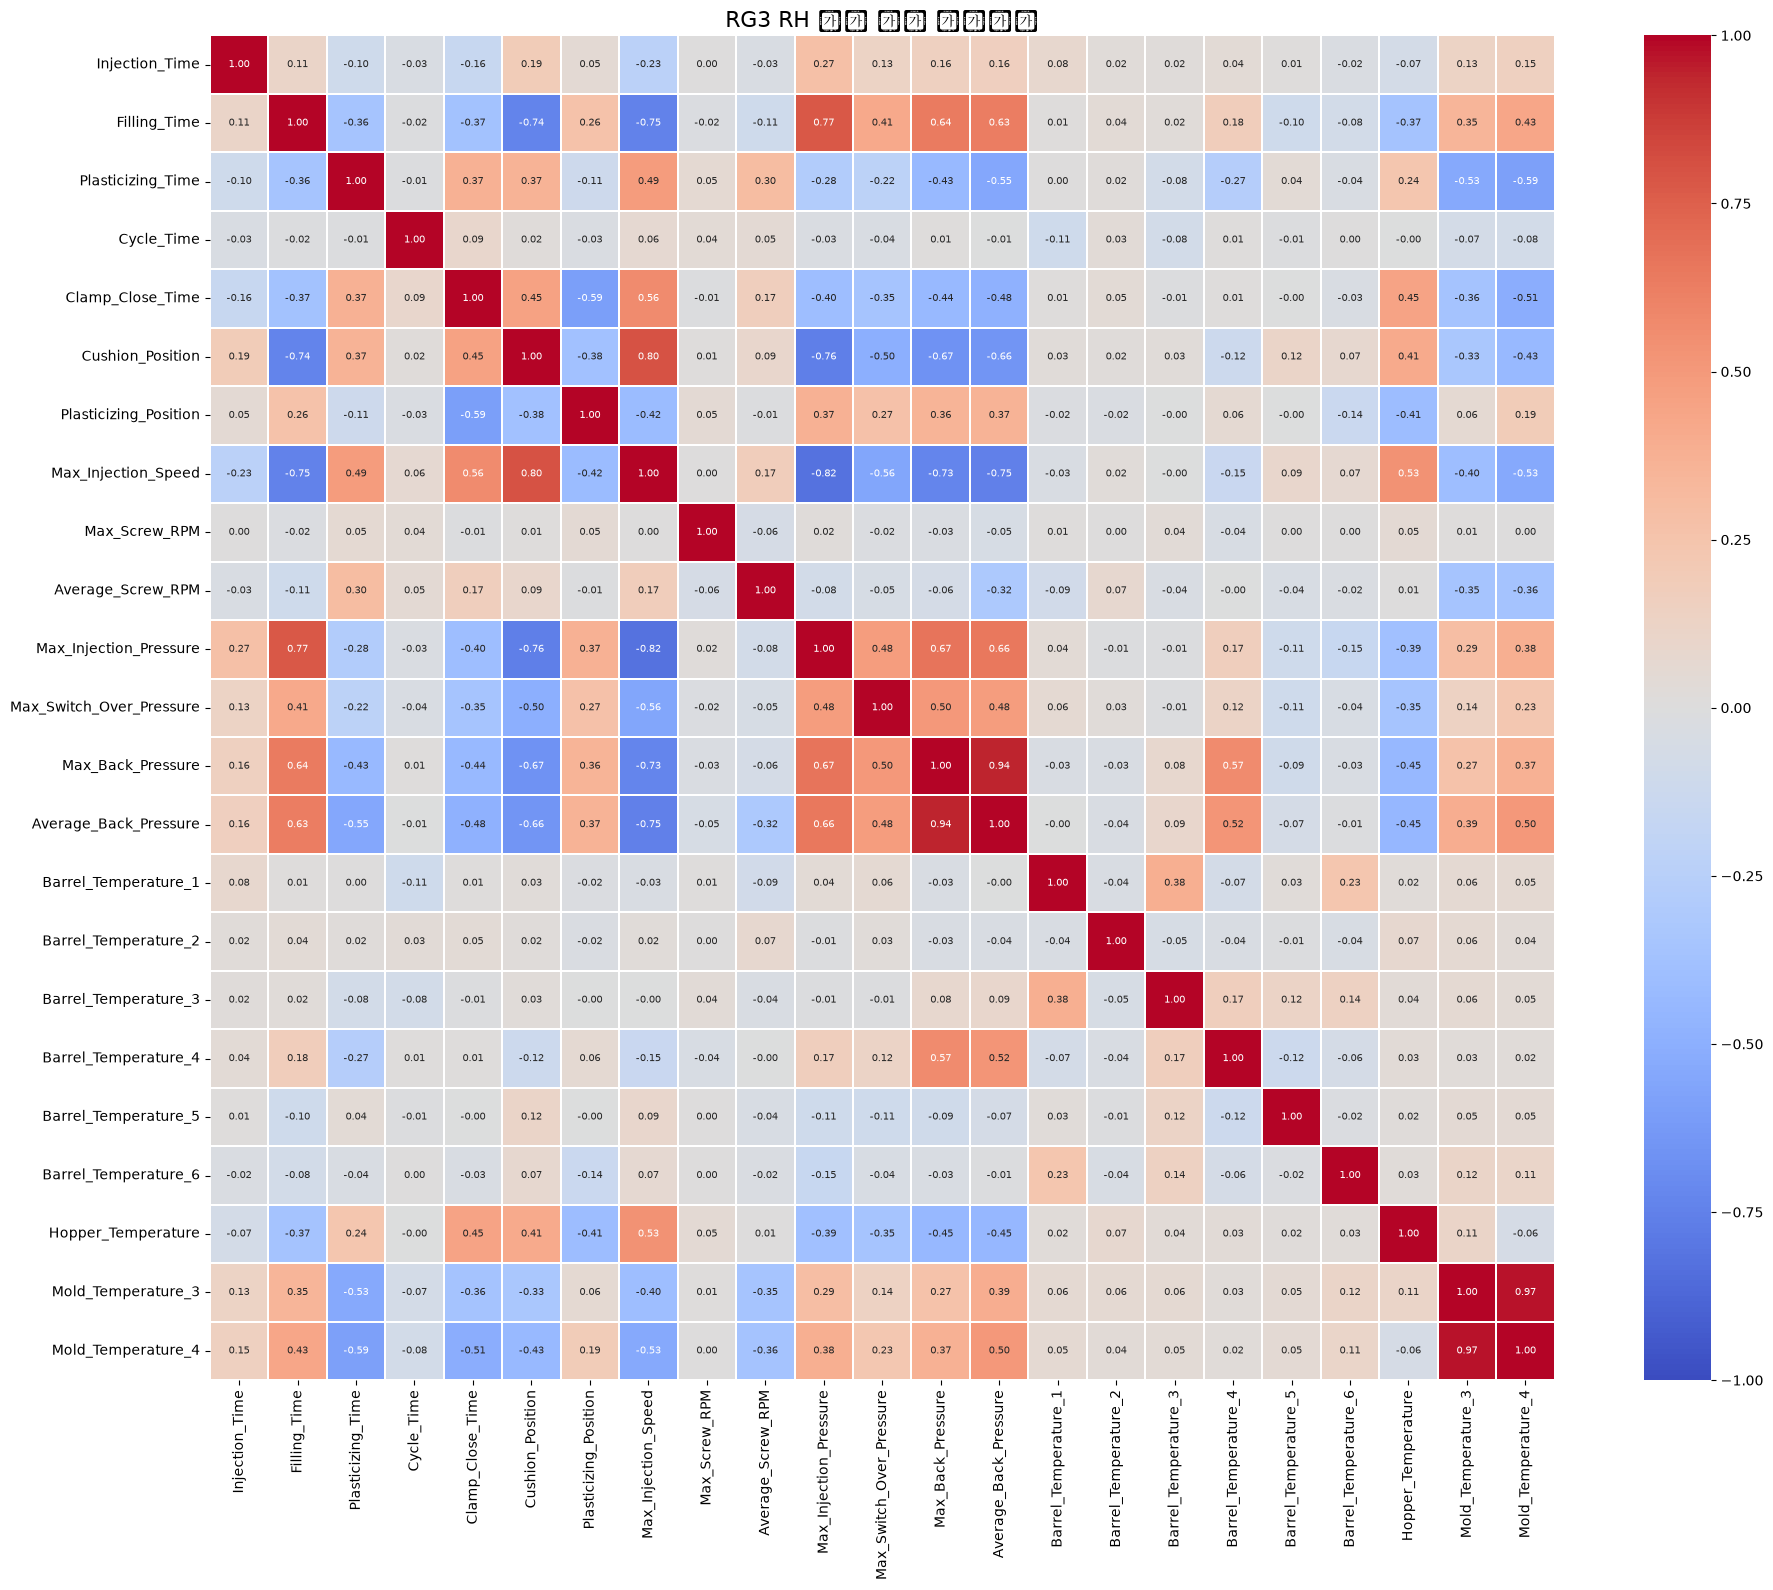

In [38]:
import seaborn as sns

# 공정 변수 상관계수
corr = rg3_rh[PROCESS_COLS].corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    annot_kws={"size": 7}
)

plt.title(
    "RG3 RH 공정 변수 상관관계",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 변수 간 상관관계 확인 결과

공정 변수 간 상관관계를 확인한 결과,
절대 상관계수 0.9 이상인 변수 조합은 총 2개였다.

- `Mold_Temperature_3` ↔ `Mold_Temperature_4` : 0.974
- `Max_Back_Pressure` ↔ `Average_Back_Pressure` : 0.941

두 변수쌍 모두 매우 강한 양의 상관관계를 보이고 있어
서로 유사한 공정 정보를 포함하고 있을 가능성이 있다.

특히 선형 모델에서는 강한 상관관계를 가진 변수들이 동시에 포함될 경우
다중공선성이 발생하여 변수 해석이 불안정해질 수 있다.

다만 Random Forest와 같은 트리 기반 모델에서는
상관관계가 높은 변수를 반드시 제거할 필요는 없다.

따라서 이 단계에서는 바로 제거하지 않고,
각 변수가 불량과 얼마나 관련되어 있는지 추가로 비교한 후
최종 모델링 변수에서 제거 여부를 결정한다.

In [39]:
# 높은 상관관계를 가진 변수들
high_corr_cols = [
    "Mold_Temperature_3",
    "Mold_Temperature_4",
    "Max_Back_Pressure",
    "Average_Back_Pressure"
]

# Target과의 관계 비교
high_corr_target = pd.DataFrame({
    "Normal_Mean": rg3_rh[
        rg3_rh["PassOrFail"] == 0
    ][high_corr_cols].mean(),

    "Defect_Mean": rg3_rh[
        rg3_rh["PassOrFail"] == 1
    ][high_corr_cols].mean(),

    "Target_Corr": rg3_rh[
        high_corr_cols
    ].corrwith(
        rg3_rh["PassOrFail"]
    )
})

high_corr_target["Mean_Diff"] = (
    high_corr_target["Defect_Mean"]
    - high_corr_target["Normal_Mean"]
)

high_corr_target["Abs_Mean_Diff"] = (
    high_corr_target["Mean_Diff"].abs()
)

high_corr_target["Abs_Target_Corr"] = (
    high_corr_target["Target_Corr"].abs()
)

high_corr_target.sort_values(
    "Abs_Target_Corr",
    ascending=False
)

,Normal_Mean,Defect_Mean,Target_Corr,Mean_Diff,Abs_Mean_Diff,Abs_Target_Corr
Mold_Temperature_3,0.003902,-0.088344,-0.018567,-0.092246,0.092246,0.018567
Mold_Temperature_4,0.003555,-0.080492,-0.016917,-0.084048,0.084048,0.016917
Max_Back_Pressure,-0.003356,0.075972,0.015967,0.079328,0.079328,0.015967
Average_Back_Pressure,-0.002660,0.060221,0.012656,0.062881,0.062881,0.012656


### 높은 상관관계 변수와 Target 관계 확인 결과

높은 상관관계를 가진 변수들의 Target과의 관계를 추가로 확인하였다.

| 변수 | Target 절대 상관계수 |
| --- | ---: |
| Mold_Temperature_3 | 0.0186 |
| Mold_Temperature_4 | 0.0169 |
| Max_Back_Pressure | 0.0160 |
| Average_Back_Pressure | 0.0127 |

네 변수 모두 Target과의 단순 선형 상관관계는 매우 낮게 나타났다.

그러나 Target과의 Pearson 상관계수가 낮다고 해서
해당 변수가 불량 탐지에 필요하지 않다고 판단할 수는 없다.

불량은 단일 변수의 절대값보다는

- 여러 공정 변수의 조합
- 이전 생산 대비 변화량
- 일정 구간의 평균 및 변동성
- 센서 간 상대적인 차이

등에서 나타날 가능성이 있기 때문이다.

또한 `Mold_Temperature_3`, `Mold_Temperature_4`와 같이
원본 값에서는 높은 상관관계를 가지더라도
시간 변화 패턴에서는 서로 다른 정보를 제공할 가능성이 있다.

따라서 현재 단계에서는 상관관계가 높은 변수도 제거하지 않고 유지한다.

향후 Baseline 모델 및 파생변수 실험 후
중복 변수 제거 전/후 성능을 비교하여 최종 사용 여부를 결정한다.

In [40]:
# 현재까지 제거한 변수
DROP_COLS = [
    "Clamp_Open_Position"
]

## 2-13. 시간 순서에 따른 불량 발생 구조 확인

사출 공정은 연속적인 생산 과정이므로
각 행을 서로 독립적인 데이터로만 보는 것보다
시간 흐름에 따른 공정 변화를 확인할 필요가 있다.

특히 불량이 특정 시간대에 집중되거나 연속적으로 발생한다면,
현재 공정값뿐만 아니라 이전 생산 데이터의 변화가
불량 발생과 관련되어 있을 가능성이 있다.

따라서 다음을 확인한다.

- 날짜별 생산량 및 불량 개수
- 불량 발생 시점
- 불량이 연속적으로 발생하는지 여부
- 불량 전후 공정값 변화

이 결과를 바탕으로 이후
Lag, Diff, Rolling Mean, Rolling Std 등의
시간 기반 파생변수 생성 여부를 결정한다.

In [41]:
# 시간 순서 정렬
rg3_rh = (
    rg3_rh
    .sort_values("TimeStamp")
    .reset_index(drop=True)
)

rg3_rh[
    ["TimeStamp", "PassOrFail"]
].head()


,TimeStamp,PassOrFail
0,2020-10-21 00:16:26,0
1,2020-10-21 00:17:26,0
2,2020-10-21 00:18:29,0
3,2020-10-21 00:19:31,0
4,2020-10-21 00:20:34,0


In [42]:
# 날짜별 정상 / 불량 개수
daily_target = pd.crosstab(
    rg3_rh["TimeStamp"].dt.date,
    rg3_rh["PassOrFail"]
)

daily_target

PassOrFail,0,1
TimeStamp,,
2020-10-21,41,0
2020-10-22,285,15
2020-10-23,240,10


### 날짜별 불량 발생 확인 결과

날짜별 정상 / 불량 분포를 확인한 결과,
불량 발생 시점에 뚜렷한 시간적 차이가 확인되었다.

- 2020-10-21 : 정상 41건 / 불량 0건
- 2020-10-22 : 정상 285건 / 불량 15건
- 2020-10-23 : 정상 240건 / 불량 10건

전체 불량 25건은 모두 10월 22일 이후에 발생하였다.

이는 불량이 전체 생산 기간에 무작위로 분포하기보다
특정 시점 이후의 공정 상태 변화와 관련되어 있을 가능성을 보여준다.

따라서 이후 분석에서는 단순한 현재 시점의 공정값뿐만 아니라,

- 직전 생산 대비 변화량
- 최근 생산 구간의 평균
- 최근 생산 구간의 변동성
- 불량 발생 전후의 공정 패턴

등 시간 기반 특성을 함께 확인할 필요가 있다.

또한 최종 모델 평가 시 미래 데이터에 대한 성능을 확인하기 위해
10월 23일 데이터를 Holdout 데이터로 사용하는 방안을 검토한다.

In [43]:
# 불량 발생 시점 확인
defect_time = rg3_rh.loc[
    rg3_rh["PassOrFail"] == 1,
    ["TimeStamp", "original_index", "PassOrFail"]
]

defect_time

,TimeStamp,original_index,PassOrFail
68,2020-10-22 00:51:52,1347,1
80,2020-10-22 01:04:15,1371,1
85,2020-10-22 01:09:23,1381,1
102,2020-10-22 01:26:54,1415,1
122,2020-10-22 01:57:47,1455,1
150,2020-10-22 04:46:36,1511,1
152,2020-10-22 04:48:39,1515,1
155,2020-10-22 04:51:46,1521,1
161,2020-10-22 04:57:56,1533,1
173,2020-10-22 05:10:17,1557,1


In [44]:
# 불량 간 시간 차이
defect_time["Time_Diff"] = (
    defect_time["TimeStamp"]
    .diff()
)

defect_time

,TimeStamp,original_index,PassOrFail,Time_Diff
68,2020-10-22 00:51:52,1347,1,NaT
80,2020-10-22 01:04:15,1371,1,0 days 00:12:23
85,2020-10-22 01:09:23,1381,1,0 days 00:05:08
102,2020-10-22 01:26:54,1415,1,0 days 00:17:31
122,2020-10-22 01:57:47,1455,1,0 days 00:30:53
150,2020-10-22 04:46:36,1511,1,0 days 02:48:49
152,2020-10-22 04:48:39,1515,1,0 days 00:02:03
155,2020-10-22 04:51:46,1521,1,0 days 00:03:07
161,2020-10-22 04:57:56,1533,1,0 days 00:06:10
173,2020-10-22 05:10:17,1557,1,0 days 00:12:21


### 불량 발생 시간 패턴 확인 결과

불량 발생 시점을 시간순으로 확인한 결과,
불량은 전체 기간에 완전히 무작위로 발생하기보다
특정 시간 구간에서 반복적으로 발생하는 패턴을 보였다.

주요 불량 발생 구간은 다음과 같다.

- 10월 22일 00:51 ~ 01:57
- 10월 22일 04:46 ~ 07:37
- 10월 23일 01:03 ~ 02:25
- 10월 23일 05:15 ~ 05:59
- 10월 23일 07:15 ~ 07:21

일부 불량은 약 2~7분 간격으로 연속해서 발생했으며,
특정 시간 구간에서 여러 불량이 반복적으로 발생하였다.

이는 하나의 제품에서 측정된 공정값뿐만 아니라
최근 생산 과정에서 공정 상태가 변화하거나 불안정해지는 패턴이
불량 발생과 관련되어 있을 가능성을 보여준다.

따라서 이후 다음과 같은 시간 기반 파생변수를 검토한다.

- 직전 생산 대비 변화량(Diff)
- 이전 생산값(Lag)
- 최근 생산 구간 평균(Rolling Mean)
- 최근 생산 구간 변동성(Rolling Std)

다만 생산 데이터 사이에 긴 시간 공백이 존재하므로,
행 개수만 기준으로 Rolling 변수를 생성하기 전에
전체 생산 간격을 확인하여 생산 중단 구간을 구분할 필요가 있다.

## 2-14. 연속 생산 간 시간 간격 확인

Rolling 및 Lag 기반 파생변수를 생성하기 전에
RH 제품이 실제로 어느 정도 간격으로 생산되었는지 확인한다.

생산 사이에 긴 중단 시간이 존재할 경우,
중단 이전의 생산 데이터를 이후 생산의 최근 공정 상태로 사용하는 것은
적절하지 않을 수 있다.

따라서 모든 RH 데이터에 대해 직전 생산과의 시간 차이를 계산하고,
생산 간격의 분포와 긴 공백 구간을 확인한다.

In [45]:
# 직전 RH 생산과의 시간 차이
rg3_rh["Time_Diff"] = (
    rg3_rh["TimeStamp"]
    .diff()
)

rg3_rh[
    ["TimeStamp", "PassOrFail", "Time_Diff"]
].head(20)

,TimeStamp,PassOrFail,Time_Diff
0,2020-10-21 00:16:26,0,NaT
1,2020-10-21 00:17:26,0,0 days 00:01:00
2,2020-10-21 00:18:29,0,0 days 00:01:03
3,2020-10-21 00:19:31,0,0 days 00:01:02
4,2020-10-21 00:20:34,0,0 days 00:01:03
5,2020-10-21 00:21:34,0,0 days 00:01:00
6,2020-10-21 00:22:36,0,0 days 00:01:02
7,2020-10-21 00:23:39,0,0 days 00:01:03
8,2020-10-21 00:24:39,0,0 days 00:01:00
9,2020-10-21 00:25:41,0,0 days 00:01:02


In [46]:
# 생산 간격 통계
rg3_rh["Time_Diff"].describe()

count                       590
mean     0 days 00:05:38.605084
std      0 days 01:11:36.433056
min             0 days 00:01:00
25%             0 days 00:01:01
50%             0 days 00:01:02
75%             0 days 00:01:03
max             0 days 23:26:28
Name: Time_Diff, dtype: object

In [47]:
# 30분 이상 생산 공백 확인
rg3_rh.loc[
    rg3_rh["Time_Diff"] >= pd.Timedelta(minutes=30),
    ["TimeStamp", "PassOrFail", "Time_Diff"]
]

,TimeStamp,PassOrFail,Time_Diff
41,2020-10-22 00:24:05,0,0 days 23:26:28
144,2020-10-22 04:40:26,0,0 days 02:20:00
341,2020-10-23 01:01:28,0,0 days 16:52:04
415,2020-10-23 04:41:48,0,0 days 02:05:37


### 시간 정보 사용 원칙

`TimeStamp`는 모델이 불량 여부를 직접 판단하는 Feature로 사용하지 않는다.

시간 정보는 다음 목적으로만 사용한다.

- 생산 순서 정렬
- 과거 / 미래 데이터 분리
- 생산 중단 구간 확인
- Lag / Diff / Rolling 파생변수 생성
- 생산 세션 구분

이를 통해 모델이 특정 날짜를 학습하는 것을 방지하고,
실제 미래 생산 데이터에서도 공정 상태를 기반으로
불량을 탐지할 수 있도록 한다.

모델 평가는 과거 데이터로 학습하고
이후 시점의 데이터를 평가하는 시간 순서 기반 방식으로 진행한다.

## 2-15. 생산 세션 구분

RH 데이터의 생산 간격을 확인한 결과,
대부분의 제품은 약 1분 간격으로 연속 생산되었지만
중간에 수십 분에서 수시간 이상의 생산 중단 구간이 존재하였다.

이러한 생산 중단을 무시하고 Lag 또는 Rolling 변수를 생성할 경우,
몇 시간 전 또는 이전 날짜의 공정값이
현재 생산의 최근 공정 상태로 포함될 수 있다.

따라서 직전 생산과의 시간 차이가 30분 이상인 경우
새로운 생산 세션이 시작된 것으로 정의한다.

이후 Lag, Diff, Rolling 기반 파생변수는
같은 생산 세션 내부에서만 계산한다.

In [48]:
# 30분 이상 생산 공백 확인
long_gap = rg3_rh.loc[
    rg3_rh["Time_Diff"] >= pd.Timedelta(minutes=30),
    ["TimeStamp", "Time_Diff"]
]

long_gap

,TimeStamp,Time_Diff
41,2020-10-22 00:24:05,0 days 23:26:28
144,2020-10-22 04:40:26,0 days 02:20:00
341,2020-10-23 01:01:28,0 days 16:52:04
415,2020-10-23 04:41:48,0 days 02:05:37


In [49]:
# 30분 이상 공백이면 새로운 생산 세션
rg3_rh["New_Session"] = (
    rg3_rh["Time_Diff"].isna()
    | (rg3_rh["Time_Diff"] >= pd.Timedelta(minutes=30))
)

rg3_rh["Session"] = (
    rg3_rh["New_Session"]
    .cumsum()
)

rg3_rh[
    ["TimeStamp", "Time_Diff", "Session"]
].head()

,TimeStamp,Time_Diff,Session
0,2020-10-21 00:16:26,NaT,1
1,2020-10-21 00:17:26,0 days 00:01:00,1
2,2020-10-21 00:18:29,0 days 00:01:03,1
3,2020-10-21 00:19:31,0 days 00:01:02,1
4,2020-10-21 00:20:34,0 days 00:01:03,1


In [50]:
# 생산 세션별 데이터 구조 확인
session_check = (
    rg3_rh
    .groupby("Session")
    .agg(
        Start=("TimeStamp", "min"),
        End=("TimeStamp", "max"),
        Count=("PassOrFail", "size"),
        Defect_Count=("PassOrFail", "sum")
    )
)

session_check

,Start,End,Count,Defect_Count
Session,,,,
1,2020-10-21 00:16:26,2020-10-21 00:57:37,41,0
2,2020-10-22 00:24:05,2020-10-22 02:20:26,103,5
3,2020-10-22 04:40:26,2020-10-22 08:09:24,197,10
4,2020-10-23 01:01:28,2020-10-23 02:36:11,74,4
5,2020-10-23 04:41:48,2020-10-23 07:46:03,176,6


### 생산 세션 구분 결과

직전 생산과의 시간 차이가 30분 이상인 경우를
새로운 생산 세션으로 정의한 결과 총 5개의 생산 세션으로 구분되었다.

- Session 1 : 41건 / 불량 0건
- Session 2 : 103건 / 불량 5건
- Session 3 : 197건 / 불량 10건
- Session 4 : 74건 / 불량 4건
- Session 5 : 176건 / 불량 6건

생산 세션 사이에는 약 2시간에서 최대 23시간 이상의 공백이 존재하였다.

따라서 Lag, Diff, Rolling 등의 시간 기반 파생변수는
전체 데이터를 단순히 연결하여 계산하지 않고
각 생산 세션 내부에서만 계산한다.

이를 통해 생산 중단 이전의 오래된 공정값이
새로운 생산 세션의 최근 공정 상태로 잘못 사용되는 것을 방지한다.

# 3. 시간 기반 파생변수 생성

원본 공정 변수만으로는 정상과 불량의 평균 차이가 전반적으로 크지 않았다.

또한 불량이 특정 생산 세션과 시간 구간에서 반복적으로 발생하는 패턴이 확인되었다.

따라서 현재 시점의 절대적인 공정값뿐만 아니라
직전 생산 및 최근 생산 구간과 비교한 공정 변화 정보를 파생변수로 생성한다.

파생변수는 미래 정보를 사용하지 않도록 반드시 과거 데이터만 이용하며,
생산 중단 이전 데이터가 섞이지 않도록 동일한 `Session` 내부에서만 계산한다.

파생변수는 다음 순서로 추가하고 각각의 성능 변화를 비교한다.

1. Original Features
2. Diff Features
3. Lag Features
4. Rolling Mean
5. Rolling Standard Deviation
6. 공정 변수 간 Interaction

이를 통해 어떤 종류의 공정 정보가 불량 탐지에 실제로 기여하는지 확인한다.

## 3-1. 직전 생산 대비 변화량(Diff)

현재 제품의 공정값과 직전 생산 제품의 공정값 차이를 계산한다.

Diff 변수는 공정값 자체보다
최근 공정 상태가 얼마나 급격하게 변화했는지를 표현한다.

각 생산 세션의 첫 번째 제품은 비교할 직전 생산 데이터가 존재하지 않으므로
Diff 값을 계산할 수 없다.

Diff는 동일한 생산 세션 내부에서만 계산하여
생산 중단 이전 데이터와 비교되는 것을 방지한다.

In [51]:
# Diff 파생변수 생성
for col in PROCESS_COLS:
    rg3_rh[f"{col}_diff1"] = (
        rg3_rh
        .groupby("Session")[col]
        .diff(1)
    )

In [52]:
# 생성된 Diff 변수
DIFF_COLS = [
    f"{col}_diff1"
    for col in PROCESS_COLS
]

len(DIFF_COLS)

23

In [53]:
# 각 세션 첫 행의 Diff 확인
rg3_rh.loc[
    rg3_rh["New_Session"],
    ["Session"] + DIFF_COLS[:5]
]

,Session,Injection_Time_diff1,Filling_Time_diff1,Plasticizing_Time_diff1,Cycle_Time_diff1,Clamp_Close_Time_diff1
0,1,NaN,NaN,NaN,NaN,NaN
41,2,NaN,NaN,NaN,NaN,NaN
144,3,NaN,NaN,NaN,NaN,NaN
341,4,NaN,NaN,NaN,NaN,NaN
415,5,NaN,NaN,NaN,NaN,NaN


## 3-2. Diff 변수의 정상 / 불량 차이 확인

생성한 Diff 변수에 대해 정상 제품과 불량 제품의 평균 차이를 확인한다.

원본 공정 변수에서는 대부분 정상과 불량의 평균 차이가 크지 않았기 때문에,
직전 생산 대비 변화량이 불량 발생과 더 관련되어 있는지 확인한다.

특히 `Abs_Mean_Diff`가 큰 변수일수록
정상과 불량에서 직전 생산 대비 변화 패턴이 다를 가능성이 있다.

단, 이 단계에서도 평균 차이만으로 변수를 제거하지 않고
향후 모델 성능과 함께 판단한다.

In [54]:
# Diff 변수 정상 / 불량 평균 비교
diff_target_mean = (
    rg3_rh
    .groupby("PassOrFail")[DIFF_COLS]
    .mean()
    .T
)

diff_target_mean.columns = [
    "Normal_Mean",
    "Defect_Mean"
]

diff_target_mean["Mean_Diff"] = (
    diff_target_mean["Defect_Mean"]
    - diff_target_mean["Normal_Mean"]
)

diff_target_mean["Abs_Mean_Diff"] = (
    diff_target_mean["Mean_Diff"].abs()
)

diff_target_mean = (
    diff_target_mean
    .sort_values(
        "Abs_Mean_Diff",
        ascending=False
    )
)

diff_target_mean

,Normal_Mean,Defect_Mean,Mean_Diff,Abs_Mean_Diff
Max_Screw_RPM_diff1,-0.004787,0.322285,0.327072,0.327072
Max_Back_Pressure_diff1,-0.008873,0.236445,0.245318,0.245318
Average_Back_Pressure_diff1,-0.008289,0.204599,0.212887,0.212887
Plasticizing_Time_diff1,-0.012804,0.188559,0.201363,0.201363
Average_Screw_RPM_diff1,-0.008229,0.184654,0.192882,0.192882
Barrel_Temperature_5_diff1,-0.017322,0.163009,0.180331,0.180331
Barrel_Temperature_3_diff1,-0.008217,0.172088,0.180305,0.180305
Barrel_Temperature_2_diff1,-0.007776,0.164797,0.172573,0.172573
Barrel_Temperature_6_diff1,-0.007090,0.159091,0.166181,0.166181
Cycle_Time_diff1,-0.008795,0.153493,0.162287,0.162287


In [55]:
# 정상 / 불량 차이가 큰 Diff 변수 TOP 10
diff_target_mean.head(10)

,Normal_Mean,Defect_Mean,Mean_Diff,Abs_Mean_Diff
Max_Screw_RPM_diff1,-0.004787,0.322285,0.327072,0.327072
Max_Back_Pressure_diff1,-0.008873,0.236445,0.245318,0.245318
Average_Back_Pressure_diff1,-0.008289,0.204599,0.212887,0.212887
Plasticizing_Time_diff1,-0.012804,0.188559,0.201363,0.201363
Average_Screw_RPM_diff1,-0.008229,0.184654,0.192882,0.192882
Barrel_Temperature_5_diff1,-0.017322,0.163009,0.180331,0.180331
Barrel_Temperature_3_diff1,-0.008217,0.172088,0.180305,0.180305
Barrel_Temperature_2_diff1,-0.007776,0.164797,0.172573,0.172573
Barrel_Temperature_6_diff1,-0.007090,0.159091,0.166181,0.166181
Cycle_Time_diff1,-0.008795,0.153493,0.162287,0.162287


### Original 변수와 Diff 변수 비교

원본 공정값과 직전 생산 대비 변화량 중
어느 쪽에서 정상 / 불량 차이가 더 크게 나타나는지 비교한다.

이를 통해 불량이 절대적인 공정값보다
최근 공정 변화와 더 관련되어 있는지 확인한다.

In [56]:
# Original TOP 10
original_top10 = (
    target_mean[
        ["Abs_Mean_Diff"]
    ]
    .head(10)
    .copy()
)

original_top10

,Abs_Mean_Diff
Barrel_Temperature_5,0.465400
Clamp_Close_Time,0.189153
Plasticizing_Time,0.180595
Max_Screw_RPM,0.146148
Barrel_Temperature_3,0.143362
Hopper_Temperature,0.139930
Average_Screw_RPM,0.138001
Barrel_Temperature_1,0.123020
Max_Switch_Over_Pressure,0.105394
Plasticizing_Position,0.103652


In [57]:
# Diff TOP 10
diff_top10 = (
    diff_target_mean[
        ["Abs_Mean_Diff"]
    ]
    .head(10)
    .copy()
)

diff_top10

,Abs_Mean_Diff
Max_Screw_RPM_diff1,0.327072
Max_Back_Pressure_diff1,0.245318
Average_Back_Pressure_diff1,0.212887
Plasticizing_Time_diff1,0.201363
Average_Screw_RPM_diff1,0.192882
Barrel_Temperature_5_diff1,0.180331
Barrel_Temperature_3_diff1,0.180305
Barrel_Temperature_2_diff1,0.172573
Barrel_Temperature_6_diff1,0.166181
Cycle_Time_diff1,0.162287


### Diff 변수 확인 결과

직전 생산 대비 변화량(Diff)의 정상 / 불량 평균 차이를 확인한 결과,
가장 큰 차이를 보인 변수는 다음과 같다.

- `Max_Screw_RPM_diff1` : 0.327
- `Max_Back_Pressure_diff1` : 0.245
- `Average_Back_Pressure_diff1` : 0.213
- `Plasticizing_Time_diff1` : 0.201
- `Average_Screw_RPM_diff1` : 0.193

원본 변수에서 가장 큰 평균 차이를 보였던
`Barrel_Temperature_5`의 0.465보다
Diff 변수의 최대 차이는 작게 나타났다.

따라서 현재 결과만 보면
불량은 직전 생산 대비 급격한 변화만으로 발생하기보다는
현재 공정 상태 자체와 최근 변화 패턴이 함께 영향을 줄 가능성이 있다.

다만 압력 및 Screw RPM 관련 Diff 변수가 상위에 나타났으므로,
Diff 변수는 제거하지 않고 이후 모델링 후보로 유지한다.

## 3-3. 직전 생산 공정값(Lag 1) 생성

현재 제품의 불량이 발생하기 전에
직전 생산 제품에서 공정 상태 변화가 이미 나타났는지 확인하기 위해
Lag 변수를 생성한다.

`Lag 1`은 동일한 생산 세션에서
현재 제품보다 한 단계 이전에 생산된 제품의 공정값을 의미한다.

예를 들어,

- 현재 제품의 `Max_Screw_RPM`
- 직전 제품의 `Max_Screw_RPM_lag1`

을 함께 사용하면 현재 상태뿐만 아니라
불량 발생 직전의 공정 상태도 모델에 제공할 수 있다.

Lag 변수 역시 생산 세션 내부에서만 생성하며,
각 세션의 첫 번째 제품은 이전 생산 데이터가 없기 때문에 결측값이 발생한다.

In [58]:
# Lag 1 파생변수 생성
for col in PROCESS_COLS:
    rg3_rh[f"{col}_lag1"] = (
        rg3_rh
        .groupby("Session")[col]
        .shift(1)
    )

In [59]:
# 생성된 Lag 변수
LAG_COLS = [
    f"{col}_lag1"
    for col in PROCESS_COLS
]

len(LAG_COLS)

23

In [60]:
# 각 생산 세션 첫 행은 이전 데이터가 없으므로 NaN
rg3_rh.loc[
    rg3_rh["New_Session"],
    ["Session"] + LAG_COLS[:5]
]

,Session,Injection_Time_lag1,Filling_Time_lag1,Plasticizing_Time_lag1,Cycle_Time_lag1,Clamp_Close_Time_lag1
0,1,NaN,NaN,NaN,NaN,NaN
41,2,NaN,NaN,NaN,NaN,NaN
144,3,NaN,NaN,NaN,NaN,NaN
341,4,NaN,NaN,NaN,NaN,NaN
415,5,NaN,NaN,NaN,NaN,NaN


### Lag 변수의 정상 / 불량 차이 확인

직전 제품의 공정값이
현재 제품의 정상 / 불량에 따라 차이를 보이는지 확인한다.

Lag 변수의 차이가 크게 나타난다면
불량 제품이 생산되기 전에 이미 공정 상태 변화가 발생하고 있을 가능성이 있다.

In [61]:
# Lag 변수 정상 / 불량 평균 비교
lag_target_mean = (
    rg3_rh
    .groupby("PassOrFail")[LAG_COLS]
    .mean()
    .T
)

lag_target_mean.columns = [
    "Normal_Mean",
    "Defect_Mean"
]

lag_target_mean["Mean_Diff"] = (
    lag_target_mean["Defect_Mean"]
    - lag_target_mean["Normal_Mean"]
)

lag_target_mean["Abs_Mean_Diff"] = (
    lag_target_mean["Mean_Diff"].abs()
)

lag_target_mean = (
    lag_target_mean
    .sort_values(
        "Abs_Mean_Diff",
        ascending=False
    )
)

lag_target_mean.head(10)

,Normal_Mean,Defect_Mean,Mean_Diff,Abs_Mean_Diff
Barrel_Temperature_3_lag1,0.017093,-0.309386,-0.326479,0.326479
Barrel_Temperature_5_lag1,-0.010648,0.282705,0.293352,0.293352
Plasticizing_Position_lag1,0.011716,-0.224299,-0.236014,0.236014
Barrel_Temperature_2_lag1,0.011846,-0.215053,-0.226899,0.226899
Barrel_Temperature_1_lag1,0.008129,-0.201735,-0.209864,0.209864
Max_Screw_RPM_lag1,0.004484,-0.182319,-0.186803,0.186803
Max_Injection_Speed_lag1,0.006151,-0.167353,-0.173503,0.173503
Barrel_Temperature_4_lag1,0.005267,-0.162836,-0.168103,0.168103
Max_Back_Pressure_lag1,0.005698,-0.160472,-0.166170,0.166170
Cycle_Time_lag1,0.008155,-0.145181,-0.153336,0.153336


### Lag 1 변수 확인 결과

직전 생산 제품의 공정값(Lag 1)과 현재 제품의 정상 / 불량 관계를 확인하였다.

가장 큰 평균 차이를 보인 변수는 다음과 같다.

- `Barrel_Temperature_3_lag1` : 0.326
- `Barrel_Temperature_5_lag1` : 0.293
- `Plasticizing_Position_lag1` : 0.236
- `Barrel_Temperature_2_lag1` : 0.227
- `Barrel_Temperature_1_lag1` : 0.210

원본 변수의 최대 평균 차이인 0.465보다는 작았지만,
직전 생산의 온도 및 위치 관련 변수에서 정상 / 불량 차이가 확인되었다.

이는 불량이 발생한 현재 시점뿐만 아니라
불량 발생 직전의 공정 상태에도 일정한 패턴이 존재할 가능성을 보여준다.

따라서 Lag 변수는 제거하지 않고 모델링 후보로 유지한다.

## 3-4. 최근 공정 평균(Rolling Mean) 생성

현재 제품 한 개의 공정값보다
최근 여러 제품에서 지속적으로 나타나는 공정 상태가
불량 발생과 더 관련되어 있을 수 있다.

따라서 동일한 생산 세션 내부에서
최근 3개 및 5개 제품의 평균 공정값을 생성한다.

- Rolling 3 : 최근 3개 생산의 평균
- Rolling 5 : 최근 5개 생산의 평균

현재 공정값도 평균 계산에 포함하며,
생산 세션이 변경되면 이전 세션의 데이터는 사용하지 않는다.

이를 통해 순간적인 센서값이 아니라
최근 공정 상태의 전반적인 수준을 표현한다.

In [62]:
# Rolling Mean 3
for col in PROCESS_COLS:
    rg3_rh[f"{col}_roll3_mean"] = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: x.rolling(
                window=3,
                min_periods=1
            ).mean()
        )
    )

In [63]:
# Rolling Mean 5
for col in PROCESS_COLS:
    rg3_rh[f"{col}_roll5_mean"] = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=1
            ).mean()
        )
    )

In [64]:
ROLL3_MEAN_COLS = [
    f"{col}_roll3_mean"
    for col in PROCESS_COLS
]

ROLL5_MEAN_COLS = [
    f"{col}_roll5_mean"
    for col in PROCESS_COLS
]

print("Roll3:", len(ROLL3_MEAN_COLS))
print("Roll5:", len(ROLL5_MEAN_COLS))

Roll3: 23
Roll5: 23


In [65]:
roll3_target_mean = (
    rg3_rh
    .groupby("PassOrFail")[ROLL3_MEAN_COLS]
    .mean()
    .T
)

roll3_target_mean.columns = [
    "Normal_Mean",
    "Defect_Mean"
]

roll3_target_mean["Mean_Diff"] = (
    roll3_target_mean["Defect_Mean"]
    - roll3_target_mean["Normal_Mean"]
)

roll3_target_mean["Abs_Mean_Diff"] = (
    roll3_target_mean["Mean_Diff"].abs()
)

roll3_target_mean = (
    roll3_target_mean
    .sort_values(
        "Abs_Mean_Diff",
        ascending=False
    )
)

roll3_target_mean.head(10)

,Normal_Mean,Defect_Mean,Mean_Diff,Abs_Mean_Diff
Barrel_Temperature_5_roll3_mean,-0.006026,0.278530,0.284556,0.284556
Injection_Time_roll3_mean,-0.008843,0.200200,0.209043,0.209043
Barrel_Temperature_3_roll3_mean,0.006969,-0.157784,-0.164753,0.164753
Barrel_Temperature_4_roll3_mean,0.006676,-0.147238,-0.153913,0.153913
Plasticizing_Position_roll3_mean,0.009217,-0.140945,-0.150161,0.150161
Clamp_Close_Time_roll3_mean,-0.004657,0.124356,0.129013,0.129013
Mold_Temperature_3_roll3_mean,-0.000965,-0.109242,-0.108277,0.108277
Hopper_Temperature_roll3_mean,-0.001476,-0.106896,-0.105420,0.105420
Mold_Temperature_4_roll3_mean,-0.001985,-0.090204,-0.088219,0.088219
Cushion_Position_roll3_mean,-0.001487,0.076319,0.077806,0.077806


In [66]:
roll5_target_mean = (
    rg3_rh
    .groupby("PassOrFail")[ROLL5_MEAN_COLS]
    .mean()
    .T
)

roll5_target_mean.columns = [
    "Normal_Mean",
    "Defect_Mean"
]

roll5_target_mean["Mean_Diff"] = (
    roll5_target_mean["Defect_Mean"]
    - roll5_target_mean["Normal_Mean"]
)

roll5_target_mean["Abs_Mean_Diff"] = (
    roll5_target_mean["Mean_Diff"].abs()
)

roll5_target_mean = (
    roll5_target_mean
    .sort_values(
        "Abs_Mean_Diff",
        ascending=False
    )
)

roll5_target_mean.head(10)

,Normal_Mean,Defect_Mean,Mean_Diff,Abs_Mean_Diff
Barrel_Temperature_3_roll5_mean,0.009711,-0.161061,-0.170773,0.170773
Barrel_Temperature_4_roll5_mean,0.007851,-0.146457,-0.154309,0.154309
Barrel_Temperature_1_roll5_mean,-0.002024,-0.138950,-0.136926,0.136926
Max_Back_Pressure_roll5_mean,0.005072,-0.124798,-0.129871,0.129871
Average_Back_Pressure_roll5_mean,0.004193,-0.108418,-0.112611,0.112611
Plasticizing_Position_roll5_mean,0.012553,-0.095110,-0.107663,0.107663
Barrel_Temperature_6_roll5_mean,0.007708,-0.096955,-0.104663,0.104663
Mold_Temperature_3_roll5_mean,-0.006629,-0.108862,-0.102233,0.102233
Plasticizing_Time_roll5_mean,0.005442,0.102321,0.096879,0.096879
Barrel_Temperature_5_roll5_mean,0.005955,0.097969,0.092013,0.092013


### Rolling Mean 확인 결과

최근 3개 및 5개 생산의 평균 공정값을 생성하여
정상 / 불량 평균 차이를 비교하였다.

Rolling 3에서 가장 큰 차이를 보인 변수는 다음과 같다.

- `Barrel_Temperature_5_roll3_mean` : 0.285
- `Injection_Time_roll3_mean` : 0.209
- `Barrel_Temperature_3_roll3_mean` : 0.165
- `Barrel_Temperature_4_roll3_mean` : 0.154
- `Plasticizing_Position_roll3_mean` : 0.150

반면 Rolling 5에서는 최대 평균 차이가 약 0.171로 감소하였다.

따라서 최근 5개 제품까지 평균을 확장할 경우
불량과 관련된 단기적인 공정 변화가 과도하게 평활화될 가능성이 있다.

현재 결과에서는 Rolling 5보다 Rolling 3이
불량 발생과 관련된 최근 공정 상태를 더 잘 표현하는 것으로 판단된다.

다만 Original 변수의 최대 평균 차이는 0.465로
Rolling Mean보다 여전히 크게 나타났다.

따라서 이후 모델에서는 Original 변수를 기본으로 유지하면서,
Rolling 3 변수를 추가 정보로 활용하는 방향을 검토한다.

## 3-5. 최근 공정 변동성(Rolling Std) 생성

최근 생산 구간에서 공정값이 얼마나 안정적으로 유지되었는지 확인하기 위해
Rolling Standard Deviation 변수를 생성한다.

Rolling Mean이 최근 공정값의 평균적인 수준을 표현한다면,
Rolling Std는 최근 공정값의 변동성과 불안정성을 표현한다.

불량 발생 직전에 공정값의 변동성이 증가한다면
Rolling Std가 중요한 불량 탐지 변수로 활용될 수 있다.

Rolling Mean 결과에서 최근 3개 생산 구간이
최근 5개 생산보다 더 뚜렷한 차이를 보였으므로,
Rolling Std 역시 3개와 5개 구간을 모두 생성하여 비교한다.

In [67]:
for col in PROCESS_COLS:
    rg3_rh[f"{col}_roll3_std"] = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: x.rolling(
                window=3,
                min_periods=2
            ).std()
        )
    )

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\2978820737.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[f"{col}_roll3_std"] = (


In [68]:
for col in PROCESS_COLS:
    rg3_rh[f"{col}_roll5_std"] = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=2
            ).std()
        )
    )

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\2250402147.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[f"{col}_roll5_std"] = (


In [69]:
ROLL3_STD_COLS = [
    f"{col}_roll3_std"
    for col in PROCESS_COLS
]

ROLL5_STD_COLS = [
    f"{col}_roll5_std"
    for col in PROCESS_COLS
]

print("Roll3 Std:", len(ROLL3_STD_COLS))
print("Roll5 Std:", len(ROLL5_STD_COLS))

Roll3 Std: 23
Roll5 Std: 23


In [70]:
roll3_std_target = (
    rg3_rh
    .groupby("PassOrFail")[ROLL3_STD_COLS]
    .mean()
    .T
)

roll3_std_target.columns = [
    "Normal_Mean",
    "Defect_Mean"
]

roll3_std_target["Mean_Diff"] = (
    roll3_std_target["Defect_Mean"]
    - roll3_std_target["Normal_Mean"]
)

roll3_std_target["Abs_Mean_Diff"] = (
    roll3_std_target["Mean_Diff"].abs()
)

roll3_std_target = (
    roll3_std_target
    .sort_values(
        "Abs_Mean_Diff",
        ascending=False
    )
)

roll3_std_target.head(10)

,Normal_Mean,Defect_Mean,Mean_Diff,Abs_Mean_Diff
Barrel_Temperature_3_roll3_std,0.907135,0.685403,-0.221732,0.221732
Injection_Time_roll3_std,0.176986,0.397158,0.220172,0.220172
Cycle_Time_roll3_std,0.426459,0.627369,0.200910,0.200910
Average_Screw_RPM_roll3_std,0.768322,0.904908,0.136586,0.136586
Cushion_Position_roll3_std,0.492300,0.608039,0.115739,0.115739
Plasticizing_Time_roll3_std,0.583270,0.670243,0.086972,0.086972
Barrel_Temperature_5_roll3_std,0.848554,0.931888,0.083333,0.083333
Barrel_Temperature_1_roll3_std,0.897552,0.969452,0.071900,0.071900
Barrel_Temperature_4_roll3_std,0.606589,0.540464,-0.066125,0.066125
Clamp_Close_Time_roll3_std,0.135097,0.196747,0.061650,0.061650


In [71]:
roll5_std_target = (
    rg3_rh
    .groupby("PassOrFail")[ROLL5_STD_COLS]
    .mean()
    .T
)

roll5_std_target.columns = [
    "Normal_Mean",
    "Defect_Mean"
]

roll5_std_target["Mean_Diff"] = (
    roll5_std_target["Defect_Mean"]
    - roll5_std_target["Normal_Mean"]
)

roll5_std_target["Abs_Mean_Diff"] = (
    roll5_std_target["Mean_Diff"].abs()
)

roll5_std_target = (
    roll5_std_target
    .sort_values(
        "Abs_Mean_Diff",
        ascending=False
    )
)

roll5_std_target.head(10)

,Normal_Mean,Defect_Mean,Mean_Diff,Abs_Mean_Diff
Injection_Time_roll5_std,0.232365,0.461455,0.229089,0.229089
Barrel_Temperature_5_roll5_std,0.907359,1.091086,0.183727,0.183727
Barrel_Temperature_3_roll5_std,0.967932,0.835970,-0.131962,0.131962
Average_Screw_RPM_roll5_std,0.841607,0.944592,0.102986,0.102986
Max_Switch_Over_Pressure_roll5_std,0.449108,0.347775,-0.101333,0.101333
Cushion_Position_roll5_std,0.622033,0.719145,0.097112,0.097112
Cycle_Time_roll5_std,0.508436,0.595389,0.086953,0.086953
Barrel_Temperature_1_roll5_std,0.944136,1.023357,0.079221,0.079221
Plasticizing_Position_roll5_std,0.580793,0.507832,-0.072960,0.072960
Barrel_Temperature_2_roll5_std,0.999299,0.926605,-0.072694,0.072694


### Rolling Std 확인 결과

최근 3개 및 5개 생산의 공정 변동성을 나타내는
Rolling Standard Deviation 변수를 생성하여 정상 / 불량 차이를 비교하였다.

Rolling 3 Std에서는 다음 변수의 차이가 상대적으로 크게 나타났다.

- `Barrel_Temperature_3_roll3_std` : 0.222
- `Injection_Time_roll3_std` : 0.220
- `Cycle_Time_roll3_std` : 0.201

Rolling 5 Std에서는 다음 변수의 차이가 상대적으로 크게 나타났다.

- `Injection_Time_roll5_std` : 0.229
- `Barrel_Temperature_5_roll5_std` : 0.184
- `Barrel_Temperature_3_roll5_std` : 0.132

그러나 Original 변수의 최대 평균 차이인 0.465보다
Rolling Std 변수의 평균 차이는 작게 나타났다.

현재까지 특정 파생변수 하나가 압도적으로 높은 분리력을 보이지는 않았지만,
Original, Diff, Lag, Rolling Mean, Rolling Std에서
서로 다른 공정 변수들이 상위에 나타나고 있다.

따라서 단순 평균 차이만으로 파생변수의 사용 여부를 결정하지 않고,
각 Feature Set을 실제 모델에 적용하여 성능 변화를 비교한다.

# 4. Feature Set 구성

생성한 파생변수가 실제 불량 탐지 성능을 개선하는지 확인하기 위해
Feature 종류를 단계적으로 추가하여 비교한다.

비교할 Feature Set은 다음과 같다.

1. Original
2. Original + Diff
3. Original + Lag
4. Original + Rolling Mean 3
5. Original + Rolling Std 3
6. Original + Diff + Lag + Rolling Mean 3 + Rolling Std 3

모든 파생변수를 무조건 사용하는 것이 아니라,
각 Feature Set의 미래 데이터 성능을 비교하여
실제 성능 개선에 기여하는 변수만 유지한다.

RG3 데이터는 불량 데이터가 매우 적으므로,
Feature 수가 지나치게 증가할 경우 과적합 위험이 있다는 점도 함께 고려한다.

In [72]:
FEATURE_SETS = {
    "Original": PROCESS_COLS,

    "Original + Diff": (
        PROCESS_COLS
        + DIFF_COLS
    ),

    "Original + Lag": (
        PROCESS_COLS
        + LAG_COLS
    ),

    "Original + Roll3 Mean": (
        PROCESS_COLS
        + ROLL3_MEAN_COLS
    ),

    "Original + Roll3 Std": (
        PROCESS_COLS
        + ROLL3_STD_COLS
    ),

    "All": (
        PROCESS_COLS
        + DIFF_COLS
        + LAG_COLS
        + ROLL3_MEAN_COLS
        + ROLL3_STD_COLS
    )
}

for name, cols in FEATURE_SETS.items():
    print(name, len(cols))

Original 23
Original + Diff 46
Original + Lag 46
Original + Roll3 Mean 46
Original + Roll3 Std 46
All 115


## 4-1. 개발 데이터와 최종 Holdout 분리

실제 미래 생산 데이터에 대한 성능을 평가하기 위해
시간 순서에 따라 데이터를 분리한다.

- Development : Session 1 ~ 3
  - 10월 21일 ~ 10월 22일
  - 모델 및 Feature Set 선택에 사용

- Final Holdout : Session 4 ~ 5
  - 10월 23일
  - 최종 선택된 모델을 단 한 번 평가하는 용도로 사용

Holdout 데이터는 모델 선택, Feature 선택,
Threshold 조정 과정에서 사용하지 않는다.

이를 통해 실제 미래 데이터에 대한 일반화 성능을 평가한다.

In [73]:
# 개발 / 최종 Holdout 분리
dev = rg3_rh[
    rg3_rh["Session"].isin([1, 2, 3])
].copy()

holdout = rg3_rh[
    rg3_rh["Session"].isin([4, 5])
].copy()

print("Development")
print(dev["PassOrFail"].value_counts())

print("\nHoldout")
print(holdout["PassOrFail"].value_counts())

Development
PassOrFail
0    326
1     15
Name: count, dtype: int64

Holdout
PassOrFail
0    240
1     10
Name: count, dtype: int64


# 5. Baseline 모델 구축

파생변수의 효과를 평가하기 전에
원본 공정 변수만 사용한 Baseline 모델을 구축한다.

Baseline 모델은 이후 생성한 Diff, Lag, Rolling 등의
파생변수가 실제 성능 향상에 기여했는지 비교하기 위한 기준으로 사용한다.

최종 Holdout 데이터는 사용하지 않고,
Development 데이터 내부에서도 시간 순서를 유지하여 학습과 검증 데이터를 분리한다.

- Train : Session 1 ~ 2
- Validation : Session 3
- Final Holdout : Session 4 ~ 5

이를 통해 과거 생산 데이터로 학습한 모델이
이후 생산 세션의 불량을 얼마나 탐지할 수 있는지 확인한다.

## 5-1. Development 내부 시간 분할

In [74]:
# Development 내부 Train / Validation 분리
train = dev[
    dev["Session"].isin([1, 2])
].copy()

valid = dev[
    dev["Session"] == 3
].copy()

print("[Train]")
print(train["PassOrFail"].value_counts())

print("\n[Validation]")
print(valid["PassOrFail"].value_counts())

[Train]
PassOrFail
0    139
1      5
Name: count, dtype: int64

[Validation]
PassOrFail
0    187
1     10
Name: count, dtype: int64


## 5-2. Original Feature Baseline

먼저 파생변수를 사용하지 않고
23개의 원본 공정 변수만 사용하여 Baseline 성능을 확인한다.

불량 데이터가 매우 적기 때문에
Accuracy보다는 다음 지표를 중심으로 평가한다.

- PR-AUC
- Recall
- Precision
- F1-score
- False Negative
- False Positive

특히 Threshold를 조정하여
Recall 100%를 달성할 수 있는지 확인하고,
그 상태에서 Precision과 검사 대상 비율을 평가한다.

In [75]:
X_train = train[PROCESS_COLS]
y_train = train["PassOrFail"]

X_valid = valid[PROCESS_COLS]
y_valid = valid["PassOrFail"]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)

(144, 23) (144,)
(197, 23) (197,)


## 5-3. Logistic Regression Baseline

불량이 너무 적으므로 class_weight = "balanced" 사용

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [77]:
lr_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

lr_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['Injection_Time','Filling_Time','Plasticizing_Time',..., 'Hopper_Temperature','Mold_Temperature_3','Mold_Temperature_4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace all

In [78]:
lr_valid_score = lr_model.predict_proba(
    X_valid
)[:, 1]

print(
    "PR-AUC:",
    average_precision_score(
        y_valid,
        lr_valid_score
    )
)

PR-AUC: 0.03576234270139003


### Logistic Regression Baseline 결과

원본 공정 변수 23개만 사용하여
Logistic Regression Baseline 모델을 학습하였다.

Validation 데이터의 PR-AUC는 약 `0.0358`로 나타났다.

Validation 데이터의 불량 비율은 약 5.1%이므로,
현재 모델의 PR-AUC는 불량 비율 기반의 Random Baseline보다도 낮다.

따라서 현재 Original Feature만 사용한 Logistic Regression은
미래 생산 세션의 불량을 효과적으로 구분하지 못하고 있다고 판단한다.

가능한 원인은 다음과 같다.

- 정상과 불량의 관계가 단순한 선형 구조가 아닐 가능성
- Train의 불량 사례가 5건으로 매우 적음
- 생산 세션에 따라 불량 패턴이 변화할 가능성
- 현재 공정값보다 시간 기반 파생변수가 더 중요할 가능성

따라서 Logistic Regression 하나의 결과로 전체 데이터의 한계를 판단하지 않고,
추가 지표와 다른 모델 및 파생변수 조합을 비교한다.

In [79]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        lr_valid_score
    )
)

ROC-AUC: 0.24545454545454545


## 5-4. Recall 100% Threshold 확인

불량 탐지에서는 불량을 놓치지 않는 것이 중요하므로,
Validation 데이터에서 Recall 100%를 달성하는 Threshold를 확인한다.

단순히 Recall 100%를 달성하는 것만으로는 충분하지 않다.

Threshold를 지나치게 낮추면
대부분의 정상 제품까지 불량으로 판단하여
사실상 전수검사와 동일한 결과가 발생할 수 있다.

따라서 Recall 100%를 만족하는 범위에서

- Precision 최대화
- False Positive 최소화
- Inspection Rate 최소화

를 함께 확인한다.

In [80]:
threshold_result = []

for threshold in np.sort(
    np.unique(lr_valid_score)
):
    
    pred = (
        lr_valid_score >= threshold
    ).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        pred,
        labels=[0, 1]
    ).ravel()
    
    threshold_result.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_valid,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_valid,
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_valid,
            pred,
            zero_division=0
        ),
        "Inspection_Rate": pred.mean(),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

threshold_result = pd.DataFrame(
    threshold_result
)

In [81]:
recall_100 = (
    threshold_result[
        threshold_result["Recall"] == 1.0
    ]
    .sort_values(
        ["Inspection_Rate", "Precision"],
        ascending=[True, False]
    )
)

recall_100.head(10)

,Threshold,Precision,Recall,F1,Inspection_Rate,TP,FP,FN,TN
0,0.000048,0.050761,1.0,0.096618,1.0,10,187,0,0


### Original + Logistic Regression Baseline 평가

Original Feature 23개만 사용한 Logistic Regression의
Validation 성능을 확인한 결과 다음과 같다.

- PR-AUC : 0.0358
- ROC-AUC : 0.2455

Validation 데이터의 불량 비율은 약 5.1%이므로,
PR-AUC는 Random Baseline보다도 낮게 나타났다.

또한 Recall 100%를 달성하기 위해서는
Validation 데이터 197건 전체를 불량으로 예측해야 했다.

- TP : 10
- FP : 187
- FN : 0
- TN : 0
- Recall : 1.00
- Precision : 0.0508
- Inspection Rate : 1.00

즉 불량은 모두 탐지하지만 전체 제품을 검사해야 하므로,
실제 불량 탐지 시스템으로서의 효율성은 없다.

또한 ROC-AUC가 0.5보다 크게 낮은 것으로 보아,
Train 구간에서 학습한 선형적인 정상 / 불량 관계가
이후 Validation 생산 세션에서는 동일하게 유지되지 않는 것으로 판단된다.

따라서 Original Feature 기반 Logistic Regression은
Baseline 모델로 기록하고,
비선형 관계를 학습할 수 있는 트리 기반 모델과
시간 기반 파생변수를 적용하여 성능 개선 여부를 확인한다.

## 5-5. Random Forest Baseline

Logistic Regression에서 Original Feature만으로
미래 생산 세션의 불량을 구분하지 못하였다.

공정 변수와 불량 사이의 관계가 단순한 선형 구조가 아닐 가능성이 있으므로,
비선형 관계와 변수 간 상호작용을 학습할 수 있는
Random Forest 모델을 추가로 확인한다.

Logistic Regression과 동일하게
Original Feature 23개만 사용하여
파생변수 적용 전 Baseline 성능을 측정한다.

In [82]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_featu

In [83]:
rf_valid_score = rf_model.predict_proba(
    X_valid
)[:, 1]

In [84]:
print(
    "PR-AUC:",
    average_precision_score(
        y_valid,
        rf_valid_score
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        rf_valid_score
    )
)

PR-AUC: 0.048383619905195255
ROC-AUC: 0.4497326203208556


### Random Forest Baseline 결과

Original Feature 23개를 사용하여 Random Forest Baseline을 평가한 결과,

- PR-AUC : 0.0484
- ROC-AUC : 0.4497

로 나타났다.

Validation 데이터의 불량 비율은 약 5.1%이므로,
PR-AUC 역시 Random Baseline을 넘지 못하였다.

Logistic Regression보다는 성능이 개선되었지만,
ROC-AUC가 0.5보다 낮아 여전히 정상과 불량을 안정적으로 구분하지 못하고 있다.

따라서 현재 문제는 단순히 선형 / 비선형 모델의 차이라기보다,
원본 공정값만으로는 미래 생산 세션의 불량 패턴을 충분히 표현하지 못하는 데 있을 가능성이 있다.

이후에는 동일한 Random Forest 모델을 기준으로
Diff, Lag, Rolling Mean, Rolling Std 등의 파생변수를 단계적으로 추가하여
불량 탐지 성능이 개선되는지 비교한다.

# 6. 파생변수 Feature Set 성능 비교

Original Feature만 사용한 Baseline 모델에서는
미래 생산 세션의 불량을 충분히 구분하지 못하였다.

따라서 동일한 Random Forest 모델을 사용하고,
입력 Feature만 변경하여 시간 기반 파생변수의 효과를 비교한다.

비교 대상은 다음과 같다.

1. Original
2. Original + Diff
3. Original + Lag
4. Original + Rolling Mean 3
5. Original + Rolling Std 3
6. Original + Diff + Lag + Rolling Mean 3 + Rolling Std 3

모델 구조를 동일하게 유지함으로써
성능 변화가 Feature Engineering에 의해 발생했는지 확인한다.

주요 평가 지표는 다음과 같다.

- PR-AUC
- ROC-AUC
- Recall 100% 달성 여부
- Recall 100%일 때 Precision
- Recall 100%일 때 Inspection Rate

In [85]:
for name, cols in FEATURE_SETS.items():
    print(name, len(cols))

Original 23
Original + Diff 46
Original + Lag 46
Original + Roll3 Mean 46
Original + Roll3 Std 46
All 115


In [86]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [87]:
feature_result = []

for feature_name, feature_cols in FEATURE_SETS.items():
    
    X_train_fs = train[feature_cols]
    X_valid_fs = valid[feature_cols]

    model = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=3,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    model.fit(
        X_train_fs,
        y_train
    )

    valid_score = model.predict_proba(
        X_valid_fs
    )[:, 1]

    pr_auc = average_precision_score(
        y_valid,
        valid_score
    )

    roc_auc = roc_auc_score(
        y_valid,
        valid_score
    )

    feature_result.append({
        "Feature_Set": feature_name,
        "Feature_Count": len(feature_cols),
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc
    })

In [88]:
feature_result = (
    pd.DataFrame(feature_result)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
)

feature_result

,Feature_Set,Feature_Count,PR_AUC,ROC_AUC
3,Original + Roll3 Mean,46,0.055772,0.490374
5,All,115,0.054127,0.440642
0,Original,23,0.048384,0.449733
2,Original + Lag,46,0.045230,0.424064
4,Original + Roll3 Std,46,0.044125,0.390374
1,Original + Diff,46,0.042749,0.373262


# 7. 다양한 모델 비교

Random Forest에서 여러 Feature Set을 비교한 결과,
`Original + Rolling Mean 3` 조합이 가장 높은 PR-AUC를 보였다.

그러나 최고 PR-AUC가 약 0.056으로
Validation 데이터의 불량률 약 5.1%와 큰 차이가 없었다.

따라서 이후에는 Feature Set을
`Original + Rolling Mean 3`으로 고정하고
서로 다른 학습 방식의 모델을 비교한다.

비교 모델은 다음과 같다.

### 지도학습 모델
- Logistic Regression
- Random Forest
- CatBoost
- XGBoost
- SVM

### 이상탐지 모델
- Mahalanobis Distance
- Isolation Forest
- One-Class SVM

지도학습 모델은 정상 / 불량 Label을 이용하여 학습하고,
이상탐지 모델은 주로 정상 공정의 분포를 학습한 뒤
정상 공정에서 멀리 떨어진 데이터를 불량 위험으로 판단한다.

RG3는 불량 데이터가 매우 적기 때문에
지도학습뿐만 아니라 정상 데이터 중심의 이상탐지 방식도 함께 비교한다.

In [89]:
MODEL_FEATURES = (
    PROCESS_COLS
    + ROLL3_MEAN_COLS
)

print("Feature Count:", len(MODEL_FEATURES))

Feature Count: 46


## 7-2. CatBoost

Random Forest보다 복잡한 비선형 관계를 학습할 수 있는
CatBoost를 적용한다.

현재 데이터는 정상 139건, 불량 5건으로
클래스 불균형이 매우 심하기 때문에
불량 클래스에 더 큰 가중치를 부여한다.

Feature는 Random Forest 실험에서
가장 높은 성능을 보인
`Original + Rolling Mean 3` 조합으로 고정한다.

In [90]:
X_train_cb = train[MODEL_FEATURES]
X_valid_cb = valid[MODEL_FEATURES]

y_train_cb = train["PassOrFail"]
y_valid_cb = valid["PassOrFail"]

In [91]:
X_train_cb.isnull().sum().sum()

np.int64(0)

In [92]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=300,
    depth=4,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="PRAUC",
    class_weights=[1, 20],
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train_cb,
    y_train_cb,
    eval_set=(X_valid_cb, y_valid_cb),
    early_stopping_rounds=50
)

CatBoostClassifier(class_weights=[1, 20], depth=4, eval_metric='PRAUC', iterations=300, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=False)

In [93]:
cat_valid_score = cat_model.predict_proba(
    X_valid_cb
)[:, 1]

print(
    "PR-AUC:",
    average_precision_score(
        y_valid_cb,
        cat_valid_score
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid_cb,
        cat_valid_score
    )
)

PR-AUC: 0.05763854472570898
ROC-AUC: 0.4949197860962567


| 모델 | Feature | PR-AUC | ROC-AUC |
|---|---|---:|---:|
| Logistic Regression | Original | 0.0358 | 0.2455 |
| Random Forest | Original | 0.0484 | 0.4497 |
| Random Forest | Original + Roll3 Mean | 0.0558 | 0.4904 |
| CatBoost | Original + Roll3 Mean | **0.0576** | **0.4949** |

### CatBoost 결과

`Original + Rolling Mean 3` Feature Set을 사용하여
CatBoost 모델을 학습한 결과 다음과 같은 성능을 보였다.

- PR-AUC : 0.0576
- ROC-AUC : 0.4949

Random Forest보다 PR-AUC가 소폭 상승하였지만,
Validation 데이터의 불량률 약 5.1%와 큰 차이가 없었다.

또한 ROC-AUC가 약 0.5 수준으로 나타나
정상과 불량을 안정적으로 구분하고 있다고 보기 어렵다.

따라서 현재 문제는 모델 복잡도 부족보다는
Train 구간의 불량 5건만으로 미래 불량 패턴을 학습하기 어려운
데이터 구조 자체의 영향이 큰 것으로 판단된다.

이후에는 XGBoost, SVM 등의 지도학습 모델을 추가로 확인한 뒤,
정상 데이터 중심의 이상탐지 방식도 함께 비교한다.

## 7-3. XGBoost

Gradient Boosting 기반의 XGBoost를 적용하여
비선형적인 변수 관계와 변수 간 상호작용을 추가로 확인한다.

클래스 불균형이 매우 심하므로
정상 대비 불량 비율을 이용하여 `scale_pos_weight`를 설정한다.

In [94]:
# 정상 / 불량 비율
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Normal:", neg)
print("Defect:", pos)
print("scale_pos_weight:", scale_pos_weight)

Normal: 139
Defect: 5
scale_pos_weight: 27.8


In [95]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(
    X_train_cb,
    y_train_cb
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [96]:
xgb_valid_score = xgb_model.predict_proba(
    X_valid_cb
)[:, 1]

print(
    "PR-AUC:",
    average_precision_score(
        y_valid_cb,
        xgb_valid_score
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid_cb,
        xgb_valid_score
    )
)

PR-AUC: 0.04941878055032603
ROC-AUC: 0.4374331550802139


### XGBoost 결과

`Original + Rolling Mean 3` Feature Set을 사용하여
XGBoost 모델을 학습한 결과 다음과 같은 성능을 보였다.

- PR-AUC : 0.0494
- ROC-AUC : 0.4374

Logistic Regression, Random Forest, CatBoost에 이어
XGBoost에서도 Validation 데이터의 불량을 안정적으로 분리하지 못하였다.

현재 Train 데이터에는 불량이 5건밖에 존재하지 않기 때문에,
지도학습 모델이 다양한 불량 패턴을 학습하기에는
데이터가 매우 부족한 것으로 판단된다.

따라서 이후에는 접근 방식을 변경하여,
소수의 불량 사례를 직접 학습하는 대신
다수의 정상 데이터를 이용하여 정상 공정의 분포를 학습하고
정상 패턴에서 멀리 벗어난 데이터를 이상으로 판단하는
이상탐지(Anomaly Detection) 방법을 적용한다.

# 8. 정상 공정 기반 이상탐지

지도학습 모델들이 미래 생산 세션의 불량을 충분히 구분하지 못하였기 때문에,
정상 데이터 중심의 이상탐지 방법을 적용한다.

이상탐지에서는 불량 데이터의 패턴을 직접 학습하지 않고,
Train 데이터의 정상 공정만 이용하여
정상적인 공정 분포를 학습한다.

새로운 생산 데이터가 정상 공정 분포에서 멀리 떨어질수록
높은 이상 점수(Anomaly Score)를 부여한다.

첫 번째 방법으로 Mahalanobis Distance를 사용한다.

Mahalanobis Distance는 각 변수의 크기뿐만 아니라
변수 간 상관관계를 함께 고려하여
정상 데이터 중심으로부터 얼마나 멀리 떨어져 있는지를 측정한다.

현재 Feature 수가 많고 변수 간 상관관계가 존재하므로,
일반적인 공분산 행렬 대신
Ledoit-Wolf Shrinkage Covariance를 사용하여
공분산 추정을 안정화한다.

## 8-1 정상 Train만 사용

In [97]:
# Train 정상 데이터만 사용
train_normal = train[
    train["PassOrFail"] == 0
].copy()

X_train_normal = train_normal[
    MODEL_FEATURES
].copy()

X_valid_anomaly = valid[
    MODEL_FEATURES
].copy()

print("Train Normal:", X_train_normal.shape)
print("Validation:", X_valid_anomaly.shape)

Train Normal: (139, 46)
Validation: (197, 46)


## 8-2 결측치 처리 + scaling

In [98]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(
    strategy="median"
)

scaler = StandardScaler()

In [99]:
# Train 정상 기준으로 전처리
X_train_normal_imp = imputer.fit_transform(
    X_train_normal
)

X_train_normal_scaled = scaler.fit_transform(
    X_train_normal_imp
)

# Validation에는 transform만 적용
X_valid_imp = imputer.transform(
    X_valid_anomaly
)

X_valid_scaled = scaler.transform(
    X_valid_imp
)

## 8-3. Ledoit-Wolf 공분산 학습

In [100]:
from sklearn.covariance import LedoitWolf

lw = LedoitWolf()

lw.fit(
    X_train_normal_scaled
)

,"store_precision store_precision: bool, default=TrueSpecify if the estimated precision is stored.",True
,"assume_centered assume_centered: bool, default=FalseIf True, data will not be centered before computation.Useful when working with data whose mean is almost, but not exactlyzero.If False (default), data will be centered before computation.",False
,"block_size block_size: int, default=1000Size of blocks into which the covariance matrix will be splitduring its Ledoit-Wolf estimation. This is purely a memoryoptimization and does not affect results.",1000
Name,Type,Value
"covariance_ covariance_: ndarray of shape (n_features, n_features)Estimated covariance matrix.","ndarray[float64](46, 46)","[[ 1. , 0.06,-0.06,...,-0.02, 0.17, 0.17], [ 0.06, 1. ,-0.26,...,-0.02, 0.36, 0.38], [-0.06,-0.26, 1. ,..., 0.05,-0.54,-0.55], ..., [-0.02,-0.02, 0.05,..., 1. , 0.12, 0.1 ], [ 0.17, 0.36,-0.54,..., 0.12, 1. , 0.91], [ 0.17, 0.38,-0.55,..., 0.1 , 0.91, 1. ]]"
"location_ location_: ndarray of shape (n_features,)Estimated location, i.e. the estimated mean.","ndarray[float64](46,)","[ 0.,-0., 0.,..., 0., 0.,-0.]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,46
"precision_ precision_: ndarray of shape (n_features, n_features)Estimated pseudo inverse matrix.(stored only if store_precision is True)","ndarray[float64](46, 46)","[[ 2.77, 0.05, 0.22,..., 0.13,-0.13,-0.16], [ 0.05, 3.15, 0.16,...,-0.04,-0.04,-0.06], [ 0.22, 0.16, 2.48,...,-0.4 , 0.17, 0.03], ..., [ 0.13,-0.04,-0.4 ,..., 1.77,-0.3 ,-0.03], [-0.13,-0.04, 0.17,...,-0.3 , 8.78,-2.03], [-0.16,-0.06, 0.03,...,-0.03,-2.03, 9.63]]"
"shrinkage_ shrinkage_: floatCoefficient in the convex combination used for the computationof the shrunk estimate. Range is [0, 1].",float64,0.08071


In [101]:
# Validation Mahalanobis Distance
mahal_valid_score = np.sqrt(
    lw.mahalanobis(
        X_valid_scaled
    )
)

In [102]:
print(
    "PR-AUC:",
    average_precision_score(
        y_valid,
        mahal_valid_score
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        mahal_valid_score
    )
)

PR-AUC: 0.042705465211484495
ROC-AUC: 0.30695187165775395


### Mahalanobis Distance 결과

Train 정상 데이터만 이용하여 정상 공정 분포를 학습하고,
Validation 데이터의 Mahalanobis Distance를 이상 점수로 사용하였다.

평가 결과는 다음과 같다.

- PR-AUC : 0.0427
- ROC-AUC : 0.3070

두 지표 모두 낮게 나타났으며,
특히 ROC-AUC가 0.5보다 크게 낮았다.

따라서 RG3의 불량 데이터는
단순히 정상 공정 분포의 중심에서 멀리 떨어진
전형적인 이상치 형태로 나타나지 않는 것으로 판단된다.

즉 불량은 하나의 극단적인 센서값보다는

- 여러 공정 변수의 특정 조합
- 시간에 따른 공정 상태 변화
- 생산 세션에 따른 분포 변화

등과 관련되어 있을 가능성이 있다.

따라서 거리 기반 이상탐지 하나만으로 판단하지 않고,
다른 비선형 이상탐지 모델을 추가로 비교한다.

## 8-5. Isolation Forest

Mahalanobis Distance에서는 불량을 정상 공정의 단순한 거리 이상치로
구분하기 어려웠다.

따라서 데이터의 분포 형태를 직접 가정하지 않는
Isolation Forest를 적용한다.

Isolation Forest 역시 Train의 정상 데이터만 이용하여 학습한다.

새로운 데이터가 정상 데이터와 다른 패턴을 보일수록
높은 이상 점수를 부여한다.

In [103]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=500,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_model.fit(
    X_train_normal_scaled
)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",500
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [104]:
# 값이 클수록 이상하도록 부호 반전
iso_valid_score = -iso_model.decision_function(
    X_valid_scaled
)

In [105]:
print(
    "PR-AUC:",
    average_precision_score(
        y_valid,
        iso_valid_score
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        iso_valid_score
    )
)

PR-AUC: 0.03964038677806756
ROC-AUC: 0.2695187165775401


### Isolation Forest 결과

Train의 정상 데이터만 이용하여 Isolation Forest를 학습한 결과,

- PR-AUC : 0.0396
- ROC-AUC : 0.2695

로 나타났다.

Mahalanobis Distance에 이어 Isolation Forest에서도
Validation 불량을 효과적으로 이상치로 구분하지 못하였다.

특히 ROC-AUC가 0.5보다 크게 낮게 나타난 것은
Validation의 불량 데이터가 Train 정상 데이터에서 단순히 멀리 떨어진 형태가 아니라는 것을 의미한다.

현재까지 지도학습 및 이상탐지 모델에서 공통적으로 낮은 성능이 나타나고 있으므로,
단순한 모델 선택 문제보다는 생산 세션에 따른 데이터 분포 변화가 존재하는지 확인할 필요가 있다.

One-Class SVM을 추가로 확인한 후,
Session별 정상 및 불량 공정 패턴을 직접 비교한다.

## 8-6. One-Class SVM

정상 데이터의 비선형적인 분포 경계를 학습하기 위해
One-Class SVM을 적용한다.

RBF Kernel을 사용하여 정상 공정 영역을 학습하고,
정상 영역에서 벗어난 데이터를 높은 이상 점수로 평가한다.

Mahalanobis Distance 및 Isolation Forest와 동일하게
Train의 정상 데이터만 학습에 사용한다.

In [106]:
from sklearn.svm import OneClassSVM

ocsvm_model = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

ocsvm_model.fit(
    X_train_normal_scaled
)

,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.05
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1
Name,Type,Value


In [107]:
# 값이 클수록 이상하도록 부호 반전
ocsvm_valid_score = -ocsvm_model.decision_function(
    X_valid_scaled
)

In [108]:
print(
    "PR-AUC:",
    average_precision_score(
        y_valid,
        ocsvm_valid_score
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        ocsvm_valid_score
    )
)

PR-AUC: 0.03642377142016921
ROC-AUC: 0.27058823529411763


### One-Class SVM 결과

Train 정상 데이터만 사용하여 One-Class SVM을 적용한 결과,

- PR-AUC : 0.0364
- ROC-AUC : 0.2706

로 나타났다.

Mahalanobis Distance, Isolation Forest, One-Class SVM 모두
Validation 불량을 정상 데이터의 이상치로 구분하지 못하였다.

또한 Logistic Regression, Random Forest, CatBoost, XGBoost 등의
지도학습 모델에서도 유사하게 낮은 성능이 나타났다.

따라서 현재 문제는 특정 모델의 성능 부족이라기보다,
Train과 Validation 생산 세션 사이에서
정상 / 불량 공정 패턴이 달라졌을 가능성을 확인할 필요가 있다.

이후에는 Session 2와 Session 3의
정상 및 불량 공정 패턴을 직접 비교하여
세션 간 분포 변화 여부를 확인한다.

# 9. Session별 불량 패턴 비교

현재까지 다양한 지도학습 및 이상탐지 모델에서
Validation 성능이 낮게 나타났다.

따라서 모델 자체보다
생산 세션 간 데이터 분포 변화가 발생했는지 확인한다.

특히 Train의 불량 데이터가 존재하는 Session 2와
Validation으로 사용한 Session 3을 비교한다.

다음 네 그룹의 공정 변수 평균을 비교한다.

- Session 2 정상
- Session 2 불량
- Session 3 정상
- Session 3 불량

이를 통해 불량 발생 시 센서값이 변화하는 방향이
두 생산 세션에서 동일하게 유지되는지 확인한다.

In [109]:
# 4개 그룹 평균
session_compare = (
    rg3_rh[
        rg3_rh["Session"].isin([2, 3])
    ]
    .groupby(
        ["Session", "PassOrFail"]
    )[PROCESS_COLS]
    .mean()
    .T
)

session_compare.columns = [
    "S2_Normal",
    "S2_Defect",
    "S3_Normal",
    "S3_Defect"
]

session_compare.head()

,S2_Normal,S2_Defect,S3_Normal,S3_Defect
Injection_Time,-0.029099,-0.029099,-0.075081,-0.029099
Filling_Time,-0.467144,-1.192531,-0.280173,-0.176990
Plasticizing_Time,0.591944,0.226825,0.041487,0.765568
Cycle_Time,-0.030179,0.249511,0.044304,-0.079399
Clamp_Close_Time,-0.386790,-0.386790,1.033078,1.033078


In [110]:
# 각 세션 내부에서 불량이 정상보다 얼마나 달라지는지 계산

# Session 2 정상 -> 불량 변화
session_compare["S2_Diff"] = (
    session_compare["S2_Defect"]
    - session_compare["S2_Normal"]
)

# Session 3 정상 -> 불량 변화
session_compare["S3_Diff"] = (
    session_compare["S3_Defect"]
    - session_compare["S3_Normal"]
)

In [111]:
session_compare["Same_Direction"] = (
    np.sign(session_compare["S2_Diff"])
    == np.sign(session_compare["S3_Diff"])
)

In [112]:
session_compare["Diff_Gap"] = (
    session_compare["S3_Diff"]
    - session_compare["S2_Diff"]
)

session_compare["Abs_Diff_Gap"] = (
    session_compare["Diff_Gap"].abs()
)

In [113]:
session_compare = (
    session_compare
    .sort_values(
        "Abs_Diff_Gap",
        ascending=False
    )
)

session_compare[
    [
        "S2_Normal",
        "S2_Defect",
        "S2_Diff",
        "S3_Normal",
        "S3_Defect",
        "S3_Diff",
        "Same_Direction",
        "Abs_Diff_Gap"
    ]
]

,S2_Normal,S2_Defect,S2_Diff,S3_Normal,S3_Defect,S3_Diff,Same_Direction,Abs_Diff_Gap
Barrel_Temperature_1,-0.186415,0.609437,0.795852,0.134025,-0.416172,-0.550198,False,1.346050
Plasticizing_Time,0.591944,0.226825,-0.365119,0.041487,0.765568,0.724081,False,1.089200
Barrel_Temperature_4,-0.020887,0.486491,0.507378,0.020388,-0.332486,-0.352873,False,0.860251
Barrel_Temperature_6,-0.070062,-0.652436,-0.582374,0.076543,0.341873,0.265329,False,0.847703
Filling_Time,-0.467144,-1.192531,-0.725387,-0.280173,-0.176990,0.103183,False,0.828570
Max_Injection_Pressure,-0.323168,-1.159074,-0.835906,-0.344014,-0.371400,-0.027386,True,0.808520
Hopper_Temperature,0.348199,0.630620,0.282421,0.857467,0.366252,-0.491215,False,0.773636
Barrel_Temperature_5,0.077992,0.157311,0.079320,-0.012328,0.658881,0.671209,True,0.591889
Max_Switch_Over_Pressure,-0.282310,-0.512563,-0.230254,-0.487173,-0.197411,0.289762,False,0.520016
Cycle_Time,-0.030179,0.249511,0.279689,0.044304,-0.079399,-0.123704,False,0.403393


In [114]:
# 두 세션에서 불량 변화 방향이 얼마나 일치하는지
session_compare["Same_Direction"].value_counts()

Same_Direction
False    14
True      9
Name: count, dtype: int64

## 9-1. Session별 불량 패턴 비교 결과

Session 2와 Session 3에서 정상 대비 불량의 공정값 변화 방향을 비교하였다.

총 23개의 공정 변수 중

- 동일한 방향으로 변화 : 9개
- 반대 방향으로 변화 : 14개

로 나타났다.

즉 약 61%의 공정 변수에서
Session 2와 Session 3의 불량 발생 시 변화 방향이 서로 달랐다.

대표적으로,

- `Barrel_Temperature_1`
  - Session 2 : 불량에서 증가
  - Session 3 : 불량에서 감소

- `Plasticizing_Time`
  - Session 2 : 불량에서 감소
  - Session 3 : 불량에서 증가

- `Barrel_Temperature_4`
  - Session 2 : 불량에서 증가
  - Session 3 : 불량에서 감소

와 같이 동일한 공정 변수에서도
생산 세션에 따라 불량 패턴의 방향이 달라지는 현상이 확인되었다.

이는 지금까지 Logistic Regression, Random Forest,
CatBoost, XGBoost 및 이상탐지 모델에서
미래 Validation 성능이 낮게 나타난 원인을 설명할 수 있다.

즉 모델이 과거 세션의 불량 패턴을 학습하더라도,
다음 생산 세션에서는 공정 기준점 자체가 달라져
동일한 규칙을 적용하기 어려운 구조일 가능성이 있다.

다만 Session별 불량 표본 수가 적기 때문에
이를 확정적인 Concept Drift로 단정하지 않고,
세션 의존적인 분포 변화 가능성이 강하게 관찰된 것으로 해석한다.

# 10. Local Baseline 기반 파생변수

Session별 정상 공정의 기준점이 크게 달라지는 현상이 확인되었다.

따라서 센서의 절대값을 그대로 사용하는 대신,
현재 생산 시점에서 최근 공정 상태와 비교하여
얼마나 벗어났는지를 표현하는 상대적인 Feature를 생성한다.

중요한 점은 미래 데이터를 사용하지 않는 것이다.

현재 제품의 Local Baseline은
현재 제품보다 이전에 생산된 데이터만 이용하여 계산한다.

생성할 Feature는 다음과 같다.

1. 이전 5개 생산 평균 대비 편차
2. 이전 10개 생산 평균 대비 편차
3. 이전 생산 구간의 표준편차
4. 최근 평균 대비 표준화 편차(Local Z-score)

이를 통해 생산 세션마다 공정 기준점이 달라지더라도,
현재 제품이 최근의 정상적인 공정 흐름에서 얼마나 벗어났는지를
모델이 학습할 수 있도록 한다.

## 10-1. 이전 5개 기준 Local Deviation

In [115]:
# 이전 5개 생산 평균
for col in PROCESS_COLS:
    rg3_rh[f"{col}_past5_mean"] = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: (
                x.shift(1)
                .rolling(
                    window=5,
                    min_periods=1
                )
                .mean()
            )
        )
    )

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\4282202500.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[f"{col}_past5_mean"] = (


In [116]:
# 최근 5개 공정 평균 대비 현재값 편차
for col in PROCESS_COLS:
    rg3_rh[f"{col}_dev5"] = (
        rg3_rh[col]
        - rg3_rh[f"{col}_past5_mean"]
    )

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\3724986785.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[f"{col}_dev5"] = (


In [117]:
DEV5_COLS = [
    f"{col}_dev5"
    for col in PROCESS_COLS
]

len(DEV5_COLS)

23

## 10-2. 이전 10개 기준도 생성

In [118]:
# 이전 10개 생산 평균
for col in PROCESS_COLS:
    rg3_rh[f"{col}_past10_mean"] = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: (
                x.shift(1)
                .rolling(
                    window=10,
                    min_periods=1
                )
                .mean()
            )
        )
    )

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\469575536.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[f"{col}_past10_mean"] = (


In [119]:
# 최근 10개 공정 평균 대비 현재값 편차
for col in PROCESS_COLS:
    rg3_rh[f"{col}_dev10"] = (
        rg3_rh[col]
        - rg3_rh[f"{col}_past10_mean"]
    )

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\2826362661.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[f"{col}_dev10"] = (


In [120]:
DEV10_COLS = [
    f"{col}_dev10"
    for col in PROCESS_COLS
]

len(DEV10_COLS)

23

In [121]:
local_compare = (
    rg3_rh[
        rg3_rh["Session"].isin([2, 3])
    ]
    .groupby(
        ["Session", "PassOrFail"]
    )[DEV5_COLS]
    .mean()
    .T
)

local_compare.columns = [
    "S2_Normal",
    "S2_Defect",
    "S3_Normal",
    "S3_Defect"
]

local_compare["S2_Diff"] = (
    local_compare["S2_Defect"]
    - local_compare["S2_Normal"]
)

local_compare["S3_Diff"] = (
    local_compare["S3_Defect"]
    - local_compare["S3_Normal"]
)

local_compare["Same_Direction"] = (
    np.sign(local_compare["S2_Diff"])
    ==
    np.sign(local_compare["S3_Diff"])
)

local_compare["Abs_Diff_Gap"] = (
    local_compare["S3_Diff"]
    - local_compare["S2_Diff"]
).abs()

In [122]:
local_compare[
    [
        "S2_Diff",
        "S3_Diff",
        "Same_Direction",
        "Abs_Diff_Gap"
    ]
].sort_values(
    "Abs_Diff_Gap",
    ascending=False
)

,S2_Diff,S3_Diff,Same_Direction,Abs_Diff_Gap
Barrel_Temperature_1_dev5,1.095825,-0.459732,False,1.555557
Max_Injection_Pressure_dev5,-0.995653,0.236409,False,1.232062
Filling_Time_dev5,-0.943930,0.279984,False,1.223914
Plasticizing_Time_dev5,-0.401553,0.584808,False,0.986361
Hopper_Temperature_dev5,0.409871,-0.486591,False,0.896462
Cushion_Position_dev5,0.662046,-0.089255,False,0.751301
Max_Switch_Over_Pressure_dev5,-0.405987,0.326647,False,0.732635
Barrel_Temperature_6_dev5,-0.228119,0.445013,False,0.673132
Barrel_Temperature_4_dev5,0.331716,-0.211605,False,0.543321
Barrel_Temperature_3_dev5,0.233867,-0.172260,False,0.406126


In [123]:
local_compare[
    "Same_Direction"
].value_counts()

Same_Direction
False    17
True      6
Name: count, dtype: int64

### Local Deviation 5 결과

최근 5개 생산의 평균을 Local Baseline으로 사용하고
현재 공정값과의 편차를 계산하였다.

Session 2와 Session 3의 불량 변화 방향을 비교한 결과,

- 동일 방향 : 6개
- 반대 방향 : 17개

로 나타났다.

Original Feature에서는 동일 방향이 9개였으므로,
최근 5개 평균 기준 Local Deviation을 사용했을 때
세션 간 불량 패턴의 일관성이 오히려 감소하였다.

RG3 데이터에서는 불량이 일부 시간 구간에 연속적으로 발생하기 때문에,
최근 5개 평균에 이전 불량 데이터가 포함되면서
Local Baseline 자체가 불량 패턴에 의해 영향을 받았을 가능성이 있다.

따라서 단순한 짧은 Rolling Mean 기반 편차보다는
더 긴 구간 또는 이상값의 영향을 적게 받는
Robust Baseline을 검토한다.

In [124]:
local10_compare = (
    rg3_rh[
        rg3_rh["Session"].isin([2, 3])
    ]
    .groupby(
        ["Session", "PassOrFail"]
    )[DEV10_COLS]
    .mean()
    .T
)

local10_compare.columns = [
    "S2_Normal",
    "S2_Defect",
    "S3_Normal",
    "S3_Defect"
]

local10_compare["S2_Diff"] = (
    local10_compare["S2_Defect"]
    - local10_compare["S2_Normal"]
)

local10_compare["S3_Diff"] = (
    local10_compare["S3_Defect"]
    - local10_compare["S3_Normal"]
)

local10_compare["Same_Direction"] = (
    np.sign(local10_compare["S2_Diff"])
    ==
    np.sign(local10_compare["S3_Diff"])
)

local10_compare["Abs_Diff_Gap"] = (
    local10_compare["S3_Diff"]
    - local10_compare["S2_Diff"]
).abs()

In [125]:
local10_compare[
    "Same_Direction"
].value_counts()

Same_Direction
False    14
True      9
Name: count, dtype: int64

In [126]:
local10_compare[
    [
        "S2_Diff",
        "S3_Diff",
        "Same_Direction",
        "Abs_Diff_Gap"
    ]
].sort_values(
    "Abs_Diff_Gap",
    ascending=False
)

,S2_Diff,S3_Diff,Same_Direction,Abs_Diff_Gap
Barrel_Temperature_1_dev10,0.992160,-0.476982,False,1.469143
Filling_Time_dev10,-0.680003,0.291069,False,0.971072
Max_Injection_Pressure_dev10,-0.830620,0.127059,False,0.957680
Plasticizing_Time_dev10,-0.355968,0.558700,False,0.914668
Hopper_Temperature_dev10,0.298206,-0.550561,False,0.848767
Barrel_Temperature_6_dev10,-0.383473,0.331847,False,0.715320
Barrel_Temperature_4_dev10,0.429999,-0.250218,False,0.680217
Cushion_Position_dev10,0.440287,-0.094542,False,0.534828
Max_Switch_Over_Pressure_dev10,-0.252159,0.256274,False,0.508433
Max_Screw_RPM_dev10,-0.094994,0.355511,False,0.450505


### Local Deviation 10 결과

최근 10개 생산 평균을 Local Baseline으로 사용한 결과,
Session 2와 Session 3의 불량 변화 방향은 다음과 같았다.

- 동일 방향 : 9개
- 반대 방향 : 14개

최근 5개 평균을 사용했을 때보다 개선되었지만,
Original Feature의 결과와 동일한 수준으로 나타났다.

따라서 단순 Rolling Mean을 이용하여
세션별 기준점 차이를 보정하는 방식만으로는
불량 패턴의 세션 의존성을 해결하기 어려운 것으로 판단된다.

특히 일부 변수에서는 Session 2와 Session 3의 불량 변화 방향이
여전히 크게 반대로 나타났다.

이후에는 연속된 불량 또는 극단적인 공정값에 평균보다 덜 민감한
Rolling Median 기반의 Robust Local Baseline을 적용한다.

## 10-3. Rolling Median 기반 Local Deviation

Rolling Mean은 최근 생산 데이터에 불량 또는 극단적인 공정값이 포함될 경우
Local Baseline 자체가 영향을 받을 수 있다.

따라서 평균보다 극단값에 덜 민감한 중앙값(Median)을 이용하여
최근 공정 상태의 Robust Baseline을 생성한다.

현재 제품의 정보가 Baseline 계산에 포함되지 않도록
현재 시점 이전의 10개 생산 데이터만 사용한다.

In [127]:
# 이전 10개 생산 Median
for col in PROCESS_COLS:
    rg3_rh[f"{col}_past10_median"] = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: (
                x.shift(1)
                .rolling(
                    window=10,
                    min_periods=1
                )
                .median()
            )
        )
    )

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\1098632542.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[f"{col}_past10_median"] = (


In [128]:
# 최근 Median 대비 현재값 편차
for col in PROCESS_COLS:
    rg3_rh[f"{col}_med_dev10"] = (
        rg3_rh[col]
        - rg3_rh[f"{col}_past10_median"]
    )

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\1659692234.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[f"{col}_med_dev10"] = (


In [129]:
MED_DEV10_COLS = [
    f"{col}_med_dev10"
    for col in PROCESS_COLS
]

len(MED_DEV10_COLS)

23

### session 2 / 3 방향 비교

In [130]:
median_compare = (
    rg3_rh[
        rg3_rh["Session"].isin([2, 3])
    ]
    .groupby(
        ["Session", "PassOrFail"]
    )[MED_DEV10_COLS]
    .mean()
    .T
)

median_compare.columns = [
    "S2_Normal",
    "S2_Defect",
    "S3_Normal",
    "S3_Defect"
]

median_compare["S2_Diff"] = (
    median_compare["S2_Defect"]
    - median_compare["S2_Normal"]
)

median_compare["S3_Diff"] = (
    median_compare["S3_Defect"]
    - median_compare["S3_Normal"]
)

median_compare["Same_Direction"] = (
    np.sign(median_compare["S2_Diff"])
    ==
    np.sign(median_compare["S3_Diff"])
)

median_compare["Abs_Diff_Gap"] = (
    median_compare["S3_Diff"]
    - median_compare["S2_Diff"]
).abs()

In [131]:
median_compare[
    "Same_Direction"
].value_counts()

Same_Direction
False    14
True      9
Name: count, dtype: int64

In [132]:
median_compare[
    [
        "S2_Diff",
        "S3_Diff",
        "Same_Direction",
        "Abs_Diff_Gap"
    ]
].sort_values(
    "Abs_Diff_Gap",
    ascending=False
)

,S2_Diff,S3_Diff,Same_Direction,Abs_Diff_Gap
Barrel_Temperature_1_med_dev10,1.118604,-0.444502,False,1.563106
Filling_Time_med_dev10,-0.408311,0.543806,False,0.952117
Plasticizing_Time_med_dev10,-0.333477,0.536327,False,0.869804
Max_Injection_Pressure_med_dev10,-0.882426,-0.018712,True,0.863714
Hopper_Temperature_med_dev10,0.265834,-0.563994,False,0.829828
Max_Switch_Over_Pressure_med_dev10,-0.275513,0.432179,False,0.707692
Barrel_Temperature_5_med_dev10,0.157374,0.745436,True,0.588062
Barrel_Temperature_4_med_dev10,0.302735,-0.264034,False,0.566769
Cushion_Position_med_dev10,0.392936,-0.162906,False,0.555842
Barrel_Temperature_6_med_dev10,-0.198326,0.264353,False,0.462679


### Rolling Median 기반 Local Deviation 결과

최근 10개 생산의 Median을 Local Baseline으로 사용하여
현재 공정값과의 편차를 계산하였다.

Session 2와 Session 3의 불량 변화 방향을 비교한 결과,

- 동일 방향 : 9개
- 반대 방향 : 14개

로 나타났다.

이는 Original Feature의 결과와 동일한 수준이며,
Rolling Mean 및 Rolling Median을 이용한 Local Baseline 방식으로도
세션 간 불량 패턴의 차이를 충분히 보정하지 못하였다.

따라서 Local Baseline을 계속 확장하기보다,
여러 생산 세션에서 공통적으로 동일한 불량 패턴을 보이는
안정적인 공정 변수만 선별하여 모델링하는 방향으로 전환한다.

# 11. 세션 간 안정적인 불량 변수 탐색

Session 2와 Session 3에서는 다수의 변수에서
불량 발생 시 변화 방향이 서로 반대로 나타났다.

따라서 모든 공정 변수를 그대로 사용하는 대신,
두 생산 세션에서 공통적으로 동일한 방향의 변화를 보이는
안정적인 변수만 선별한다.

단순히 변화 방향만 동일한 변수는
실제 변화량이 거의 0일 수도 있으므로,
두 세션 중 작은 변화량을 기준으로 Stability Score를 계산한다.

Stability Score가 클수록

- Session 2에서도 변화가 존재하고
- Session 3에서도 변화가 존재하며
- 두 세션에서 변화 방향이 동일한

변수라고 해석할 수 있다.

In [133]:
# 두 세션 중 작은 변화량을 Stability Score로 사용
session_compare["Stability_Score"] = np.where(
    session_compare["Same_Direction"],
    np.minimum(
        session_compare["S2_Diff"].abs(),
        session_compare["S3_Diff"].abs()
    ),
    0
)

stable_features = (
    session_compare[
        [
            "S2_Diff",
            "S3_Diff",
            "Same_Direction",
            "Stability_Score"
        ]
    ]
    .sort_values(
        "Stability_Score",
        ascending=False
    )
)

stable_features

,S2_Diff,S3_Diff,Same_Direction,Stability_Score
Barrel_Temperature_2,-0.209713,-0.256857,True,0.209713
Max_Injection_Speed,0.229101,0.183453,True,0.183453
Average_Screw_RPM,-0.091071,-0.199959,True,0.091071
Barrel_Temperature_5,0.079320,0.671209,True,0.079320
Cushion_Position,0.416591,0.072489,True,0.072489
Mold_Temperature_4,-0.029976,-0.125157,True,0.029976
Max_Injection_Pressure,-0.835906,-0.027386,True,0.027386
Barrel_Temperature_3,-0.000024,-0.275916,True,0.000024
Filling_Time,-0.725387,0.103183,False,0.000000
Hopper_Temperature,0.282421,-0.491215,False,0.000000


In [134]:
# Stability Score 0.05 이상
stable_candidates = stable_features[
    stable_features["Stability_Score"] >= 0.05
]

stable_candidates

,S2_Diff,S3_Diff,Same_Direction,Stability_Score
Barrel_Temperature_2,-0.209713,-0.256857,True,0.209713
Max_Injection_Speed,0.229101,0.183453,True,0.183453
Average_Screw_RPM,-0.091071,-0.199959,True,0.091071
Barrel_Temperature_5,0.079320,0.671209,True,0.079320
Cushion_Position,0.416591,0.072489,True,0.072489


# 12. CN7 Feature Engineering 방식 RG3 재적용

CN7 분석에서는 원본 공정 변수만 사용하는 것보다
최근 생산 Cycle의 공정 상태를 나타내는 Rolling Mean Feature를 추가했을 때
성능이 크게 향상된 실험이 존재하였다.

따라서 RG3에서도 동일한 아이디어를 적용한다.

현재 제품의 값이 Rolling Mean 계산에 직접 포함되지 않도록
현재 시점 이전의 최근 5개 생산 Cycle을 이용하여
각 공정 변수의 Rolling Mean을 생성한다.

이를 통해 현재 공정값뿐만 아니라
최근 생산 공정이 어떤 상태에서 진행되고 있었는지를 함께 모델에 제공한다.

## 12-1 과거 5 cycle rolling mean

In [135]:
for col in PROCESS_COLS:
    rg3_rh[f"{col}_past5_roll_mean"] = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: (
                x.shift(1)
                .rolling(
                    window=5,
                    min_periods=1
                )
                .mean()
            )
        )
    )

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16432\521689891.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[f"{col}_past5_roll_mean"] = (


In [136]:
PAST5_ROLL_COLS = [
    f"{col}_past5_roll_mean"
    for col in PROCESS_COLS
]

len(PAST5_ROLL_COLS)

23

In [137]:
CN7_STYLE_FEATURES = (
    PROCESS_COLS
    + PAST5_ROLL_COLS
)

print(
    "Feature Count:",
    len(CN7_STYLE_FEATURES)
)

Feature Count: 46


In [144]:
from lightgbm import LGBMClassifier

X_train_lgbm = train[
    CN7_STYLE_FEATURES
]

X_valid_lgbm = valid[
    CN7_STYLE_FEATURES
]

KeyError: "['Injection_Time_past5_roll_mean', 'Filling_Time_past5_roll_mean', 'Plasticizing_Time_past5_roll_mean', 'Cycle_Time_past5_roll_mean', 'Clamp_Close_Time_past5_roll_mean', 'Cushion_Position_past5_roll_mean', 'Plasticizing_Position_past5_roll_mean', 'Max_Injection_Speed_past5_roll_mean', 'Max_Screw_RPM_past5_roll_mean', 'Average_Screw_RPM_past5_roll_mean', 'Max_Injection_Pressure_past5_roll_mean', 'Max_Switch_Over_Pressure_past5_roll_mean', 'Max_Back_Pressure_past5_roll_mean', 'Average_Back_Pressure_past5_roll_mean', 'Barrel_Temperature_1_past5_roll_mean', 'Barrel_Temperature_2_past5_roll_mean', 'Barrel_Temperature_3_past5_roll_mean', 'Barrel_Temperature_4_past5_roll_mean', 'Barrel_Temperature_5_past5_roll_mean', 'Barrel_Temperature_6_past5_roll_mean', 'Hopper_Temperature_past5_roll_mean', 'Mold_Temperature_3_past5_roll_mean', 'Mold_Temperature_4_past5_roll_mean'] not in index"

In [ ]:
PAST5_MEAN_COLS = [
    f"{col}_past5_mean"
    for col in PROCESS_COLS
]

print("Past5 Mean 컬럼 수:", len(PAST5_MEAN_COLS))

missing_cols = [
    col for col in PAST5_MEAN_COLS
    if col not in rg3_rh.columns
]

print("없는 컬럼:", missing_cols)

Past5 Mean 컬럼 수: 23
없는 컬럼: []


In [ ]:
CN7_STYLE_FEATURES = (
    PROCESS_COLS
    + PAST5_MEAN_COLS
)

print("Feature Count:", len(CN7_STYLE_FEATURES))

Feature Count: 46


In [ ]:
train = rg3_rh[
    rg3_rh["Session"].isin([1, 2])
].copy()

valid = rg3_rh[
    rg3_rh["Session"] == 3
].copy()

print("Train:", train.shape)
print("Valid:", valid.shape)

Train: (144, 331)
Valid: (197, 331)


In [ ]:
X_train_lgbm = train[
    CN7_STYLE_FEATURES
]

X_valid_lgbm = valid[
    CN7_STYLE_FEATURES
]

y_train = train["PassOrFail"]
y_valid = valid["PassOrFail"]

print("X_train:", X_train_lgbm.shape)
print("X_valid:", X_valid_lgbm.shape)

X_train: (144, 46)
X_valid: (197, 46)


In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    num_leaves=7,
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(
    X_train_lgbm,
    y_train
)

,num_leaves,7
,max_depth,3
,learning_rate,0.03
,n_estimators,300
,class_weight,'balanced'
,random_state,42
,verbosity,-1
,boosting_type,'gbdt'
,subsample_for_bin,200000
,objective,None
,min_split_gain,0.0


In [ ]:
lgbm_valid_score = lgbm_model.predict_proba(
    X_valid_lgbm
)[:, 1]

print(
    "PR-AUC:",
    average_precision_score(
        y_valid,
        lgbm_valid_score
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        lgbm_valid_score
    )
)

PR-AUC: 0.047444318207853414
ROC-AUC: 0.39197860962566844


### LightGBM + Past 5 Rolling Mean 결과

CN7에서 효과가 있었던 최근 생산 Cycle의 Rolling Mean 아이디어를
RG3 데이터에 동일하게 적용하였다.

현재 시점의 정보가 Rolling Mean 계산에 포함되지 않도록
현재 제품 이전의 최근 5개 생산 데이터를 이용하여 평균값을 생성하였으며,

- Original Feature 23개
- Past 5 Rolling Mean Feature 23개

총 46개의 Feature를 사용하여 LightGBM을 학습하였다.

평가 결과는 다음과 같다.

- PR-AUC : 0.0474
- ROC-AUC : 0.3920

기존 RG3 모델의 최고 성능이었던 CatBoost의
PR-AUC 0.0576보다 오히려 낮은 성능을 보였다.

따라서 CN7에서 효과적이었던
`Original + Past 5 Rolling Mean` 조합이
현재 RG3의 Session 기반 미래 검증에서는 동일한 효과를 보이지 않았다.

다만 현재 검증 방식은

- Session 1~2 : Train
- Session 3 : Validation

으로 생산 시점이 완전히 분리되어 있기 때문에,
CN7 실험보다 훨씬 강한 미래 일반화 조건을 적용하고 있다.

따라서 다음 단계에서는
RG3 데이터 자체에 학습 가능한 불량 패턴이 존재하는지와
Session 분할 때문에 성능이 하락하는지를 구분하기 위해
Stratified Random Split 기반의 진단 실험을 추가로 수행한다.

# 13. Stratified Random Split 진단 실험

현재까지의 모델 평가는 생산 시점을 고려하여

- Session 1~2 : Train
- Session 3 : Validation

구조로 진행하였다.

이는 실제 미래 생산 데이터에 대한 일반화 성능을 평가하기에는 적절하지만,
Train의 불량 데이터가 5건에 불과하고
Session 간 공정 분포 변화가 존재하는 상황에서는
모델 자체의 학습 가능성을 판단하기 어렵다.

따라서 최종 Holdout인 Session 4~5는 그대로 보존하고,
개발 데이터인 Session 1~3만 이용하여
Stratified Random Split 기반의 진단 실험을 수행한다.

이 실험의 목적은 최종 성능을 평가하는 것이 아니라,

1. RG3 데이터에 불량을 구분할 수 있는 패턴 자체가 존재하는지
2. 기존의 낮은 성능이 Session 간 분포 변화 때문인지

를 확인하는 것이다.

Random Split에서 성능이 크게 상승하지만
Session 기반 검증에서는 성능이 낮다면,
RG3 데이터에는 불량 신호가 존재하지만
시간 또는 생산 세션이 바뀔 때 그 패턴이 유지되지 않는다는 것을 의미한다.

In [ ]:
dev = rg3_rh[
    rg3_rh["Session"].isin([1, 2, 3])
].copy()

print("Dev Shape:", dev.shape)
print()
print(dev["PassOrFail"].value_counts())

Dev Shape: (341, 331)

PassOrFail
0    326
1     15
Name: count, dtype: int64


## 13-2 Stratified split

In [ ]:
from sklearn.model_selection import train_test_split

X = dev[
    CN7_STYLE_FEATURES
]

y = dev[
    "PassOrFail"
]

X_train_rand, X_valid_rand, y_train_rand, y_valid_rand = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train")
print(y_train_rand.value_counts())

print()

print("Validation")
print(y_valid_rand.value_counts())

Train
PassOrFail
0    228
1     10
Name: count, dtype: int64

Validation
PassOrFail
0    98
1     5
Name: count, dtype: int64


In [ ]:
lgbm_rand = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    num_leaves=7,
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)

lgbm_rand.fit(
    X_train_rand,
    y_train_rand
)


,num_leaves,7
,max_depth,3
,learning_rate,0.03
,n_estimators,300
,class_weight,'balanced'
,random_state,42
,verbosity,-1
,boosting_type,'gbdt'
,subsample_for_bin,200000
,objective,None
,min_split_gain,0.0


In [ ]:
rand_score = lgbm_rand.predict_proba(
    X_valid_rand
)[:, 1]

print(
    "PR-AUC:",
    average_precision_score(
        y_valid_rand,
        rand_score
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid_rand,
        rand_score
    )
)

print(
    "Validation Defect Rate:",
    y_valid_rand.mean()
)

PR-AUC: 0.16942669733367408
ROC-AUC: 0.6673469387755102
Validation Defect Rate: 0.04854368932038835


### Stratified Random Split 진단 결과

Session 1~3으로 구성된 개발 데이터를 Stratified Random Split으로 나누고,
`Original + Past 5 Rolling Mean` Feature를 사용하여 LightGBM을 학습하였다.

평가 결과는 다음과 같다.

- PR-AUC : 0.1694
- ROC-AUC : 0.6673
- Validation 불량 비율 : 0.0485

Validation의 불량 비율이 약 4.85%인 것을 고려하면,
PR-AUC는 Random Baseline 대비 약 3.5배 높은 수준으로 나타났다.

이는 RG3 데이터 내부에 정상과 불량을 구분할 수 있는
공정 신호가 존재한다는 것을 의미한다.

반면 기존의 Session 기반 검증에서는
PR-AUC가 약 0.05 수준에 머물렀다.

따라서 현재 RG3의 주요 문제는
불량 신호 자체가 존재하지 않는 것이 아니라,
생산 Session이 변경될 때 공정 분포와 불량 패턴이 함께 변화하여
미래 데이터에 대한 일반화 성능이 크게 감소하는 데 있을 가능성이 높다.

다만 Random Split은 서로 다른 생산 시점의 데이터가
Train과 Validation에 함께 포함되기 때문에
최종 모델 성능 평가가 아닌 진단 목적으로만 사용한다.

## 13-4. Original vs Past5 Rolling Mean 성능 비교

Random Split에서 성능이 상승한 원인이
Rolling Mean 파생변수 때문인지,
Session을 섞어서 학습했기 때문인지 확인한다.

동일한 Train / Validation Index를 사용하여

1. Original Feature 23개
2. Original + Past5 Rolling Mean 46개

두 Feature Set의 LightGBM 성능을 비교한다.

두 실험의 데이터 분할과 모델 하이퍼파라미터를 동일하게 유지하여
Feature Engineering 자체의 효과를 확인한다.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score
from lightgbm import LGBMClassifier


# ==========================================
# 1. 동일한 Train / Validation Index 생성
# ==========================================

train_idx, valid_idx = train_test_split(
    dev.index,
    test_size=0.3,
    stratify=dev["PassOrFail"],
    random_state=42
)

y_train_rand = dev.loc[
    train_idx,
    "PassOrFail"
]

y_valid_rand = dev.loc[
    valid_idx,
    "PassOrFail"
]


# ==========================================
# 2. Original Feature
# ==========================================

X_train_original = dev.loc[
    train_idx,
    PROCESS_COLS
]

X_valid_original = dev.loc[
    valid_idx,
    PROCESS_COLS
]

lgbm_original = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    num_leaves=7,
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)

lgbm_original.fit(
    X_train_original,
    y_train_rand
)

original_rand_score = lgbm_original.predict_proba(
    X_valid_original
)[:, 1]


# ==========================================
# 3. Original + Past5 Rolling Mean
# ==========================================

X_train_roll5 = dev.loc[
    train_idx,
    CN7_STYLE_FEATURES
]

X_valid_roll5 = dev.loc[
    valid_idx,
    CN7_STYLE_FEATURES
]

lgbm_roll5 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    num_leaves=7,
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)

lgbm_roll5.fit(
    X_train_roll5,
    y_train_rand
)

roll5_rand_score = lgbm_roll5.predict_proba(
    X_valid_roll5
)[:, 1]


# ==========================================
# 4. 결과 비교
# ==========================================

print("[Original]")

print(
    "PR-AUC:",
    average_precision_score(
        y_valid_rand,
        original_rand_score
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid_rand,
        original_rand_score
    )
)

print()

print("[Original + Past5 Rolling Mean]")

print(
    "PR-AUC:",
    average_precision_score(
        y_valid_rand,
        roll5_rand_score
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid_rand,
        roll5_rand_score
    )
)

print()

print(
    "Validation Defect Rate:",
    y_valid_rand.mean()
)

[Original]
PR-AUC: 0.28516868825424224
ROC-AUC: 0.7448979591836735

[Original + Past5 Rolling Mean]
PR-AUC: 0.16942669733367408
ROC-AUC: 0.6673469387755102

Validation Defect Rate: 0.04854368932038835


## 13-5. Original Feature와 Rolling Feature 비교 결과

동일한 Stratified Random Split과 동일한 LightGBM 모델을 사용하여
Original Feature와 Past 5 Rolling Mean 추가 Feature를 비교하였다.

### Original Feature

- PR-AUC : 0.2852
- ROC-AUC : 0.7449

### Original + Past 5 Rolling Mean

- PR-AUC : 0.1694
- ROC-AUC : 0.6673

### Validation 불량 비율

- 0.0485

Original Feature만 사용한 경우,
Random Baseline 대비 약 5.9배 높은 PR-AUC를 보였으며
ROC-AUC 역시 약 0.745로 나타났다.

이를 통해 RG3 데이터에는 정상과 불량을 구분할 수 있는
공정 신호 자체가 존재한다는 것을 확인하였다.

반면 Past 5 Rolling Mean을 추가하면
PR-AUC와 ROC-AUC가 모두 감소하였다.

따라서 RG3에서는 최근 생산 Cycle의 평균적인 상태보다
현재 Cycle에서 나타나는 개별 공정 변수의 상태가
불량 판별에 더 중요한 것으로 판단된다.

이는 CN7과 RG3의 불량 발생 메커니즘이 서로 다를 수 있음을 의미하며,
RG3에서는 Rolling Feature를 중심으로 확장하기보다
현재 Cycle의 공정 변수 간 관계와 조합을 표현하는
파생변수 생성이 필요하다.

또한 Random Split 성능이 Session 기반 미래 검증보다 크게 높으므로,
생산 Session 변화에 따른 일반화 성능 저하 문제도 함께 존재한다.

# 14. Original Feature 중요도 분석

Stratified Random Split에서 Original Feature만 사용한 LightGBM이
PR-AUC 0.2852, ROC-AUC 0.7449의 성능을 보였다.

따라서 새로운 파생변수를 생성하기 전에
현재 모델이 어떤 공정 변수를 중심으로
정상과 불량을 구분하고 있는지 분석한다.

SHAP 값을 이용하여 각 변수의 평균 절대 기여도를 계산하고,
RG3 불량 판별에 중요한 핵심 공정 변수를 탐색한다.

이후 상위 변수들을 기준으로

- 온도 간 차이
- 압력 간 차이
- RPM 관계
- 위치 관계
- 공정 시간 관계
- 변수 간 상호작용

등의 공정 의미 기반 파생변수를 생성한다.

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(
    lgbm_original
)

shap_values = explainer.shap_values(
    X_valid_original
)

c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [ ]:
type(shap_values)

numpy.ndarray

In [ ]:
if isinstance(shap_values, list):
    shap_arr = shap_values[1]
else:
    shap_arr = shap_values

In [ ]:
shap_importance = pd.DataFrame({
    "Feature": PROCESS_COLS,
    "Mean_Abs_SHAP": np.abs(
        shap_arr
    ).mean(axis=0)
}).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

shap_importance

,Feature,Mean_Abs_SHAP
6,Plasticizing_Position,0.595857
11,Max_Switch_Over_Pressure,0.573998
7,Max_Injection_Speed,0.535492
17,Barrel_Temperature_4,0.399647
22,Mold_Temperature_4,0.352127
21,Mold_Temperature_3,0.294203
2,Plasticizing_Time,0.288817
13,Average_Back_Pressure,0.286717
18,Barrel_Temperature_5,0.282095
19,Barrel_Temperature_6,0.275565


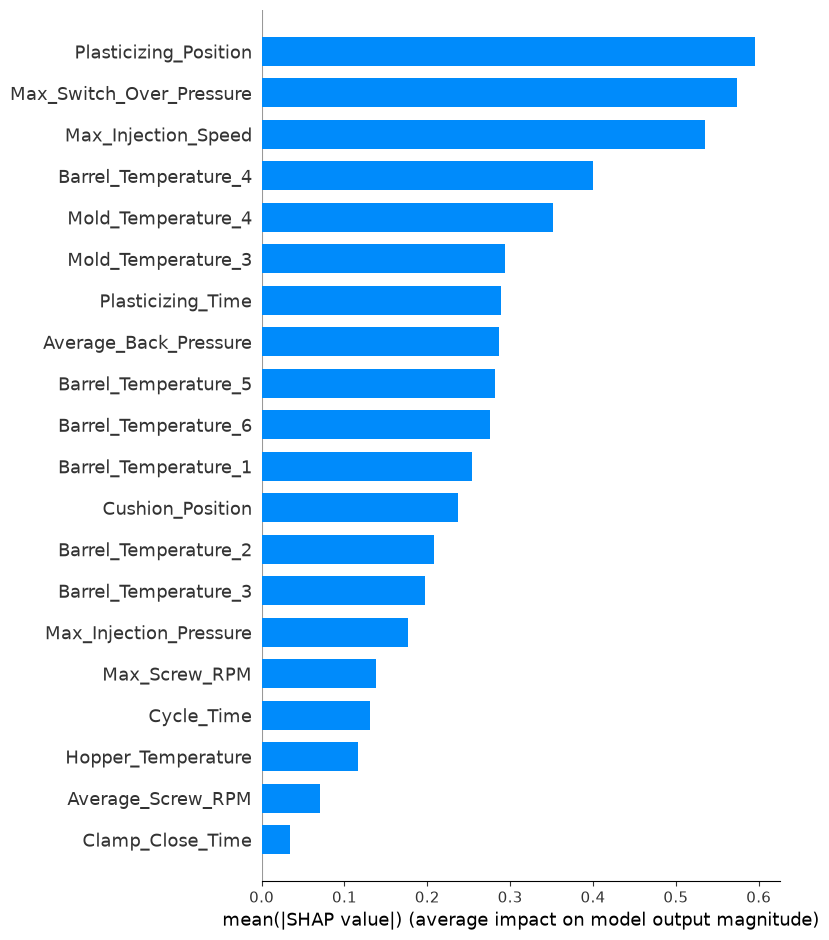

In [ ]:
shap.summary_plot(
    shap_arr,
    X_valid_original,
    plot_type="bar"
)

 # 15. SHAP 기반 RG3 공정 파생변수 생성

Original Feature 기반 LightGBM의 SHAP 분석 결과,
다음 변수들이 불량 판별에 높은 영향을 미치는 것으로 나타났다.

### 주요 변수

- Plasticizing_Position
- Max_Switch_Over_Pressure
- Max_Injection_Speed
- Barrel_Temperature_4
- Mold_Temperature_4
- Mold_Temperature_3
- Plasticizing_Time
- Average_Back_Pressure

중요 변수들은 크게 다음 공정 영역으로 구분할 수 있다.

1. 위치 및 가소화 상태
2. 사출 압력 및 속도
3. 배럴 / 금형 온도 상태
4. Screw RPM 및 공정 시간

따라서 개별 센서값뿐만 아니라
동일 Cycle 내부에서 여러 공정 변수가 형성하는 관계를
모델에 전달하기 위한 파생변수를 생성한다.

원본 데이터는 변수별 Standard Scaling이 적용되어 있으므로,
서로 다른 센서값의 비율을 실제 물리적 비율로 해석하기 어렵다.

따라서 Ratio Feature보다는

- 표준화 상태 간 차이
- 절대 차이
- 변수 간 상호작용
- 온도 센서군의 변동성

을 중심으로 Feature Engineering을 수행한다.

## 15-1. 위치 관련

In [ ]:
# 위치 관계

rg3_rh["Position_Contrast"] = (
    rg3_rh["Plasticizing_Position"]
    - rg3_rh["Cushion_Position"]
)

rg3_rh["Position_Abs_Contrast"] = (
    rg3_rh["Position_Contrast"].abs()
)

rg3_rh["PlasticizingPos_x_SwitchPressure"] = (
    rg3_rh["Plasticizing_Position"]
    * rg3_rh["Max_Switch_Over_Pressure"]
)

rg3_rh["PlasticizingPos_x_InjectionSpeed"] = (
    rg3_rh["Plasticizing_Position"]
    * rg3_rh["Max_Injection_Speed"]
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2246254043.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Position_Contrast"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2246254043.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Position_Abs_Contrast"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2246254043.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  C

In [ ]:
POSITION_FEATURES = [
    "Position_Contrast",
    "Position_Abs_Contrast",
    "PlasticizingPos_x_SwitchPressure",
    "PlasticizingPos_x_InjectionSpeed"
]

## 15-2. 압력 × 속도

In [ ]:
# 압력 관계

rg3_rh["Injection_Switch_Pressure_Contrast"] = (
    rg3_rh["Max_Injection_Pressure"]
    - rg3_rh["Max_Switch_Over_Pressure"]
)

rg3_rh["Injection_Switch_Pressure_Abs"] = (
    rg3_rh["Injection_Switch_Pressure_Contrast"].abs()
)

rg3_rh["Back_Pressure_Contrast"] = (
    rg3_rh["Max_Back_Pressure"]
    - rg3_rh["Average_Back_Pressure"]
)

rg3_rh["Back_Pressure_Abs"] = (
    rg3_rh["Back_Pressure_Contrast"].abs()
)

rg3_rh["SwitchPressure_x_InjectionSpeed"] = (
    rg3_rh["Max_Switch_Over_Pressure"]
    * rg3_rh["Max_Injection_Speed"]
)

rg3_rh["InjectionPressure_x_InjectionSpeed"] = (
    rg3_rh["Max_Injection_Pressure"]
    * rg3_rh["Max_Injection_Speed"]
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2103099362.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Injection_Switch_Pressure_Contrast"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2103099362.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Injection_Switch_Pressure_Abs"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2103099362.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which

In [ ]:
PRESSURE_SPEED_FEATURES = [
    "Injection_Switch_Pressure_Contrast",
    "Injection_Switch_Pressure_Abs",
    "Back_Pressure_Contrast",
    "Back_Pressure_Abs",
    "SwitchPressure_x_InjectionSpeed",
    "InjectionPressure_x_InjectionSpeed"
]

## 15-3. 온도 Balance

In [ ]:
BARREL_COLS = [
    "Barrel_Temperature_1",
    "Barrel_Temperature_2",
    "Barrel_Temperature_3",
    "Barrel_Temperature_4",
    "Barrel_Temperature_5",
    "Barrel_Temperature_6"
]

In [ ]:
# Barrel 온도 상태

rg3_rh["Barrel_Temp_Mean"] = (
    rg3_rh[BARREL_COLS]
    .mean(axis=1)
)

rg3_rh["Barrel_Temp_Std"] = (
    rg3_rh[BARREL_COLS]
    .std(axis=1)
)

rg3_rh["Barrel_Temp_Range"] = (
    rg3_rh[BARREL_COLS].max(axis=1)
    - rg3_rh[BARREL_COLS].min(axis=1)
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\964952455.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Barrel_Temp_Mean"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\964952455.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Barrel_Temp_Std"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\964952455.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider jo

In [ ]:
rg3_rh["Barrel_Front_Mean"] = (
    rg3_rh[
        [
            "Barrel_Temperature_1",
            "Barrel_Temperature_2",
            "Barrel_Temperature_3"
        ]
    ]
    .mean(axis=1)
)

rg3_rh["Barrel_Rear_Mean"] = (
    rg3_rh[
        [
            "Barrel_Temperature_4",
            "Barrel_Temperature_5",
            "Barrel_Temperature_6"
        ]
    ]
    .mean(axis=1)
)

rg3_rh["Barrel_Front_Rear_Contrast"] = (
    rg3_rh["Barrel_Rear_Mean"]
    - rg3_rh["Barrel_Front_Mean"]
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\799141992.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Barrel_Front_Mean"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\799141992.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Barrel_Rear_Mean"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\799141992.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider

In [ ]:
rg3_rh["Mold_Temp_Mean"] = (
    rg3_rh[
        [
            "Mold_Temperature_3",
            "Mold_Temperature_4"
        ]
    ]
    .mean(axis=1)
)

rg3_rh["Mold_Temp_Contrast"] = (
    rg3_rh["Mold_Temperature_4"]
    - rg3_rh["Mold_Temperature_3"]
)

rg3_rh["Mold_Temp_Abs_Contrast"] = (
    rg3_rh["Mold_Temp_Contrast"].abs()
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\3315482964.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Mold_Temp_Mean"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\3315482964.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Mold_Temp_Contrast"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\3315482964.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

In [ ]:
TEMP_FEATURES = [
    "Barrel_Temp_Mean",
    "Barrel_Temp_Std",
    "Barrel_Temp_Range",
    "Barrel_Front_Rear_Contrast",
    "Mold_Temp_Mean",
    "Mold_Temp_Contrast",
    "Mold_Temp_Abs_Contrast"
]

## 15-4. RPM / 시간 관계

In [ ]:
rg3_rh["Screw_RPM_Contrast"] = (
    rg3_rh["Max_Screw_RPM"]
    - rg3_rh["Average_Screw_RPM"]
)

rg3_rh["Screw_RPM_Abs_Contrast"] = (
    rg3_rh["Screw_RPM_Contrast"].abs()
)

rg3_rh["PlasticizingTime_x_CycleTime"] = (
    rg3_rh["Plasticizing_Time"]
    * rg3_rh["Cycle_Time"]
)

rg3_rh["PlasticizingTime_Cycle_Contrast"] = (
    rg3_rh["Plasticizing_Time"]
    - rg3_rh["Cycle_Time"]
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\1868861384.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Screw_RPM_Contrast"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\1868861384.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Screw_RPM_Abs_Contrast"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\1868861384.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

In [ ]:
RPM_TIME_FEATURES = [
    "Screw_RPM_Contrast",
    "Screw_RPM_Abs_Contrast",
    "PlasticizingTime_x_CycleTime",
    "PlasticizingTime_Cycle_Contrast"
]

# 16. 공정 파생변수 그룹별 성능 비교

생성한 모든 파생변수를 한 번에 추가하면
성능 변화의 원인을 파악하기 어렵다.

따라서 Original Feature를 Baseline으로 유지하고,
각 공정 영역의 파생변수를 하나씩 추가하여
성능 변화를 비교한다.

비교 Feature Set은 다음과 같다.

1. Original
2. Original + Position
3. Original + Pressure / Speed
4. Original + Temperature
5. Original + RPM / Time
6. Original + All Engineered

동일한 Random Split과 동일한 LightGBM 설정을 사용하여
파생변수 자체의 효과를 비교한다.

In [ ]:
dev = rg3_rh[
    rg3_rh["Session"].isin([1, 2, 3])
].copy()

In [ ]:
ENGINEERED_FEATURE_SETS = {
    "Original":
        PROCESS_COLS,

    "Original + Position":
        PROCESS_COLS
        + POSITION_FEATURES,

    "Original + PressureSpeed":
        PROCESS_COLS
        + PRESSURE_SPEED_FEATURES,

    "Original + Temperature":
        PROCESS_COLS
        + TEMP_FEATURES,

    "Original + RPMTime":
        PROCESS_COLS
        + RPM_TIME_FEATURES,

    "Original + All":
        PROCESS_COLS
        + POSITION_FEATURES
        + PRESSURE_SPEED_FEATURES
        + TEMP_FEATURES
        + RPM_TIME_FEATURES
}

In [ ]:
engineered_result = []

for feature_name, feature_cols in ENGINEERED_FEATURE_SETS.items():

    X_train_eng = dev.loc[
        train_idx,
        feature_cols
    ]

    X_valid_eng = dev.loc[
        valid_idx,
        feature_cols
    ]

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        num_leaves=7,
        class_weight="balanced",
        random_state=42,
        verbosity=-1
    )

    model.fit(
        X_train_eng,
        y_train_rand
    )

    valid_score = model.predict_proba(
        X_valid_eng
    )[:, 1]

    engineered_result.append({
        "Feature_Set": feature_name,
        "Feature_Count": len(feature_cols),
        "PR_AUC": average_precision_score(
            y_valid_rand,
            valid_score
        ),
        "ROC_AUC": roc_auc_score(
            y_valid_rand,
            valid_score
        )
    })

In [ ]:
engineered_result = (
    pd.DataFrame(engineered_result)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
)

engineered_result

,Feature_Set,Feature_Count,PR_AUC,ROC_AUC
4,Original + RPMTime,27,0.304083,0.781633
0,Original,23,0.285169,0.744898
3,Original + Temperature,30,0.074606,0.597959
1,Original + Position,27,0.065275,0.581633
2,Original + PressureSpeed,29,0.060228,0.534694
5,Original + All,44,0.038489,0.271429


## 16-1. 공정 파생변수 그룹별 성능 비교 결과

Original Feature를 기준으로 공정 영역별 파생변수를 추가하여
LightGBM 성능을 비교하였다.

### 성능 비교

| Feature Set | Feature 수 | PR-AUC | ROC-AUC |
|---|---:|---:|---:|
| Original + RPM / Time | 27 | 0.3041 | 0.7816 |
| Original | 23 | 0.2852 | 0.7449 |
| Original + Temperature | 30 | 0.0746 | 0.5980 |
| Original + Position | 27 | 0.0653 | 0.5816 |
| Original + Pressure / Speed | 29 | 0.0602 | 0.5347 |
| Original + All | 44 | 0.0385 | 0.2714 |

RPM 및 공정시간 관련 파생변수를 추가한 경우에만
Original Feature 대비 PR-AUC와 ROC-AUC가 모두 상승하였다.

반면 Position, Pressure / Speed, Temperature 파생변수는
성능을 크게 감소시켰다.

특히 모든 파생변수를 동시에 추가한 경우
가장 낮은 성능을 보여,
RG3와 같이 데이터 수와 불량 데이터가 적은 환경에서는
무분별한 Feature 확장이 오히려 과적합과 노이즈 증가를
유발할 수 있음을 확인하였다.

따라서 이후에는 성능이 개선된 RPM / Time 파생변수만 대상으로
각 Feature의 개별 기여도를 확인하고,
효과가 있는 변수만 선택적으로 확장한다.

# 17. RPM / Time 파생변수 개별 기여도 분석

RPM / Time 파생변수 그룹에서 성능 개선이 확인되었으므로,
각 파생변수를 Original Feature에 하나씩 추가하여
개별 Feature의 기여도를 확인한다.

모든 실험은 동일한 Train / Validation Index와
동일한 LightGBM 하이퍼파라미터를 사용한다.

이를 통해 실제 성능 향상에 기여하는 변수만 선별하고
불필요하거나 중복된 Feature는 제거한다.

In [ ]:
RPM_TIME_TEST_SETS = {
    "Original":
        PROCESS_COLS,

    "Original + RPM Contrast":
        PROCESS_COLS
        + ["Screw_RPM_Contrast"],

    "Original + RPM Abs Contrast":
        PROCESS_COLS
        + ["Screw_RPM_Abs_Contrast"],

    "Original + Plasticizing x Cycle":
        PROCESS_COLS
        + ["PlasticizingTime_x_CycleTime"],

    "Original + Plasticizing-Cycle Contrast":
        PROCESS_COLS
        + ["PlasticizingTime_Cycle_Contrast"],

    "Original + All RPMTime":
        PROCESS_COLS
        + RPM_TIME_FEATURES
}

In [ ]:
rpm_time_result = []

for feature_name, feature_cols in RPM_TIME_TEST_SETS.items():

    X_train_temp = dev.loc[
        train_idx,
        feature_cols
    ]

    X_valid_temp = dev.loc[
        valid_idx,
        feature_cols
    ]

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        num_leaves=7,
        class_weight="balanced",
        random_state=42,
        verbosity=-1
    )

    model.fit(
        X_train_temp,
        y_train_rand
    )

    valid_score = model.predict_proba(
        X_valid_temp
    )[:, 1]

    rpm_time_result.append({
        "Feature_Set": feature_name,
        "Feature_Count": len(feature_cols),
        "PR_AUC": average_precision_score(
            y_valid_rand,
            valid_score
        ),
        "ROC_AUC": roc_auc_score(
            y_valid_rand,
            valid_score
        )
    })

In [ ]:
rpm_time_result = (
    pd.DataFrame(rpm_time_result)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
)

rpm_time_result

,Feature_Set,Feature_Count,PR_AUC,ROC_AUC
5,Original + All RPMTime,27,0.304083,0.781633
0,Original,23,0.285169,0.744898
1,Original + RPM Contrast,24,0.284804,0.734694
2,Original + RPM Abs Contrast,24,0.284536,0.734694
3,Original + Plasticizing x Cycle,24,0.195349,0.755102
4,Original + Plasticizing-Cycle Contrast,24,0.157420,0.742857


## 17-1. RPM / Time 파생변수 개별 기여도 분석 결과

RPM / Time 파생변수를 Original Feature에 하나씩 추가하여
개별적인 성능 기여도를 확인하였다.

### 결과

| Feature Set | PR-AUC | ROC-AUC |
|---|---:|---:|
| Original + All RPMTime | 0.3041 | 0.7816 |
| Original | 0.2852 | 0.7449 |
| Original + RPM Contrast | 0.2848 | 0.7347 |
| Original + RPM Abs Contrast | 0.2845 | 0.7347 |
| Original + Plasticizing × Cycle | 0.1953 | 0.7551 |
| Original + Plasticizing-Cycle Contrast | 0.1574 | 0.7429 |

각 파생변수를 단독으로 추가했을 때는
Original Feature 대비 PR-AUC가 개선되지 않았다.

반면 4개의 RPM / Time 파생변수를 동시에 추가한 경우

- PR-AUC : 0.2852 → 0.3041
- ROC-AUC : 0.7449 → 0.7816

로 두 지표가 모두 개선되었다.

따라서 특정 단일 파생변수가 성능을 향상시켰다기보다는,
여러 RPM / 시간 관련 Feature가 함께 사용될 때
LightGBM이 변수 간 비선형적인 상호작용을 활용했을 가능성이 있다.

다만 전체 개발 데이터의 불량 수가 15건으로 매우 적고,
현재 Validation에는 약 5건의 불량만 존재하므로
PR-AUC 0.2852와 0.3041의 차이를 단일 Split 결과만으로
확정적인 개선이라고 판단하기는 어렵다.

따라서 다음 단계에서는 반복 Stratified Cross Validation을 통해
RPM / Time Feature의 성능 개선이 여러 데이터 분할에서도
안정적으로 유지되는지 확인한다.

# 18. Repeated Stratified Cross Validation

현재 개발 데이터의 불량 데이터가 15건으로 매우 적기 때문에,
단일 Train / Validation Split에서는
소수의 불량 예측 결과에 따라 평가 지표가 크게 변할 수 있다.

따라서 Repeated Stratified K-Fold를 사용하여
여러 데이터 분할에서 모델을 반복적으로 평가한다.

불량 데이터 수를 고려하여 3-Fold를 사용하고,
이를 10회 반복하여 총 30개의 Validation 성능을 측정한다.

비교 대상은 다음 두 가지이다.

1. Original Feature
2. Original + RPM / Time Feature

평균 PR-AUC와 ROC-AUC뿐만 아니라
각 지표의 표준편차도 함께 확인하여
파생변수의 성능 개선이 안정적인지 평가한다.

## 18-1 반복 교차검증

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd

CV_FEATURE_SETS = {
    "Original":
        PROCESS_COLS,

    "Original + RPMTime":
        PROCESS_COLS
        + RPM_TIME_FEATURES
}

In [ ]:
X_index = np.arange(len(dev))

y_cv = dev[
    "PassOrFail"
].reset_index(drop=True)

In [ ]:
rskf = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=10,
    random_state=42
)

In [ ]:
cv_results = []

for feature_name, feature_cols in CV_FEATURE_SETS.items():

    X_cv = (
        dev[feature_cols]
        .reset_index(drop=True)
    )

    fold_num = 1

    for train_cv_idx, valid_cv_idx in rskf.split(
        X_cv,
        y_cv
    ):

        X_train_cv = X_cv.iloc[
            train_cv_idx
        ]

        X_valid_cv = X_cv.iloc[
            valid_cv_idx
        ]

        y_train_cv = y_cv.iloc[
            train_cv_idx
        ]

        y_valid_cv = y_cv.iloc[
            valid_cv_idx
        ]

        model = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            num_leaves=7,
            class_weight="balanced",
            random_state=42,
            verbosity=-1
        )

        model.fit(
            X_train_cv,
            y_train_cv
        )

        valid_score = model.predict_proba(
            X_valid_cv
        )[:, 1]

        cv_results.append({
            "Feature_Set": feature_name,
            "Fold": fold_num,

            "PR_AUC": average_precision_score(
                y_valid_cv,
                valid_score
            ),

            "ROC_AUC": roc_auc_score(
                y_valid_cv,
                valid_score
            )
        })

        fold_num += 1

In [ ]:
cv_results = pd.DataFrame(
    cv_results
)

cv_summary = (
    cv_results
    .groupby("Feature_Set")
    .agg(
        PR_AUC_Mean=("PR_AUC", "mean"),
        PR_AUC_Std=("PR_AUC", "std"),
        PR_AUC_Min=("PR_AUC", "min"),
        PR_AUC_Max=("PR_AUC", "max"),

        ROC_AUC_Mean=("ROC_AUC", "mean"),
        ROC_AUC_Std=("ROC_AUC", "std")
    )
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
)

cv_summary

,PR_AUC_Mean,PR_AUC_Std,PR_AUC_Min,PR_AUC_Max,ROC_AUC_Mean,ROC_AUC_Std
Feature_Set,,,,,,
Original,0.104444,0.074596,0.032242,0.344115,0.566894,0.114057
Original + RPMTime,0.102510,0.069708,0.031425,0.335483,0.577083,0.124760


## 18-1. Repeated Stratified Cross Validation 결과

단일 Random Split에서는 RPM / Time 파생변수를 추가했을 때
PR-AUC가 0.2852에서 0.3041로 상승하였다.

그러나 3-Fold Stratified Cross Validation을 10회 반복하여
총 30회 평가한 결과는 다음과 같았다.

### Original

- PR-AUC Mean : 0.1044
- PR-AUC Std : 0.0746
- PR-AUC Min : 0.0322
- PR-AUC Max : 0.3441
- ROC-AUC Mean : 0.5669
- ROC-AUC Std : 0.1141

### Original + RPM / Time

- PR-AUC Mean : 0.1025
- PR-AUC Std : 0.0697
- PR-AUC Min : 0.0314
- PR-AUC Max : 0.3355
- ROC-AUC Mean : 0.5771
- ROC-AUC Std : 0.1248

반복 검증에서는 RPM / Time 파생변수를 추가해도
평균 PR-AUC가 개선되지 않았다.

따라서 단일 Split에서 나타난 성능 향상은
특정 Train / Validation 구성에 영향을 받은 결과일 가능성이 크며,
안정적으로 재현되는 Feature Engineering 효과라고 보기 어렵다.

또한 Fold별 PR-AUC 변동폭이 매우 크게 나타나
현재 RG3 데이터에서는 소수의 불량 데이터 구성에 따라
모델 성능이 크게 변하는 문제가 존재함을 확인하였다.

따라서 불필요한 파생변수를 계속 추가하기보다
현재 23개 Original Feature 중 실제로 반복적으로 유효한 변수만 선별하여
모델의 차원을 줄이는 방향으로 진행한다.

# 19. Fold 내부 Feature Selection

RG3 개발 데이터는 불량 데이터가 15건으로 매우 적은 반면
Original Feature는 23개 존재한다.

따라서 모든 변수를 동시에 사용하는 경우
불량과 직접적으로 관련되지 않은 변수가
모델의 일반화 성능을 저하시킬 가능성이 있다.

이를 확인하기 위해 각 Cross Validation Fold의
Train 데이터만 이용하여 Feature Importance를 계산하고,

- Top 3
- Top 5
- Top 8
- Top 10
- Top 15
- 전체 23개

Feature를 각각 사용하여 모델 성능을 비교한다.

Feature Selection 역시 Train Fold 내부에서 수행하여
Validation 정보가 변수 선택 과정에 포함되지 않도록 한다.

## 19-1 top k 실험

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score
from lightgbm import LGBMClassifier

import numpy as np
import pandas as pd

X_base = (
    dev[PROCESS_COLS]
    .reset_index(drop=True)
)

y_base = (
    dev["PassOrFail"]
    .reset_index(drop=True)
)

TOP_K_LIST = [
    3,
    5,
    8,
    10,
    15,
    23
]

In [ ]:
rskf = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=10,
    random_state=42
)

cv_splits = list(
    rskf.split(
        X_base,
        y_base
    )
)

In [ ]:
topk_results = []
selected_feature_records = []

for fold_num, (train_idx_cv, valid_idx_cv) in enumerate(
    cv_splits,
    start=1
):

    X_train_fold = X_base.iloc[
        train_idx_cv
    ]

    X_valid_fold = X_base.iloc[
        valid_idx_cv
    ]

    y_train_fold = y_base.iloc[
        train_idx_cv
    ]

    y_valid_fold = y_base.iloc[
        valid_idx_cv
    ]

    # ---------------------------------------
    # 1. Train Fold에서 Feature Importance 계산
    # ---------------------------------------

    selector_model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        num_leaves=7,
        class_weight="balanced",
        importance_type="gain",
        random_state=42,
        verbosity=-1
    )

    selector_model.fit(
        X_train_fold,
        y_train_fold
    )

    importance = pd.Series(
        selector_model.feature_importances_,
        index=PROCESS_COLS
    ).sort_values(
        ascending=False
    )

    # ---------------------------------------
    # 2. Top-K별 모델 평가
    # ---------------------------------------

    for k in TOP_K_LIST:

        selected_cols = (
            importance
            .head(k)
            .index
            .tolist()
        )

        model = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            num_leaves=7,
            class_weight="balanced",
            random_state=42,
            verbosity=-1
        )

        model.fit(
            X_train_fold[selected_cols],
            y_train_fold
        )

        valid_score = model.predict_proba(
            X_valid_fold[selected_cols]
        )[:, 1]

        topk_results.append({
            "Fold": fold_num,
            "Top_K": k,
            "PR_AUC": average_precision_score(
                y_valid_fold,
                valid_score
            ),
            "ROC_AUC": roc_auc_score(
                y_valid_fold,
                valid_score
            )
        })

        # Feature 선택 빈도 저장
        for feature in selected_cols:

            selected_feature_records.append({
                "Fold": fold_num,
                "Top_K": k,
                "Feature": feature
            })

## 19-2. Top-K별 평균 성능

In [ ]:
topk_results = pd.DataFrame(
    topk_results
)

topk_summary = (
    topk_results
    .groupby("Top_K")
    .agg(
        PR_AUC_Mean=("PR_AUC", "mean"),
        PR_AUC_Std=("PR_AUC", "std"),
        PR_AUC_Min=("PR_AUC", "min"),
        PR_AUC_Max=("PR_AUC", "max"),
        ROC_AUC_Mean=("ROC_AUC", "mean"),
        ROC_AUC_Std=("ROC_AUC", "std")
    )
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
)

topk_summary

,PR_AUC_Mean,PR_AUC_Std,PR_AUC_Min,PR_AUC_Max,ROC_AUC_Mean,ROC_AUC_Std
Top_K,,,,,,
8,0.107592,0.078816,0.036382,0.332249,0.549894,0.113501
10,0.105229,0.076465,0.035049,0.321765,0.555752,0.118969
15,0.103421,0.074740,0.033890,0.352753,0.563419,0.119984
23,0.101662,0.065845,0.032242,0.296882,0.566895,0.114577
5,0.096777,0.057942,0.038026,0.236014,0.529131,0.141657
3,0.083862,0.063270,0.031972,0.281386,0.501274,0.131755


## 19-3. 어떤 변수가 반복적으로 선택됐는지도 확인

In [ ]:
selected_feature_records = pd.DataFrame(
    selected_feature_records
)

top5_frequency = (
    selected_feature_records[
        selected_feature_records["Top_K"] == 5
    ]
    ["Feature"]
    .value_counts()
    .reset_index()
)

top5_frequency.columns = [
    "Feature",
    "Selected_Count"
]

top5_frequency

,Feature,Selected_Count
0,Hopper_Temperature,23
1,Barrel_Temperature_5,17
2,Mold_Temperature_3,17
3,Barrel_Temperature_4,17
4,Barrel_Temperature_1,12
5,Mold_Temperature_4,10
6,Max_Injection_Speed,10
7,Plasticizing_Time,8
8,Barrel_Temperature_3,7
9,Barrel_Temperature_2,7


## 19-1. Fold 내부 Feature Selection 결과

각 Cross Validation Fold의 Train 데이터만 이용하여
Feature Importance를 계산하고 Top-K Feature를 선택하였다.

### Top-K별 평균 성능

| Top-K | PR-AUC Mean | PR-AUC Std | ROC-AUC Mean |
|---:|---:|---:|---:|
| 8 | 0.1076 | 0.0788 | 0.5499 |
| 10 | 0.1052 | 0.0765 | 0.5558 |
| 15 | 0.1034 | 0.0747 | 0.5634 |
| 23 | 0.1017 | 0.0658 | 0.5669 |
| 5 | 0.0968 | 0.0579 | 0.5291 |
| 3 | 0.0839 | 0.0633 | 0.5013 |

Top 8 Feature에서 가장 높은 평균 PR-AUC를 기록하였지만,
전체 23개 Feature와의 차이는 매우 작았다.

따라서 단순히 Feature 수를 줄이는 것만으로는
RG3의 불량 탐지 성능을 크게 개선하기 어려운 것으로 판단된다.

또한 Fold별 Feature 선택 빈도를 확인한 결과,

- Hopper_Temperature : 23회
- Barrel_Temperature_5 : 17회
- Mold_Temperature_3 : 17회
- Barrel_Temperature_4 : 17회

등은 비교적 반복적으로 선택되었다.

반면 단일 Random Split SHAP 분석에서 중요도가 매우 높았던

- Plasticizing_Position
- Max_Switch_Over_Pressure

등은 반복 검증에서는 선택 빈도가 낮았다.

이는 현재 불량 데이터가 15건에 불과하기 때문에
Train 데이터에 포함되는 불량 샘플 구성에 따라
모델이 중요하게 판단하는 Feature가 크게 달라지는 것을 의미한다.

따라서 이후에는 특정 Feature Set에 과도하게 의존하기보다,
동일한 반복 Cross Validation 환경에서 여러 모델을 비교하여
RG3 데이터에서 상대적으로 안정적인 학습 알고리즘을 탐색한다.

# 20. 반복 교차검증 기반 모델 비교

Feature Engineering 및 Feature Selection만으로는
안정적인 성능 향상이 확인되지 않았다.

따라서 Original Feature 23개를 동일하게 사용하고,
여러 분류 알고리즘을 동일한 Repeated Stratified Cross Validation 환경에서 비교한다.

비교 모델은 다음과 같다.

1. Logistic Regression
2. Random Forest
3. Extra Trees
4. LightGBM
5. XGBoost
6. CatBoost
7. RBF-SVM

모든 모델은 동일한 30개 Train / Validation Fold에서 평가하며,
평균 PR-AUC와 ROC-AUC 및 표준편차를 비교한다.

이를 통해 특정 데이터 분할에서만 높은 성능을 보이는 모델이 아니라,
여러 불량 샘플 구성에서도 상대적으로 안정적인 모델을 탐색한다.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

import numpy as np
import pandas as pd

In [ ]:
X_model = (
    dev[PROCESS_COLS]
    .reset_index(drop=True)
)

y_model = (
    dev["PassOrFail"]
    .reset_index(drop=True)
)

model_results = []

for fold_num, (train_idx_cv, valid_idx_cv) in enumerate(
    cv_splits,
    start=1
):

    X_train_cv = X_model.iloc[train_idx_cv]
    X_valid_cv = X_model.iloc[valid_idx_cv]

    y_train_cv = y_model.iloc[train_idx_cv]
    y_valid_cv = y_model.iloc[valid_idx_cv]

    neg = (y_train_cv == 0).sum()
    pos = (y_train_cv == 1).sum()

    scale_pos_weight = neg / pos


    models = {

        "Logistic Regression": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=3000,
                    random_state=42
                )
            )
        ]),

        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            max_depth=4,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        "Extra Trees": ExtraTreesClassifier(
            n_estimators=500,
            max_depth=4,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        "LightGBM": LGBMClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            num_leaves=7,
            class_weight="balanced",
            random_state=42,
            verbosity=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ),

        "CatBoost": CatBoostClassifier(
            iterations=300,
            depth=4,
            learning_rate=0.03,
            class_weights=[
                1,
                scale_pos_weight
            ],
            random_seed=42,
            verbose=False
        ),

        "RBF-SVM": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                SVC(
                    kernel="rbf",
                    C=1.0,
                    gamma="scale",
                    class_weight="balanced",
                    probability=True,
                    random_state=42
                )
            )
        ])
    }


    for model_name, model in models.items():

        model.fit(
            X_train_cv,
            y_train_cv
        )

        valid_score = model.predict_proba(
            X_valid_cv
        )[:, 1]

        model_results.append({
            "Fold": fold_num,
            "Model": model_name,

            "PR_AUC": average_precision_score(
                y_valid_cv,
                valid_score
            ),

            "ROC_AUC": roc_auc_score(
                y_valid_cv,
                valid_score
            )
        })

c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` param

In [ ]:
model_results = []

for fold_num, (train_idx_cv, valid_idx_cv) in enumerate(
    cv_splits,
    start=1
):

    X_train_cv = X_model.iloc[train_idx_cv]
    X_valid_cv = X_model.iloc[valid_idx_cv]

    y_train_cv = y_model.iloc[train_idx_cv]
    y_valid_cv = y_model.iloc[valid_idx_cv]

    neg = (y_train_cv == 0).sum()
    pos = (y_train_cv == 1).sum()

    scale_pos_weight = neg / pos


    models = {

        "Logistic Regression": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=3000,
                    random_state=42
                )
            )
        ]),

        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            max_depth=4,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        "Extra Trees": ExtraTreesClassifier(
            n_estimators=500,
            max_depth=4,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        "LightGBM": LGBMClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            num_leaves=7,
            class_weight="balanced",
            random_state=42,
            verbosity=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ),

        "CatBoost": CatBoostClassifier(
            iterations=300,
            depth=4,
            learning_rate=0.03,
            class_weights=[
                1,
                scale_pos_weight
            ],
            random_seed=42,
            verbose=False
        ),

        "RBF-SVM": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                SVC(
                    kernel="rbf",
                    C=1.0,
                    gamma="scale",
                    class_weight="balanced",
                    probability=True,
                    random_state=42
                )
            )
        ])
    }


    for model_name, model in models.items():

        model.fit(
            X_train_cv,
            y_train_cv
        )

        valid_score = model.predict_proba(
            X_valid_cv
        )[:, 1]

        model_results.append({
            "Fold": fold_num,
            "Model": model_name,

            "PR_AUC": average_precision_score(
                y_valid_cv,
                valid_score
            ),

            "ROC_AUC": roc_auc_score(
                y_valid_cv,
                valid_score
            )
        })

c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` param

In [ ]:
model_results = pd.DataFrame(
    model_results
)

model_summary = (
    model_results
    .groupby("Model")
    .agg(
        PR_AUC_Mean=("PR_AUC", "mean"),
        PR_AUC_Std=("PR_AUC", "std"),
        PR_AUC_Min=("PR_AUC", "min"),
        PR_AUC_Max=("PR_AUC", "max"),

        ROC_AUC_Mean=("ROC_AUC", "mean"),
        ROC_AUC_Std=("ROC_AUC", "std")
    )
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
)

model_summary

,PR_AUC_Mean,PR_AUC_Std,PR_AUC_Min,PR_AUC_Max,ROC_AUC_Mean,ROC_AUC_Std
Model,,,,,,
XGBoost,0.112075,0.087885,0.034346,0.499440,0.585635,0.114319
CatBoost,0.108822,0.065538,0.041839,0.310109,0.599800,0.102603
LightGBM,0.104444,0.074596,0.032242,0.344115,0.566894,0.114057
Random Forest,0.092380,0.062292,0.034926,0.304641,0.568252,0.092357
RBF-SVM,0.078345,0.041546,0.029998,0.207592,0.512096,0.186525
Extra Trees,0.069414,0.025555,0.032704,0.147704,0.547251,0.095823
Logistic Regression,0.062237,0.042388,0.028983,0.271919,0.451261,0.113152


## 20-1. 반복 교차검증 기반 모델 비교 결과

Original Feature 23개를 동일하게 사용하고,
Repeated Stratified 3-Fold Cross Validation을 10회 반복하여
총 30개 Fold에서 여러 분류 모델을 비교하였다.

### 주요 결과

- XGBoost
  - PR-AUC Mean : 0.1121
  - ROC-AUC Mean : 0.5856

- CatBoost
  - PR-AUC Mean : 0.1088
  - ROC-AUC Mean : 0.5998

- LightGBM
  - PR-AUC Mean : 0.1044
  - ROC-AUC Mean : 0.5669

PR-AUC 기준으로는 XGBoost가 가장 높은 평균 성능을 보였으며,
ROC-AUC 기준으로는 CatBoost가 가장 높은 성능을 보였다.

그러나 XGBoost의 Fold별 PR-AUC는
0.0343 ~ 0.4994로 매우 큰 변동폭을 보였다.

이는 모델 자체가 불량 신호를 전혀 학습하지 못하는 것은 아니지만,
전체 불량 데이터가 15건에 불과하기 때문에
각 Fold의 Train에 포함되는 소수 불량 샘플의 구성에 따라
학습 결과가 크게 달라지는 것으로 해석할 수 있다.

따라서 이후에는 XGBoost를 우선 모델로 사용하고,
소수 클래스 학습 문제를 완화하기 위한
Over Sampling 방법을 적용하여 성능 변화를 비교한다.

단, Oversampling은 반드시 각 Cross Validation의
Train Fold 내부에서만 수행하여
Validation 데이터가 학습 과정에 포함되지 않도록 한다.

# 21. 불균형 데이터 Over Sampling 비교

RG3 개발 데이터에는 정상 326건에 비해
불량이 15건만 존재하여 약 4.4%의 불량률을 보인다.

3-Fold Cross Validation에서는 각 Train Fold에
약 10개의 불량 데이터만 포함되므로,
불량 패턴을 안정적으로 학습하기 어렵다.

따라서 PR-AUC가 가장 높았던 XGBoost를 기준으로
다음 불균형 처리 방법을 비교한다.

1. Class Weight
2. Random Over Sampling
3. SMOTE

Oversampling은 반드시 Train Fold 내부에서만 수행하여
Validation 데이터에 대한 Data Leakage를 방지한다.

또한 제조 공정 데이터에서는 SMOTE가 실제로 존재하지 않는
센서 조합을 생성할 가능성이 있으므로,
성능뿐만 아니라 방법의 물리적 타당성도 함께 고려한다.

In [ ]:
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

import pandas as pd

In [ ]:
X_os = (
    dev[PROCESS_COLS]
    .reset_index(drop=True)
)

y_os = (
    dev["PassOrFail"]
    .reset_index(drop=True)
)

In [ ]:
sampling_results = []

In [ ]:
for fold_num, (train_idx_cv, valid_idx_cv) in enumerate(
    cv_splits,
    start=1
):

    X_train_cv = X_os.iloc[
        train_idx_cv
    ]

    X_valid_cv = X_os.iloc[
        valid_idx_cv
    ]

    y_train_cv = y_os.iloc[
        train_idx_cv
    ]

    y_valid_cv = y_os.iloc[
        valid_idx_cv
    ]


    # =========================================
    # 1. 기존 Class Weight 방식
    # =========================================

    neg = (y_train_cv == 0).sum()
    pos = (y_train_cv == 1).sum()

    scale_pos_weight = neg / pos

    baseline_model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )

    baseline_model.fit(
        X_train_cv,
        y_train_cv
    )

    baseline_score = baseline_model.predict_proba(
        X_valid_cv
    )[:, 1]

    sampling_results.append({
        "Fold": fold_num,
        "Method": "Class Weight",
        "PR_AUC": average_precision_score(
            y_valid_cv,
            baseline_score
        ),
        "ROC_AUC": roc_auc_score(
            y_valid_cv,
            baseline_score
        )
    })


    # =========================================
    # 2. Random Over Sampling
    # =========================================

    ros = RandomOverSampler(
        random_state=42
    )

    X_train_ros, y_train_ros = ros.fit_resample(
        X_train_cv,
        y_train_cv
    )

    ros_model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,

        # 이미 Oversampling 했으므로
        # 추가 Class Weight는 적용하지 않음
        scale_pos_weight=1,

        eval_metric="logloss",
        random_state=42
    )

    ros_model.fit(
        X_train_ros,
        y_train_ros
    )

    ros_score = ros_model.predict_proba(
        X_valid_cv
    )[:, 1]

    sampling_results.append({
        "Fold": fold_num,
        "Method": "RandomOverSampler",
        "PR_AUC": average_precision_score(
            y_valid_cv,
            ros_score
        ),
        "ROC_AUC": roc_auc_score(
            y_valid_cv,
            ros_score
        )
    })


    # =========================================
    # 3. SMOTE
    # =========================================

    smote = SMOTE(
        k_neighbors=3,
        random_state=42
    )

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train_cv,
        y_train_cv
    )

    smote_model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1,
        eval_metric="logloss",
        random_state=42
    )

    smote_model.fit(
        X_train_smote,
        y_train_smote
    )

    smote_score = smote_model.predict_proba(
        X_valid_cv
    )[:, 1]

    sampling_results.append({
        "Fold": fold_num,
        "Method": "SMOTE",
        "PR_AUC": average_precision_score(
            y_valid_cv,
            smote_score
        ),
        "ROC_AUC": roc_auc_score(
            y_valid_cv,
            smote_score
        )
    })

In [ ]:
sampling_results = pd.DataFrame(
    sampling_results
)

sampling_summary = (
    sampling_results
    .groupby("Method")
    .agg(
        PR_AUC_Mean=("PR_AUC", "mean"),
        PR_AUC_Std=("PR_AUC", "std"),
        PR_AUC_Min=("PR_AUC", "min"),
        PR_AUC_Max=("PR_AUC", "max"),

        ROC_AUC_Mean=("ROC_AUC", "mean"),
        ROC_AUC_Std=("ROC_AUC", "std")
    )
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
)

sampling_summary

,PR_AUC_Mean,PR_AUC_Std,PR_AUC_Min,PR_AUC_Max,ROC_AUC_Mean,ROC_AUC_Std
Method,,,,,,
RandomOverSampler,0.114090,0.092805,0.032304,0.459099,0.579563,0.130584
Class Weight,0.112075,0.087885,0.034346,0.499440,0.585635,0.114319
SMOTE,0.077159,0.036947,0.032460,0.171335,0.521223,0.111730


## 21-1. Over Sampling 비교 결과

XGBoost를 기준으로 Class Weight, Random Over Sampling,
SMOTE를 동일한 Repeated Stratified Cross Validation 환경에서 비교하였다.

### 결과

| Method | PR-AUC Mean | PR-AUC Std | ROC-AUC Mean |
|---|---:|---:|---:|
| Random Over Sampling | 0.1141 | 0.0928 | 0.5796 |
| Class Weight | 0.1121 | 0.0879 | 0.5856 |
| SMOTE | 0.0772 | 0.0369 | 0.5212 |

Random Over Sampling은 Class Weight보다
PR-AUC가 소폭 상승하였으나 차이가 매우 작았으며,
ROC-AUC는 오히려 감소하였다.

따라서 Random Over Sampling을 통한 개선은
실질적인 성능 향상으로 보기 어렵다.

SMOTE의 경우 PR-AUC와 ROC-AUC가 모두 감소하였다.

이는 소수의 불량 데이터 사이를 보간하여 생성한 합성 데이터가
실제 RG3 공정의 불량 패턴을 충분히 표현하지 못했거나,
서로 다른 유형의 불량 데이터 사이에서
비현실적인 합성 공정 상태를 생성했을 가능성을 시사한다.

따라서 단순한 클래스 불균형 처리보다는,
현재 하나의 PassOrFail=1로 묶여 있는 불량 데이터 내부에
서로 다른 공정 패턴이 존재하는지 확인할 필요가 있다.

# 22. 불량 데이터 내부 패턴 분석

현재 RG3 개발 데이터에는 불량 데이터가 총 15건 존재한다.

앞선 분석에서는 Session 2와 Session 3 사이에서
다수의 공정 변수의 불량 변화 방향이 서로 다르게 나타났으며,
다양한 모델 및 불균형 처리 방법에서도
안정적인 성능 향상이 나타나지 않았다.

따라서 PassOrFail=1로 동일하게 Labeling된 불량 데이터가
실제로 하나의 동일한 공정 이상 패턴을 가지고 있는지 확인한다.

분석 절차는 다음과 같다.

1. 불량 데이터만 추출
2. 공정 변수 Heatmap 확인
3. PCA를 이용한 저차원 표현
4. 계층적 군집 또는 K-Means를 이용한 불량 유형 탐색
5. Cluster별 공정 특성 비교

이를 통해 불량 데이터 내부에 여러 유형의 이상 패턴이 존재하는지 확인한다.

In [ ]:
defect_dev = (
    dev[
        dev["PassOrFail"] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

print("Defect Count:", len(defect_dev))
print()

display(
    defect_dev[
        [
            "TimeStamp",
            "Session"
        ] + PROCESS_COLS
    ]
)

Defect Count: 15



,TimeStamp,Session,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,2020-10-22 00:51:52,2,-0.029099,-1.192531,-0.042538,0.249511,-0.386790,0.480326,-0.192928,0.617645,...,-1.074373,0.562844,-1.950268,0.919808,-0.829743,1.223110,-0.851297,1.200026,-1.108521,-0.969082
1,2020-10-22 01:04:15,2,-0.029099,-1.192531,0.406400,0.249511,-0.386790,0.480326,-0.192928,0.617645,...,-1.074373,-0.136479,0.715557,-0.616737,-0.537231,-0.657751,-1.845598,0.081547,-0.823555,-0.847689
2,2020-10-22 01:09:23,2,-0.029099,-1.192531,0.855360,0.249511,-0.386790,1.277707,0.588367,0.617645,...,0.320621,0.329736,0.230835,-0.002081,0.778986,-0.030765,0.143005,0.386588,-0.823555,-0.969082
3,2020-10-22 01:26:54,2,-0.029099,-1.192531,-0.491498,0.249511,-0.386790,0.480326,0.588367,0.617645,...,0.320621,1.495203,-1.465546,-0.002081,1.656478,-0.344258,0.143005,1.200026,-0.823555,-0.847689
4,2020-10-22 01:57:47,2,-0.029099,-1.192531,0.406400,0.249511,-0.386790,1.277707,-0.192928,1.402554,...,-0.609381,0.795880,0.473196,-0.309409,1.363966,0.596220,-0.851297,0.284910,-0.823555,-0.847689
5,2020-10-22 04:46:36,3,-0.029099,0.838552,0.181942,0.249511,1.033078,0.480326,-1.755816,0.617645,...,-0.841877,-0.602623,-0.011452,-0.002081,0.340262,0.282727,0.640193,0.589944,-0.396108,-0.483514
6,2020-10-22 04:48:39,3,-0.029099,0.838552,1.528778,0.249511,1.033078,0.480326,-0.974521,0.617645,...,-0.144380,0.795880,1.442567,-0.002081,0.632729,-0.344258,0.143005,0.589944,-0.538588,-0.483514
7,2020-10-22 04:51:46,3,-0.029099,-1.192531,1.753258,-0.298708,1.033078,1.277707,-0.974521,1.402554,...,-0.609381,0.329736,-1.223184,-0.002081,-0.683487,0.596220,1.634495,0.589944,-0.111141,-0.362122
8,2020-10-22 04:57:56,3,-0.029099,0.838552,0.630880,-0.846822,1.033078,0.480326,-0.192928,0.617645,...,1.018118,-1.068838,-0.980897,0.305246,1.802734,0.282727,0.640193,0.691629,-0.253624,-0.362122
9,2020-10-22 05:10:17,3,-0.029099,-1.192531,0.855360,0.249511,1.033078,0.480326,-0.974521,0.617645,...,-0.144380,0.096629,-0.011452,0.612574,-0.829743,0.282727,-0.354184,-0.223487,0.031342,-0.240729


c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\seaborn\matrix.py:243: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  self.cmap.set_bad(bad)


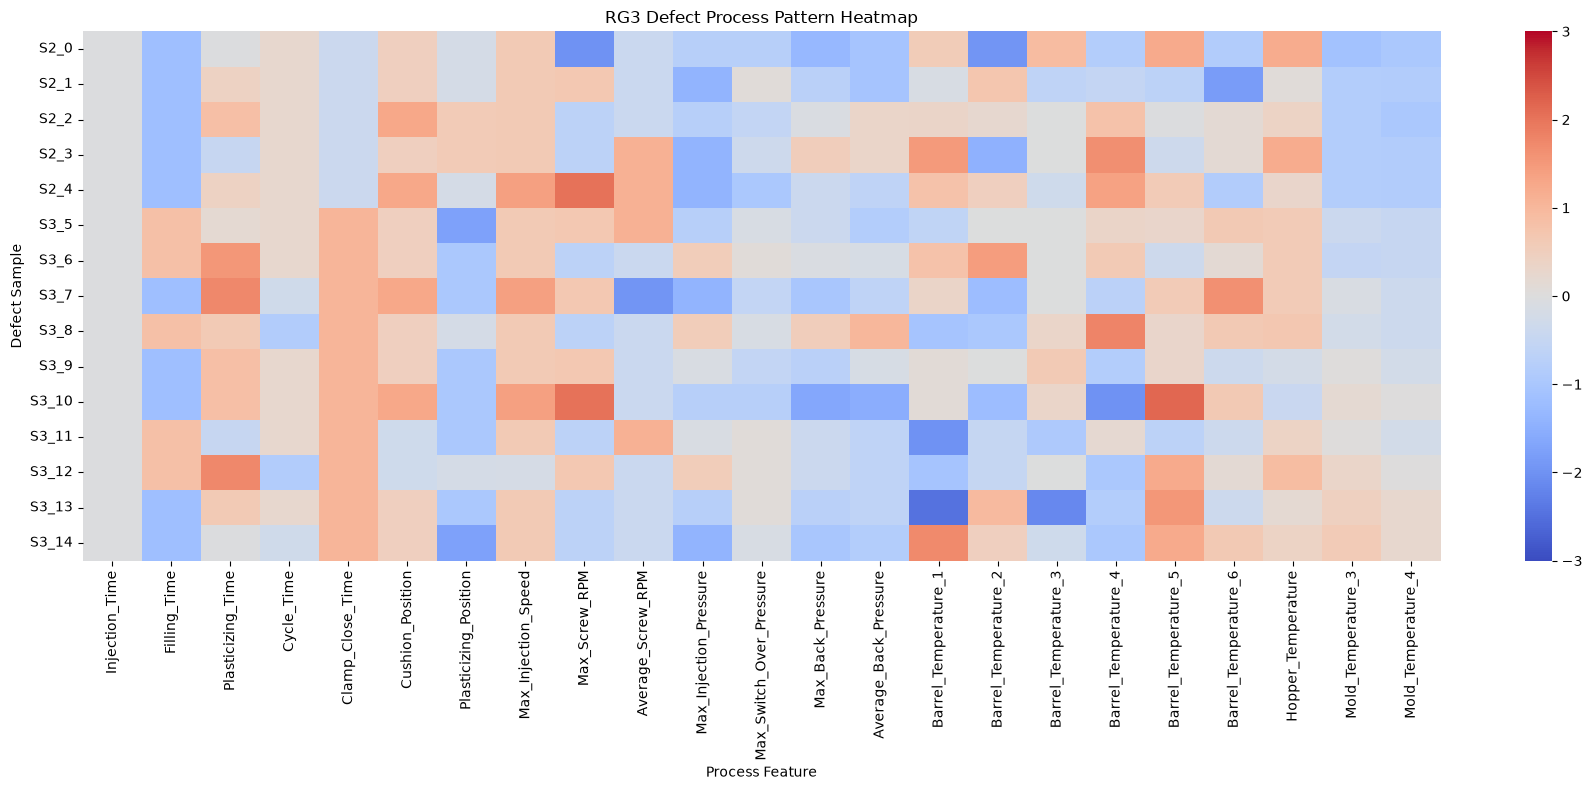

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(
    figsize=(18, 8)
)

sns.heatmap(
    defect_dev[PROCESS_COLS],
    cmap="coolwarm",
    center=0,
    vmin=-3,
    vmax=3,
    yticklabels=[
        f"S{session}_{i}"
        for i, session in enumerate(
            defect_dev["Session"]
        )
    ]
)

plt.title(
    "RG3 Defect Process Pattern Heatmap"
)

plt.xlabel(
    "Process Feature"
)

plt.ylabel(
    "Defect Sample"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()
plt.show()

## 22-3. PCA 기반 불량 패턴 시각화

23개의 공정 변수를 2개의 주성분으로 축소하여
불량 데이터 간의 상대적인 위치를 확인한다.

PCA는 최종 분류 모델로 사용하기 위한 것이 아니라,
불량 데이터 내부의 군집 구조와
Session별 분리 여부를 시각적으로 확인하기 위해 사용한다.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_defect = defect_dev[
    PROCESS_COLS
].copy()

scaler_defect = StandardScaler()

X_defect_scaled = scaler_defect.fit_transform(
    X_defect
)

pca = PCA(
    n_components=2
)

X_defect_pca = pca.fit_transform(
    X_defect_scaled
)
defect_pca = pd.DataFrame({
    "PC1": X_defect_pca[:, 0],
    "PC2": X_defect_pca[:, 1],
    "Session": defect_dev["Session"],
    "TimeStamp": defect_dev["TimeStamp"]
})

defect_pca


,PC1,PC2,Session,TimeStamp
0,-2.591963,-1.507740,2,2020-10-22 00:51:52
1,-1.604874,-0.690857,2,2020-10-22 01:04:15
2,-3.066381,-0.228468,2,2020-10-22 01:09:23
3,-4.642816,1.190412,2,2020-10-22 01:26:54
4,-3.011053,-2.593890,2,2020-10-22 01:57:47
5,0.494636,0.872074,3,2020-10-22 04:46:36
6,0.186384,2.236228,3,2020-10-22 04:48:39
7,1.372272,-2.630935,3,2020-10-22 04:51:46
8,-0.234635,3.719096,3,2020-10-22 04:57:56
9,1.038651,-0.781824,3,2020-10-22 05:10:17


In [ ]:
print(
    "PC1:",
    pca.explained_variance_ratio_[0]
)

print(
    "PC2:",
    pca.explained_variance_ratio_[1]
)

print(
    "Total:",
    pca.explained_variance_ratio_.sum()
)

PC1: 0.25838778542727875
PC2: 0.23577512407245543
Total: 0.4941629094997342


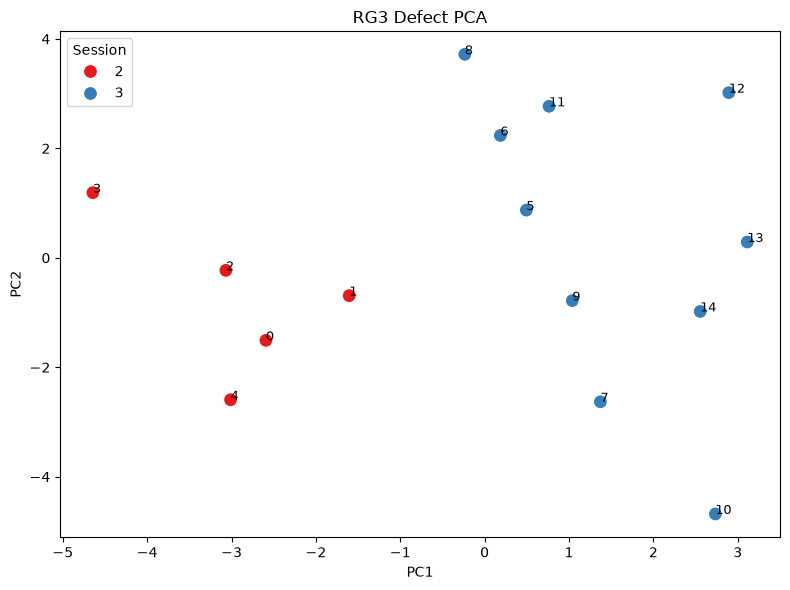

In [ ]:
plt.figure(
    figsize=(8, 6)
)

sns.scatterplot(
    data=defect_pca,
    x="PC1",
    y="PC2",
    hue="Session",
    palette="Set1",
    s=100
)

for i, row in defect_pca.iterrows():

    plt.text(
        row["PC1"],
        row["PC2"],
        str(i),
        fontsize=9
    )

plt.title(
    "RG3 Defect PCA"
)

plt.tight_layout()
plt.show()

## 22-4. 불량 데이터 Cluster 탐색

PCA 시각화와 함께 K-Means Clustering을 사용하여
불량 데이터 내부에 여러 공정 패턴이 존재하는지 확인한다.

불량 데이터가 15건으로 매우 적기 때문에
Cluster 수를 과도하게 늘리지 않고
2~4개의 Cluster 후보만 비교한다.

Silhouette Score를 이용하여
Cluster 분리가 상대적으로 명확한 구조가 존재하는지 확인한다.

### K-Means Cluster 수 비교

불량 데이터 내부에 서로 다른 공정 패턴이 존재하는지 확인하기 위해
K-Means Clustering을 적용한다.

Cluster 수는 2~4개로 비교하며,
Silhouette Score가 높을수록
Cluster 간 분리가 상대적으로 명확하다고 해석한다.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

cluster_result_rows = []

for k in [2, 3, 4]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(
        X_defect_scaled
    )

    score = silhouette_score(
        X_defect_scaled,
        labels
    )

    cluster_result_rows.append({
        "K": k,
        "Silhouette_Score": score
    })

cluster_results = pd.DataFrame(
    cluster_result_rows
)

cluster_results

,K,Silhouette_Score
0,2,0.158095
1,3,0.167339
2,4,0.146288


## 22-5. 불량 Cluster 수 비교 결과

RG3 개발 데이터의 불량 15건을 대상으로
K-Means Clustering을 수행하고
Cluster 수 2~4에 대한 Silhouette Score를 비교하였다.

### 결과

| Cluster 수 | Silhouette Score |
|---:|---:|
| 2 | 0.1581 |
| 3 | 0.1673 |
| 4 | 0.1463 |

K=3에서 가장 높은 Silhouette Score를 기록하였으나,
최고 점수가 약 0.167로 전반적으로 낮게 나타났다.

따라서 현재 불량 데이터가
서로 명확하게 분리되는 몇 개의 독립적인 유형으로 구성되어 있다고
단정하기는 어렵다.

즉 RG3의 불량은

- 명확한 단일 불량 패턴
- 명확하게 분리된 여러 불량 유형

중 어느 한쪽으로 단순하게 설명되기보다는,
여러 공정 조건이 연속적으로 겹쳐 있는 형태일 가능성이 있다.

다만 K=3이 상대적으로 가장 높은 점수를 보였으므로,
탐색 목적으로 3개의 Cluster를 생성하고
각 Cluster가 생산 Session과 어떤 관계를 가지는지 추가로 확인한다.

## 22-6. 불량 Cluster와 생산 Session 관계

Silhouette Score가 가장 높았던 K=3을 탐색적으로 사용하여
각 불량 데이터에 Cluster Label을 부여한다.

이후 Cluster와 생산 Session의 관계를 비교하여,
불량 패턴의 차이가 생산 Session 변화와 관련되어 있는지 확인한다.

Cluster가 특정 Session에 집중된다면
Session별 공정 상태 변화와 불량 패턴 변화가 연결되어 있을 가능성이 있다.

반대로 각 Cluster에 여러 Session의 불량이 혼합되어 있다면,
불량 패턴의 차이를 단순한 Session 변화만으로 설명하기 어렵다.

In [ ]:
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

defect_dev["Defect_Cluster"] = kmeans_3.fit_predict(
    X_defect_scaled
)

In [ ]:
defect_dev[
    "Defect_Cluster"
].value_counts().sort_index()

Defect_Cluster
0    5
1    5
2    5
Name: count, dtype: int64

In [ ]:
pd.crosstab(
    defect_dev["Session"],
    defect_dev["Defect_Cluster"],
    margins=True
)

Defect_Cluster,0,1,2,All
Session,,,,
2,0,5,0,5
3,5,0,5,10
All,5,5,5,15


In [ ]:
defect_dev[
    [
        "TimeStamp",
        "Session",
        "Defect_Cluster"
    ]
].sort_values(
    "TimeStamp"
)

,TimeStamp,Session,Defect_Cluster
0,2020-10-22 00:51:52,2,1
1,2020-10-22 01:04:15,2,1
2,2020-10-22 01:09:23,2,1
3,2020-10-22 01:26:54,2,1
4,2020-10-22 01:57:47,2,1
5,2020-10-22 04:46:36,3,0
6,2020-10-22 04:48:39,3,0
7,2020-10-22 04:51:46,3,2
8,2020-10-22 04:57:56,3,0
9,2020-10-22 05:10:17,3,2


In [ ]:
cluster_profile = (
    defect_dev
    .groupby(
        "Defect_Cluster"
    )[PROCESS_COLS]
    .mean()
    .T
)

cluster_profile

Defect_Cluster,0,1,2
Injection_Time,-0.029099,-0.029099,-0.029099
Filling_Time,0.838552,-1.192531,-1.192531
Plasticizing_Time,0.720672,0.226825,0.810464
Cycle_Time,-0.189022,0.249511,0.030223
Clamp_Close_Time,1.033078,-0.386790,1.033078
Cushion_Position,0.161373,0.799278,0.799278
Plasticizing_Position,-0.818142,0.119590,-1.130780
Max_Injection_Speed,0.460639,0.774627,0.931609
Max_Screw_RPM,-0.128608,-0.128602,0.408537
Average_Screw_RPM,0.193715,0.193715,-0.729554


In [ ]:
cluster_profile[
    "Cluster_Range"
] = (
    cluster_profile.max(axis=1)
    - cluster_profile.min(axis=1)
)

In [ ]:
cluster_profile.sort_values(
    "Cluster_Range",
    ascending=False
).head(15)

Defect_Cluster,0,1,2,Cluster_Range
Filling_Time,0.838552,-1.192531,-1.192531,2.031084
Barrel_Temperature_4,0.398755,0.486491,-1.063726,1.550218
Clamp_Close_Time,1.033078,-0.386790,1.033078,1.419868
Barrel_Temperature_1,-0.789123,0.609437,-0.043222,1.398560
Max_Injection_Pressure,0.153706,-1.159074,-0.896506,1.312780
Plasticizing_Position,-0.818142,0.119590,-1.130780,1.250370
Mold_Temperature_3,-0.168134,-0.880548,0.230818,1.111365
Barrel_Temperature_6,0.242442,-0.652436,0.441303,1.093739
Barrel_Temperature_5,0.157311,0.157311,1.160450,1.003139
Average_Screw_RPM,0.193715,0.193715,-0.729554,0.923268


## 22-7. 불량 Cluster와 생산 Session 관계 분석

불량 데이터 15건에 대해 K=3으로 군집화한 결과,
각 Cluster는 다음과 같이 구성되었다.

- Cluster 0 : 5건
- Cluster 1 : 5건
- Cluster 2 : 5건

생산 Session과 비교한 결과,

| Session | Cluster 0 | Cluster 1 | Cluster 2 |
|---:|---:|---:|---:|
| 2 | 0 | 5 | 0 |
| 3 | 5 | 0 | 5 |

Cluster 1은 Session 2의 불량 5건과 완전히 일치하였으며,
Session 3의 불량 10건은 Cluster 0과 Cluster 2로 나뉘었다.

또한 Cluster 간 차이가 큰 변수에는

- Filling_Time
- Clamp_Close_Time
- Barrel_Temperature
- Plasticizing_Position
- Mold_Temperature

등이 포함되었다.

특히 Filling_Time과 Clamp_Close_Time은
고유값의 수가 매우 적은 변수이므로,
현재 군집은 불량 원인 자체보다는
생산 Session 또는 서로 다른 공정 운전 상태를
구분하고 있을 가능성이 있다.

따라서 현재의 K=3 결과를
'RG3에는 3가지 불량 유형이 존재한다'고 해석하지 않는다.

다음 단계에서는 각 Session의 정상 공정 기준을 제거한 뒤에도
불량 데이터 내부에 서로 다른 패턴이 남아 있는지 확인한다.

In [ ]:
cluster_time_summary = (
    defect_dev
    .groupby(
        ["Session", "Defect_Cluster"]
    )
    .agg(
        Count=("TimeStamp", "count"),
        Start=("TimeStamp", "min"),
        End=("TimeStamp", "max")
    )
)

cluster_time_summary

Count               Start                 End
Session Defect_Cluster                                               
2       1                   5 2020-10-22 00:51:52 2020-10-22 01:57:47
3       0                   5 2020-10-22 04:46:36 2020-10-22 06:12:03
        2                   5 2020-10-22 04:51:46 2020-10-22 07:37:31

In [ ]:
defect_dev[
    [
        "TimeStamp",
        "Session",
        "Defect_Cluster"
    ]
].sort_values(
    "TimeStamp"
)

,TimeStamp,Session,Defect_Cluster
0,2020-10-22 00:51:52,2,1
1,2020-10-22 01:04:15,2,1
2,2020-10-22 01:09:23,2,1
3,2020-10-22 01:26:54,2,1
4,2020-10-22 01:57:47,2,1
5,2020-10-22 04:46:36,3,0
6,2020-10-22 04:48:39,3,0
7,2020-10-22 04:51:46,3,2
8,2020-10-22 04:57:56,3,0
9,2020-10-22 05:10:17,3,2


# 23. Session 정상 기준을 제거한 불량 패턴 분석

기존 K-Means 분석에서는
Cluster와 생산 Session이 강하게 일치하였다.

따라서 군집 결과가 실제 불량 유형이 아니라
Session별 공정 기준점 차이를 반영했을 가능성이 있다.

이를 확인하기 위해 각 불량 데이터에서
동일 Session의 정상 데이터 평균을 차감한다.

즉 각 공정 변수에 대해

불량 공정값 - 동일 Session 정상 평균

을 계산하여,
Session의 기본적인 공정 상태를 제거한
상대적인 불량 변화량을 생성한다.

이후 해당 상대 변화량을 이용하여
불량 데이터 내부의 군집 구조를 다시 분석한다.

본 분석은 불량 구조를 이해하기 위한 진단 목적이며,
Session 전체의 정상 Label을 이용하므로
최종 예측 Feature로 직접 사용하지 않는다.

In [ ]:
session_normal_mean = (
    dev[
        dev["PassOrFail"] == 0
    ]
    .groupby("Session")[PROCESS_COLS]
    .mean()
)

session_normal_mean

,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
Session,,,,,,,,,,,,,,,,,,,,,
1,-0.448545,-1.192531,1.906561,0.102433,1.033078,1.297037,0.054713,1.479172,0.185818,1.079452,...,-1.040352,-0.125092,0.230860,-0.136994,-0.016447,-0.160734,-0.366277,0.267550,-1.615898,-1.697434
2,-0.029099,-0.467144,0.591944,-0.030179,-0.386790,0.382687,0.373110,0.545526,0.046788,0.284785,...,-0.592770,-0.186415,-0.189532,-0.002077,-0.020887,0.077992,-0.070062,0.348199,-0.899158,-0.866270
3,-0.075081,-0.280173,0.041487,0.044304,1.033078,0.407837,-0.978643,0.512671,-0.012272,-0.067960,...,-0.476343,0.134025,0.099973,0.058724,0.020388,-0.012328,0.076543,0.857467,0.221064,-0.042738


In [ ]:
DEFECT_RESID_COLS = []

for col in PROCESS_COLS:

    new_col = f"{col}_session_resid"

    defect_dev[new_col] = (
        defect_dev[col]
        - defect_dev["Session"].map(
            session_normal_mean[col]
        )
    )

    DEFECT_RESID_COLS.append(
        new_col
    )

len(DEFECT_RESID_COLS)

23

In [ ]:
from sklearn.preprocessing import StandardScaler

resid_scaler = StandardScaler()

X_defect_resid_scaled = (
    resid_scaler.fit_transform(
        defect_dev[
            DEFECT_RESID_COLS
        ]
    )
)

In [ ]:
resid_cluster_rows = []

for k in [2, 3, 4]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_defect_resid_scaled
    )

    score = silhouette_score(
        X_defect_resid_scaled,
        labels
    )

    resid_cluster_rows.append({
        "K": k,
        "Silhouette_Score": score
    })

resid_cluster_results = pd.DataFrame(
    resid_cluster_rows
)

resid_cluster_results

,K,Silhouette_Score
0,2,0.142536
1,3,0.150500
2,4,0.136131


## 23-5. Session 보정 후 불량 Cluster 분석 결과

기존 불량 데이터의 K-Means 분석에서는
K=3에서 Silhouette Score 0.1673으로 가장 높은 값을 보였다.

또한 Cluster와 생산 Session의 관계를 확인한 결과,

- Session 2의 불량 5건은 모두 Cluster 1
- Session 3의 불량 10건은 Cluster 0과 Cluster 2

로 구분되었다.

그러나 Session별 정상 평균을 제거한 상대적인 불량 변화량으로
다시 Clustering을 수행한 결과,

- K=2 : 0.1425
- K=3 : 0.1505
- K=4 : 0.1361

로 기존보다 Silhouette Score가 감소하였다.

따라서 Session 차이를 제거한 이후에도
불량 데이터가 명확한 여러 유형으로 분리된다는 근거는 확인되지 않았다.

또한 Session 3 내부의 Cluster 0과 Cluster 2는
발생 시간대가 서로 겹쳐 있어,
단순한 시간 구간 변화만으로 두 Cluster를 설명하기도 어렵다.

따라서 RG3의 불량을 여러 독립적인 불량 유형으로 나누는 접근은
현재 데이터만으로는 타당성이 낮다고 판단하였다.

반면 기존 Cluster를 크게 구분한 변수 중
Filling_Time과 Clamp_Close_Time은
고유값이 매우 적은 이산적인 공정 변수였다.

이에 따라 이후에는 불량 유형보다
공정 설정 상태(Process Regime)에 따른
불량 발생 구조를 분석한다.

# 24. 공정 설정 상태(Process Regime) 분석

불량 Clustering 결과에서 Cluster 간 차이를 크게 나타낸 변수에는
Filling_Time과 Clamp_Close_Time이 포함되었다.

두 변수는 각각 고유값이 2개와 3개로 매우 적으며,
연속적인 센서 측정값이라기보다
특정 공정 운전 조건 또는 설정 상태를 나타낼 가능성이 있다.

따라서 개별 변수만 분석하는 대신
여러 저고유값 변수의 조합을 하나의 Process Regime으로 정의하고,
공정 상태에 따라 불량 발생률이 달라지는지 확인한다.

먼저 가장 단순한

Filling_Time × Clamp_Close_Time

조합부터 분석한다.

In [ ]:
rg3_rh["Filling_State"] = (
    rg3_rh["Filling_Time"]
    .astype("category")
    .cat.codes
)

rg3_rh["Clamp_State"] = (
    rg3_rh["Clamp_Close_Time"]
    .astype("category")
    .cat.codes
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2386427458.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Filling_State"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2386427458.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Clamp_State"] = (


In [ ]:
rg3_rh["Process_Regime"] = (
    rg3_rh["Filling_State"].astype(str)
    + "_"
    + rg3_rh["Clamp_State"].astype(str)
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\3601926153.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Process_Regime"] = (


In [ ]:
rg3_rh[
    [
        "Filling_Time",
        "Clamp_Close_Time",
        "Filling_State",
        "Clamp_State",
        "Process_Regime"
    ]
].drop_duplicates().sort_values(
    "Process_Regime"
)

,Filling_Time,Clamp_Close_Time,Filling_State,Clamp_State,Process_Regime
426,-1.192531,-1.806725,0,0,0_0
41,-1.192531,-0.386790,0,1,0_1
0,-1.192531,1.033078,0,2,0_2
415,0.838552,-1.806725,1,0,1_0
46,0.838552,-0.386790,1,1,1_1
149,0.838552,1.033078,1,2,1_2


In [ ]:
dev = rg3_rh[
    rg3_rh["Session"].isin([1, 2, 3])
].copy()

In [ ]:
regime_target = (
    dev
    .groupby(
        "Process_Regime"
    )["PassOrFail"]
    .agg(
        Count="count",
        Defect="sum",
        Defect_Rate="mean"
    )
    .sort_values(
        "Defect_Rate",
        ascending=False
    )
)

regime_target

,Count,Defect,Defect_Rate
Process_Regime,,,
0_1,68,5,0.073529
1_2,89,5,0.056180
0_2,149,5,0.033557
1_1,35,0,0.000000


In [ ]:
regime_session = (
    dev
    .groupby(
        [
            "Session",
            "Process_Regime"
        ]
    )["PassOrFail"]
    .agg(
        Count="count",
        Defect="sum",
        Defect_Rate="mean"
    )
)

regime_session

Count  Defect  Defect_Rate
Session Process_Regime                            
1       0_2                41       0     0.000000
2       0_1                68       5     0.073529
        1_1                35       0     0.000000
3       0_2               108       5     0.046296
        1_2                89       5     0.056180

In [ ]:
pd.crosstab(
    dev["Process_Regime"],
    dev["PassOrFail"],
    margins=True
)

PassOrFail,0,1,All
Process_Regime,,,
0_1,63,5,68
0_2,144,5,149
1_1,35,0,35
1_2,84,5,89
All,326,15,341


In [ ]:
pd.crosstab(
    dev["Process_Regime"],
    dev["PassOrFail"],
    normalize="index"
)

PassOrFail,0,1
Process_Regime,,
0_1,0.926471,0.073529
0_2,0.966443,0.033557
1_1,1.000000,0.000000
1_2,0.943820,0.056180


## 24-4. Process Regime 분석 결과

Filling_Time과 Clamp_Close_Time의 조합을 이용하여
Process Regime을 정의하고 불량 발생 구조를 분석하였다.

개발 데이터에서는 다음과 같은 Regime이 확인되었다.

| Session | Process Regime | Count | Defect | Defect Rate |
|---|---|---:|---:|---:|
| 1 | 0_2 | 41 | 0 | 0.0000 |
| 2 | 0_1 | 68 | 5 | 0.0735 |
| 2 | 1_1 | 35 | 0 | 0.0000 |
| 3 | 0_2 | 108 | 5 | 0.0463 |
| 3 | 1_2 | 89 | 5 | 0.0562 |

Process Regime별 불량률에는 차이가 존재하였으나,
각 Regime이 특정 Session에 집중되어 있어
Regime 효과와 Session 효과를 분리하기 어려웠다.

특히 Process Regime 0_2는
Session 1과 Session 3에서 모두 나타났지만,

- Session 1 : 불량 0건
- Session 3 : 불량 5건

으로 동일한 Regime에서도 불량 발생 결과가 달랐다.

따라서 Filling_Time과 Clamp_Close_Time의 조합 자체가
불량 여부를 직접 결정한다고 보기는 어렵다.

다만 저고유값 공정 변수의 변화가
생산 공정의 운전 상태 전환을 나타낼 가능성이 있으므로,
단순 Regime 값보다는 Regime이 변경된 이후
공정이 얼마나 지속되었는지와 같은
시간적 상태 정보를 추가로 분석할 필요가 있다.

# 25. Process Regime 지속 구간 분석

Process Regime 자체만으로는
Session 간 불량 발생 차이를 설명하기 어려웠다.

따라서 공정 설정값 자체뿐만 아니라
해당 설정 상태가 얼마나 지속되고 있는지를 분석한다.

연속적으로 동일한 Process Regime이 유지되는 구간을
Regime Run으로 정의하고,

- Regime Run 시작 후 Cycle 순서
- Regime Run 전체 길이
- Session 시작 후 Cycle 순서

와 불량 발생의 관계를 확인한다.

이를 통해 동일한 공정 설정에서도
운전 지속 시간에 따라 불량 위험이 변화하는지 탐색한다.

In [ ]:
rg3_rh = (
    rg3_rh
    .sort_values("TimeStamp")
    .reset_index(drop=True)
)

rg3_rh["Regime_Change"] = (
    rg3_rh["Process_Regime"]
    !=
    rg3_rh.groupby("Session")["Process_Regime"].shift(1)
).astype(int)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\1129007932.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Regime_Change"] = (


In [ ]:
rg3_rh["Regime_Run_ID"] = (
    rg3_rh
    .groupby("Session")["Regime_Change"]
    .cumsum()
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\1343792304.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Regime_Run_ID"] = (


In [ ]:
rg3_rh["Regime_Run_Position"] = (
    rg3_rh
    .groupby(
        [
            "Session",
            "Regime_Run_ID"
        ]
    )
    .cumcount()
    + 1
)

rg3_rh["Session_Position"] = (
    rg3_rh
    .groupby("Session")
    .cumcount()
    + 1
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\3494176018.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Regime_Run_Position"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\3494176018.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh["Session_Position"] = (


In [ ]:
dev = rg3_rh[
    rg3_rh["Session"].isin([1, 2, 3])
].copy()

regime_run_summary = (
    dev
    .groupby(
        [
            "Session",
            "Regime_Run_ID",
            "Process_Regime"
        ]
    )
    .agg(
        Count=("PassOrFail", "count"),
        Defect=("PassOrFail", "sum"),
        Defect_Rate=("PassOrFail", "mean"),
        Start=("TimeStamp", "min"),
        End=("TimeStamp", "max")
    )
    .reset_index()
)

regime_run_summary

,Session,Regime_Run_ID,Process_Regime,Count,Defect,Defect_Rate,Start,End
0,1,1,0_2,41,0,0.0,2020-10-21 00:16:26,2020-10-21 00:57:37
1,2,1,0_1,5,0,0.0,2020-10-22 00:24:05,2020-10-22 00:28:12
2,2,2,1_1,2,0,0.0,2020-10-22 00:29:15,2020-10-22 00:30:17
3,2,3,0_1,6,0,0.0,2020-10-22 00:31:17,2020-10-22 00:36:27
4,2,4,1_1,2,0,0.0,2020-10-22 00:37:29,2020-10-22 00:38:30
...,...,...,...,...,...,...,...,...
69,3,46,1_2,4,0,0.0,2020-10-22 07:46:46,2020-10-22 07:49:52
70,3,47,0_2,5,0,0.0,2020-10-22 07:50:52,2020-10-22 07:54:59
71,3,48,1_2,5,0,0.0,2020-10-22 07:56:02,2020-10-22 08:00:09
72,3,49,0_2,6,0,0.0,2020-10-22 08:01:12,2020-10-22 08:07:22


In [ ]:
dev[
    dev["PassOrFail"] == 1
][
    [
        "TimeStamp",
        "Session",
        "Process_Regime",
        "Regime_Run_ID",
        "Regime_Run_Position",
        "Session_Position"
    ]
]

,TimeStamp,Session,Process_Regime,Regime_Run_ID,Regime_Run_Position,Session_Position
68,2020-10-22 00:51:52,2,0_1,7,3,28
80,2020-10-22 01:04:15,2,0_1,9,6,40
85,2020-10-22 01:09:23,2,0_1,11,2,45
102,2020-10-22 01:26:54,2,0_1,15,1,62
122,2020-10-22 01:57:47,2,0_1,19,2,82
150,2020-10-22 04:46:36,3,1_2,2,2,7
152,2020-10-22 04:48:39,3,1_2,2,4,9
155,2020-10-22 04:51:46,3,0_2,3,3,12
161,2020-10-22 04:57:56,3,1_2,4,5,18
173,2020-10-22 05:10:17,3,0_2,7,3,30


In [ ]:
dev["Regime_Position_Bin"] = (
    ((dev["Regime_Run_Position"] - 1) // 10) * 10
)

regime_position_target = (
    dev
    .groupby(
        "Regime_Position_Bin"
    )["PassOrFail"]
    .agg(
        Count="count",
        Defect="sum",
        Defect_Rate="mean"
    )
)

regime_position_target

,Count,Defect,Defect_Rate
Regime_Position_Bin,,,
0,310,15,0.048387
10,10,0,0.000000
20,10,0,0.000000
30,10,0,0.000000
40,1,0,0.000000


In [ ]:
regime_position_session = (
    dev
    .groupby(
        [
            "Session",
            "Regime_Position_Bin"
        ]
    )["PassOrFail"]
    .agg(
        Count="count",
        Defect="sum",
        Defect_Rate="mean"
    )
)

regime_position_session

Count  Defect  Defect_Rate
Session Regime_Position_Bin                            
1       0                       10       0     0.000000
        10                      10       0     0.000000
        20                      10       0     0.000000
        30                      10       0     0.000000
        40                       1       0     0.000000
2       0                      103       5     0.048544
3       0                      197      10     0.050761

## 25-6. Process Regime 지속 구간 분석 결과

Process Regime이 변경된 이후의 Cycle 위치와
불량 발생의 관계를 분석하였다.

그러나 전체 개발 데이터 341건 중 310건이
Regime Run Position 0~9 구간에 포함되었다.

### Regime Position별 결과

| Regime Position | Count | Defect | Defect Rate |
|---:|---:|---:|---:|
| 0~9 | 310 | 15 | 0.0484 |
| 10~19 | 10 | 0 | 0.0000 |
| 20~29 | 10 | 0 | 0.0000 |
| 30~39 | 10 | 0 | 0.0000 |
| 40~49 | 1 | 0 | 0.0000 |

불량 15건이 모두 0~9 구간에서 발생하였지만,
전체 데이터의 약 91%가 해당 구간에 집중되어 있으므로
이를 Regime 초기 구간의 높은 불량 위험으로 해석하기 어렵다.

또한 Session 3에서는 197개의 생산 Cycle이
50개의 Regime Run으로 분리될 정도로
Filling_Time과 Clamp_Close_Time 조합이 빈번하게 변경되었다.

따라서 해당 Process Regime은
장기간 유지되는 안정적인 운전 상태라기보다
짧은 주기로 반복되는 공정 설정 조합에 가까운 것으로 판단된다.

이에 따라 Process Regime 및 Regime 지속시간 기반 Feature는
현재 RG3 불량 예측의 주요 변수 후보에서 제외한다.

# 26. 불량 발생 구간의 시간적 변화 분석

RG3 불량 데이터는 시간적으로 완전히 독립적으로 발생하기보다
일부 생산 구간에서 연속적으로 발생하는 패턴을 보였다.

반면 단순 Rolling Mean Feature는
모델 성능을 개선하지 못하였다.

따라서 최근 공정값의 평균 수준보다

- 최근 변화 방향
- 변화 속도
- 최근 변동폭
- 단기 추세

와 같은 Dynamic Feature가
불량 발생과 관련되어 있는지 분석한다.

먼저 불량 간 시간 간격을 확인하여
불량이 실제로 몇 개의 시간적 Event로 구성되는지 확인한다.

## 26-1. 불량 간 시간 간격부터 확인

In [ ]:
defect_time = (
    dev[
        dev["PassOrFail"] == 1
    ][
        [
            "TimeStamp",
            "Session"
        ]
    ]
    .sort_values("TimeStamp")
    .copy()
)

defect_time["Prev_Defect_Time"] = (
    defect_time["TimeStamp"]
    .shift(1)
)

defect_time["Defect_Gap"] = (
    defect_time["TimeStamp"]
    - defect_time["Prev_Defect_Time"]
)

defect_time["Defect_Gap_Min"] = (
    defect_time["Defect_Gap"]
    .dt.total_seconds()
    / 60
)

defect_time

,TimeStamp,Session,Prev_Defect_Time,Defect_Gap,Defect_Gap_Min
68,2020-10-22 00:51:52,2,NaT,NaT,NaN
80,2020-10-22 01:04:15,2,2020-10-22 00:51:52,0 days 00:12:23,12.383333
85,2020-10-22 01:09:23,2,2020-10-22 01:04:15,0 days 00:05:08,5.133333
102,2020-10-22 01:26:54,2,2020-10-22 01:09:23,0 days 00:17:31,17.516667
122,2020-10-22 01:57:47,2,2020-10-22 01:26:54,0 days 00:30:53,30.883333
150,2020-10-22 04:46:36,3,2020-10-22 01:57:47,0 days 02:48:49,168.816667
152,2020-10-22 04:48:39,3,2020-10-22 04:46:36,0 days 00:02:03,2.050000
155,2020-10-22 04:51:46,3,2020-10-22 04:48:39,0 days 00:03:07,3.116667
161,2020-10-22 04:57:56,3,2020-10-22 04:51:46,0 days 00:06:10,6.166667
173,2020-10-22 05:10:17,3,2020-10-22 04:57:56,0 days 00:12:21,12.350000


In [ ]:
defect_time["Same_Session"] = (
    defect_time["Session"]
    ==
    defect_time["Session"].shift(1)
)

defect_time[
    [
        "TimeStamp",
        "Session",
        "Defect_Gap_Min",
        "Same_Session"
    ]
]

,TimeStamp,Session,Defect_Gap_Min,Same_Session
68,2020-10-22 00:51:52,2,NaN,False
80,2020-10-22 01:04:15,2,12.383333,True
85,2020-10-22 01:09:23,2,5.133333,True
102,2020-10-22 01:26:54,2,17.516667,True
122,2020-10-22 01:57:47,2,30.883333,True
150,2020-10-22 04:46:36,3,168.816667,False
152,2020-10-22 04:48:39,3,2.050000,True
155,2020-10-22 04:51:46,3,3.116667,True
161,2020-10-22 04:57:56,3,6.166667,True
173,2020-10-22 05:10:17,3,12.350000,True


In [ ]:
defect_time[
    defect_time["Same_Session"]
][
    "Defect_Gap_Min"
].describe()

count    13.000000
mean     18.217949
std      15.288419
min       2.033333
25%       5.133333
50%      12.383333
75%      30.883333
max      46.316667
Name: Defect_Gap_Min, dtype: float64

## 26-2. 불량 발생 시간 간격 분석 결과

개발 데이터의 불량 발생 시간 간격을 확인한 결과,
동일 생산 Session 내에서도 불량은 완전히 독립적으로 발생하지 않고
일부 시간 구간에서 비교적 밀집하여 발생하였다.

동일 Session 내 불량 간격은 약 2분부터 46분까지 분포하였으며,
특히 2~17분 사이에 연속적으로 발생하는 구간이 여러 차례 확인되었다.

그러나 약 28~32분 구간에도 불량이 존재하여
특정 시간 기준 하나만으로 불량 Event를 명확하게 구분하기는 어려웠다.

따라서 임의의 시간 Threshold를 이용하여
불량 Event ID를 예측 Feature로 사용하는 방식은 적용하지 않는다.

대신 불량이 일부 시간 구간에서 집중되는 현상을 근거로,
최근 생산 Cycle의 평균 수준보다

- 센서 변화량
- 단기 변동폭
- 단기 추세
- 최근 공정 기준 대비 편차

와 같은 Dynamic Feature를 생성하여
불량 발생 직전 또는 현재 Cycle에서 나타나는
공정 불안정성을 모델링한다.

# 27. 공정 Dynamic Feature 생성

불량 데이터가 일부 시간 구간에서 집중적으로 발생하는 현상이 확인되었다.

단순 Rolling Mean은 RG3에서 성능 향상에 기여하지 못했으므로,
최근 센서값의 평균 수준보다 공정의 불안정성과 변화 방향을
표현하는 Dynamic Feature를 생성한다.

생성 Feature는 다음과 같다.

1. Absolute Diff
   - 직전 Cycle 대비 변화량의 크기

2. Rolling Range
   - 최근 5 Cycle 동안 센서값의 최대값과 최소값 차이

3. Rolling Slope
   - 최근 5 Cycle 동안 센서값이 상승 또는 하락하는 추세

4. EWMA Deviation
   - 과거 공정 상태를 가중 평균한 기준값에서
     현재 Cycle이 얼마나 벗어났는지 측정

모든 시간 기반 Feature는 생산 Session 내부에서만 계산한다.

In [ ]:
ABS_DIFF_COLS = []

for col in PROCESS_COLS:

    new_col = f"{col}_abs_diff1"

    rg3_rh[new_col] = (
        rg3_rh[f"{col}_diff1"]
        .abs()
    )

    ABS_DIFF_COLS.append(new_col)

len(ABS_DIFF_COLS)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2961381669.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[new_col] = (


23

In [ ]:
ROLL5_RANGE_COLS = []

for col in PROCESS_COLS:

    new_col = f"{col}_roll5_range"

    rolling_max = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=2
            ).max()
        )
    )

    rolling_min = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=2
            ).min()
        )
    )

    rg3_rh[new_col] = (
        rolling_max
        - rolling_min
    )

    ROLL5_RANGE_COLS.append(new_col)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\3206655422.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[new_col] = (


In [ ]:
len(ROLL5_RANGE_COLS)

23

In [ ]:
def rolling_slope(x):

    if len(x) < 2:
        return np.nan

    y = np.asarray(x)

    t = np.arange(
        len(y)
    )

    return np.polyfit(
        t,
        y,
        1
    )[0]

In [ ]:
ROLL5_SLOPE_COLS = []

for col in PROCESS_COLS:

    new_col = f"{col}_roll5_slope"

    rg3_rh[new_col] = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=2
            ).apply(
                rolling_slope,
                raw=False
            )
        )
    )

    ROLL5_SLOPE_COLS.append(new_col)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\4121620953.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[new_col] = (


In [ ]:
len(ROLL5_SLOPE_COLS)

23

In [ ]:
EWMA_DEV_COLS = []

for col in PROCESS_COLS:

    new_col = f"{col}_ewma_dev"

    past_ewma = (
        rg3_rh
        .groupby("Session")[col]
        .transform(
            lambda x: (
                x.shift(1)
                .ewm(
                    span=5,
                    adjust=False
                )
                .mean()
            )
        )
    )

    rg3_rh[new_col] = (
        rg3_rh[col]
        - past_ewma
    )

    EWMA_DEV_COLS.append(new_col)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\1326630711.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[new_col] = (


# 28. Dynamic Feature 그룹별 성능 비교

새롭게 생성한 Dynamic Feature가 실제 불량 탐지 성능을
개선하는지 확인하기 위해 각 Feature Group을 개별적으로 비교한다.

비교 대상은 다음과 같다.

1. Original
2. Original + Absolute Diff
3. Original + Rolling Range 5
4. Original + Rolling Slope 5
5. Original + EWMA Deviation
6. Original + 모든 Dynamic Feature

평가는 기존과 동일한 Repeated Stratified Cross Validation을 사용한다.

In [ ]:
dev = rg3_rh[
    rg3_rh["Session"].isin([1, 2, 3])
].copy()

In [ ]:
DYNAMIC_FEATURE_SETS = {

    "Original":
        PROCESS_COLS,

    "Original + AbsDiff":
        PROCESS_COLS
        + ABS_DIFF_COLS,

    "Original + Range5":
        PROCESS_COLS
        + ROLL5_RANGE_COLS,

    "Original + Slope5":
        PROCESS_COLS
        + ROLL5_SLOPE_COLS,

    "Original + EWMA":
        PROCESS_COLS
        + EWMA_DEV_COLS,

    "Original + All Dynamic":
        PROCESS_COLS
        + ABS_DIFF_COLS
        + ROLL5_RANGE_COLS
        + ROLL5_SLOPE_COLS
        + EWMA_DEV_COLS
}

In [ ]:
dynamic_results = []

for feature_name, feature_cols in DYNAMIC_FEATURE_SETS.items():

    X_dynamic = (
        dev[feature_cols]
        .reset_index(drop=True)
    )

    y_dynamic = (
        dev["PassOrFail"]
        .reset_index(drop=True)
    )

    for fold_num, (train_idx_cv, valid_idx_cv) in enumerate(
        cv_splits,
        start=1
    ):

        X_train_cv = X_dynamic.iloc[
            train_idx_cv
        ]

        X_valid_cv = X_dynamic.iloc[
            valid_idx_cv
        ]

        y_train_cv = y_dynamic.iloc[
            train_idx_cv
        ]

        y_valid_cv = y_dynamic.iloc[
            valid_idx_cv
        ]

        neg = (
            y_train_cv == 0
        ).sum()

        pos = (
            y_train_cv == 1
        ).sum()

        model = XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=neg / pos,
            eval_metric="logloss",
            random_state=42
        )

        model.fit(
            X_train_cv,
            y_train_cv
        )

        valid_score = model.predict_proba(
            X_valid_cv
        )[:, 1]

        dynamic_results.append({
            "Feature_Set": feature_name,
            "Fold": fold_num,

            "PR_AUC": average_precision_score(
                y_valid_cv,
                valid_score
            ),

            "ROC_AUC": roc_auc_score(
                y_valid_cv,
                valid_score
            )
        })

In [ ]:
dynamic_results = pd.DataFrame(
    dynamic_results
)

dynamic_summary = (
    dynamic_results
    .groupby("Feature_Set")
    .agg(
        PR_AUC_Mean=("PR_AUC", "mean"),
        PR_AUC_Std=("PR_AUC", "std"),
        PR_AUC_Min=("PR_AUC", "min"),
        PR_AUC_Max=("PR_AUC", "max"),

        ROC_AUC_Mean=("ROC_AUC", "mean"),
        ROC_AUC_Std=("ROC_AUC", "std")
    )
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
)

dynamic_summary

,PR_AUC_Mean,PR_AUC_Std,PR_AUC_Min,PR_AUC_Max,ROC_AUC_Mean,ROC_AUC_Std
Feature_Set,,,,,,
Original + EWMA,0.133484,0.091953,0.028235,0.393694,0.575048,0.133996
Original + All Dynamic,0.118329,0.073266,0.032856,0.341686,0.617400,0.119622
Original,0.112075,0.087885,0.034346,0.499440,0.585635,0.114319
Original + AbsDiff,0.111478,0.057813,0.038623,0.286372,0.609376,0.094479
Original + Slope5,0.104227,0.075104,0.034139,0.282512,0.554617,0.107372
Original + Range5,0.102379,0.067187,0.039104,0.269848,0.578229,0.104634


## 28-1. Dynamic Feature 비교 결과

최근 공정 상태의 변화 특성을 표현하는 Dynamic Feature를 생성하고,
XGBoost를 이용하여 동일한 Repeated Stratified Cross Validation 환경에서
성능을 비교하였다.

### 결과

| Feature Set | PR-AUC Mean | PR-AUC Std | ROC-AUC Mean |
|---|---:|---:|---:|
| Original + EWMA | 0.1335 | 0.0920 | 0.5750 |
| Original + All Dynamic | 0.1183 | 0.0733 | 0.6174 |
| Original | 0.1121 | 0.0879 | 0.5856 |
| Original + AbsDiff | 0.1115 | 0.0578 | 0.6094 |
| Original + Slope5 | 0.1042 | 0.0751 | 0.5546 |
| Original + Range5 | 0.1024 | 0.0672 | 0.5782 |

EWMA Deviation을 추가한 경우
평균 PR-AUC가 0.1121에서 0.1335로 약 19% 상승하였다.

반면 Rolling Range와 Rolling Slope는
Original 대비 성능을 개선하지 못하였다.

모든 Dynamic Feature를 동시에 추가한 경우
ROC-AUC는 가장 높게 나타났지만,
PR-AUC 개선폭은 EWMA 단독보다 작았다.

따라서 RG3에서는 최근 공정의 단순 평균이나 변동폭보다,
최근 데이터에 높은 가중치를 부여한 공정 기준 상태와
현재 Cycle 사이의 편차가 불량 탐지에 상대적으로 유효한 것으로 판단된다.

다만 Fold별 PR-AUC 변동성이 여전히 크므로,
EWMA의 시간 범위를 변경하면서
어떤 범위에서 가장 안정적인 성능이 나타나는지 추가로 비교한다.

# 29. EWMA 시간 범위 비교

EWMA Deviation Feature가 반복 교차검증에서
Original Feature 대비 가장 높은 PR-AUC를 기록하였다.

따라서 EWMA의 Span을 변경하여
RG3 불량 탐지에 적합한 공정 기준 시간 범위를 탐색한다.

비교 Span은 다음과 같다.

- 2 Cycle
- 3 Cycle
- 5 Cycle
- 7 Cycle
- 10 Cycle
- 15 Cycle
- 20 Cycle

모든 EWMA 기준값은 현재 Cycle을 제외하고
이전 생산 데이터만 이용하여 계산한다.

이를 통해 현재 제품이
얼마나 짧거나 긴 과거 공정 상태와 비교될 때
불량 신호가 가장 잘 나타나는지 확인한다.

In [ ]:
EWMA_SPANS = [
    2,
    3,
    5,
    7,
    10,
    15,
    20
]

In [ ]:
EWMA_SPAN_COLS = {}

for span in EWMA_SPANS:

    span_cols = []

    for col in PROCESS_COLS:

        new_col = f"{col}_ewma{span}_dev"

        past_ewma = (
            rg3_rh
            .groupby("Session")[col]
            .transform(
                lambda x: (
                    x.shift(1)
                    .ewm(
                        span=span,
                        adjust=False
                    )
                    .mean()
                )
            )
        )

        rg3_rh[new_col] = (
            rg3_rh[col]
            - past_ewma
        )

        span_cols.append(
            new_col
        )

    EWMA_SPAN_COLS[span] = span_cols

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2102297931.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rg3_rh[new_col] = (


In [ ]:
for span, cols in EWMA_SPAN_COLS.items():
    print(
        f"EWMA {span}:",
        len(cols)
    )

EWMA 2: 23
EWMA 3: 23
EWMA 5: 23
EWMA 7: 23
EWMA 10: 23
EWMA 15: 23
EWMA 20: 23


In [ ]:
dev = rg3_rh[
    rg3_rh["Session"].isin([1, 2, 3])
].copy()

In [ ]:
ewma_span_results = []
# Original Baseline도 같이 비교
EWMA_TEST_SETS = {
    "Original": PROCESS_COLS
}

for span in EWMA_SPANS:

    EWMA_TEST_SETS[
        f"Original + EWMA{span}"
    ] = (
        PROCESS_COLS
        + EWMA_SPAN_COLS[span]
    )

In [ ]:
for feature_name, feature_cols in EWMA_TEST_SETS.items():

    X_temp = (
        dev[feature_cols]
        .reset_index(drop=True)
    )

    y_temp = (
        dev["PassOrFail"]
        .reset_index(drop=True)
    )

    for fold_num, (train_idx_cv, valid_idx_cv) in enumerate(
        cv_splits,
        start=1
    ):

        X_train_cv = X_temp.iloc[
            train_idx_cv
        ]

        X_valid_cv = X_temp.iloc[
            valid_idx_cv
        ]

        y_train_cv = y_temp.iloc[
            train_idx_cv
        ]

        y_valid_cv = y_temp.iloc[
            valid_idx_cv
        ]

        neg = (
            y_train_cv == 0
        ).sum()

        pos = (
            y_train_cv == 1
        ).sum()

        model = XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=neg / pos,
            eval_metric="logloss",
            random_state=42
        )

        model.fit(
            X_train_cv,
            y_train_cv
        )

        valid_score = model.predict_proba(
            X_valid_cv
        )[:, 1]

        ewma_span_results.append({
            "Feature_Set": feature_name,
            "Fold": fold_num,

            "PR_AUC": average_precision_score(
                y_valid_cv,
                valid_score
            ),

            "ROC_AUC": roc_auc_score(
                y_valid_cv,
                valid_score
            )
        })

In [ ]:
ewma_span_results = pd.DataFrame(
    ewma_span_results
)

ewma_span_summary = (
    ewma_span_results
    .groupby("Feature_Set")
    .agg(
        PR_AUC_Mean=("PR_AUC", "mean"),
        PR_AUC_Std=("PR_AUC", "std"),
        PR_AUC_Min=("PR_AUC", "min"),
        PR_AUC_Max=("PR_AUC", "max"),

        ROC_AUC_Mean=("ROC_AUC", "mean"),
        ROC_AUC_Std=("ROC_AUC", "std")
    )
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
)

ewma_span_summary

,PR_AUC_Mean,PR_AUC_Std,PR_AUC_Min,PR_AUC_Max,ROC_AUC_Mean,ROC_AUC_Std
Feature_Set,,,,,,
Original + EWMA3,0.137544,0.073994,0.032769,0.311394,0.587595,0.118514
Original + EWMA5,0.133484,0.091953,0.028235,0.393694,0.575048,0.133996
Original + EWMA2,0.114540,0.072826,0.034074,0.303114,0.541253,0.119013
Original,0.112075,0.087885,0.034346,0.499440,0.585635,0.114319
Original + EWMA7,0.112014,0.067325,0.028883,0.341057,0.565642,0.141275
Original + EWMA20,0.111390,0.082809,0.029039,0.316878,0.501327,0.137580
Original + EWMA15,0.107870,0.072786,0.029040,0.365721,0.519666,0.142950
Original + EWMA10,0.103497,0.071655,0.027825,0.367596,0.537705,0.143867


## 29-5. EWMA Span 비교 결과

EWMA Deviation의 시간 범위를 2~20 Cycle로 변경하여
Repeated Stratified Cross Validation 성능을 비교하였다.

### 주요 결과

| Feature Set | PR-AUC Mean | PR-AUC Std | ROC-AUC Mean |
|---|---:|---:|---:|
| Original + EWMA3 | 0.1375 | 0.0740 | 0.5876 |
| Original + EWMA5 | 0.1335 | 0.0920 | 0.5750 |
| Original + EWMA2 | 0.1145 | 0.0728 | 0.5413 |
| Original | 0.1121 | 0.0879 | 0.5856 |
| Original + EWMA7 | 0.1120 | 0.0673 | 0.5656 |
| Original + EWMA10 | 0.1035 | 0.0717 | 0.5377 |

EWMA3을 추가한 경우
Original 대비 평균 PR-AUC가 약 22.7% 상승하였다.

또한 EWMA5보다 평균 PR-AUC가 높고
표준편차가 낮아 상대적으로 안정적인 결과를 보였다.

반면 Span이 7 Cycle 이상으로 증가하면
성능이 다시 Original 수준 이하로 감소하였다.

따라서 RG3 불량은 긴 시간에 걸쳐 누적되는 공정 상태보다
직전 약 3 Cycle의 단기적인 공정 상태 변화와
더 밀접한 관련이 있을 가능성이 있다.

이후에는 EWMA3을 기준으로,
변화 방향을 유지한 Signed Deviation과
변화 방향을 제거한 Absolute Deviation을 비교한다.

In [ ]:
ewma_compare = (
    ewma_span_results[
        ewma_span_results["Feature_Set"].isin([
            "Original",
            "Original + EWMA3"
        ])
    ]
    .pivot(
        index="Fold",
        columns="Feature_Set",
        values="PR_AUC"
    )
)

ewma_compare["Delta"] = (
    ewma_compare["Original + EWMA3"]
    - ewma_compare["Original"]
)

print(
    "EWMA3 Win:",
    (ewma_compare["Delta"] > 0).sum()
)

print(
    "Tie:",
    (ewma_compare["Delta"] == 0).sum()
)

print(
    "EWMA3 Lose:",
    (ewma_compare["Delta"] < 0).sum()
)

print(
    "Mean Delta:",
    ewma_compare["Delta"].mean()
)

print(
    "Median Delta:",
    ewma_compare["Delta"].median()
)

NameError: name 'ewma_span_results' is not defined

# 31. Absolute EWMA Deviation

Session별 불량 패턴 분석에서는
여러 공정 변수가 생산 Session에 따라
불량 발생 시 서로 반대 방향으로 변화하였다.

따라서 Signed EWMA Deviation뿐만 아니라
변화 방향을 제거한 Absolute EWMA Deviation을 생성한다.

Absolute EWMA Deviation은

현재 공정값이 최근 3 Cycle의 공정 상태보다
높은지 낮은지를 구분하지 않고,
얼마나 크게 벗어났는지를 표현한다.

이를 통해 Session에 따라 변화 방향이 달라지더라도
공정 기준 상태에서의 이탈 크기 자체가
불량 탐지에 활용될 수 있는지 확인한다.

In [139]:
EWMA3_COLS = EWMA_SPAN_COLS[3]

ABS_EWMA3_COLS = []

for col in EWMA3_COLS:

    new_col = col.replace(
        "_ewma3_dev",
        "_ewma3_abs_dev"
    )

    rg3_rh[new_col] = (
        rg3_rh[col]
        .abs()
    )

    ABS_EWMA3_COLS.append(
        new_col
    )

print(
    "EWMA3:",
    len(EWMA3_COLS)
)

print(
    "Abs EWMA3:",
    len(ABS_EWMA3_COLS)
)

NameError: name 'EWMA_SPAN_COLS' is not defined

In [140]:
dev = rg3_rh[
    rg3_rh["Session"].isin([1, 2, 3])
].copy()

In [141]:
EWMA3_TEST_SETS = {

    "Original":
        PROCESS_COLS,

    "Original + Signed EWMA3":
        PROCESS_COLS
        + EWMA3_COLS,

    "Original + Abs EWMA3":
        PROCESS_COLS
        + ABS_EWMA3_COLS,

    "Original + Signed + Abs EWMA3":
        PROCESS_COLS
        + EWMA3_COLS
        + ABS_EWMA3_COLS
}

NameError: name 'EWMA3_COLS' is not defined

In [142]:
ewma3_type_results = []

for feature_name, feature_cols in EWMA3_TEST_SETS.items():

    X_temp = (
        dev[feature_cols]
        .reset_index(drop=True)
    )

    y_temp = (
        dev["PassOrFail"]
        .reset_index(drop=True)
    )

    for fold_num, (train_idx_cv, valid_idx_cv) in enumerate(
        cv_splits,
        start=1
    ):

        X_train_cv = X_temp.iloc[train_idx_cv]
        X_valid_cv = X_temp.iloc[valid_idx_cv]

        y_train_cv = y_temp.iloc[train_idx_cv]
        y_valid_cv = y_temp.iloc[valid_idx_cv]

        neg = (y_train_cv == 0).sum()
        pos = (y_train_cv == 1).sum()

        model = XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=neg / pos,
            eval_metric="logloss",
            random_state=42
        )

        model.fit(
            X_train_cv,
            y_train_cv
        )

        valid_score = model.predict_proba(
            X_valid_cv
        )[:, 1]

        ewma3_type_results.append({
            "Feature_Set": feature_name,
            "Fold": fold_num,

            "PR_AUC": average_precision_score(
                y_valid_cv,
                valid_score
            ),

            "ROC_AUC": roc_auc_score(
                y_valid_cv,
                valid_score
            )
        })

NameError: name 'EWMA3_TEST_SETS' is not defined

In [143]:
ewma3_type_results = pd.DataFrame(
    ewma3_type_results
)

ewma3_type_summary = (
    ewma3_type_results
    .groupby("Feature_Set")
    .agg(
        PR_AUC_Mean=("PR_AUC", "mean"),
        PR_AUC_Std=("PR_AUC", "std"),
        PR_AUC_Min=("PR_AUC", "min"),
        PR_AUC_Max=("PR_AUC", "max"),
        ROC_AUC_Mean=("ROC_AUC", "mean"),
        ROC_AUC_Std=("ROC_AUC", "std")
    )
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
)

ewma3_type_summary

KeyError: 'Feature_Set'